In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import calendar

# Set the style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the merged data files
daily_data_path = Path("merged_daily_weather_data.csv")
hourly_data_path = Path("merged_hourly_weather_data.csv")

df_daily = pd.read_csv(daily_data_path)
df_hourly = pd.read_csv(hourly_data_path)

# Display basic information
print(f"Daily data shape: {df_daily.shape}")
print(f"Hourly data shape: {df_hourly.shape}")

# Convert timestamp columns to datetime
# For daily data (format: 2012/07/10)
df_daily['Date'] = pd.to_datetime(df_daily['Date'], format='%Y/%m/%d')
    
# For hourly data (format: 2014/07/26 00:00)
if 'local_time' in df_hourly.columns:
    df_hourly['datetime'] = pd.to_datetime(df_hourly['local_time'])
elif 'datetime' in df_hourly.columns:
    df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

# Extract time components for analysis
df_daily['month'] = df_daily['Date'].dt.month
df_daily['year'] = df_daily['Date'].dt.year
df_daily['season'] = pd.cut(df_daily['month'], 
                            bins=[0, 3, 6, 9, 12],
                            labels=['Winter', 'Spring', 'Summer', 'Fall'])

df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['month'] = df_hourly['datetime'].dt.month
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['season'] = pd.cut(df_hourly['month'], 
                             bins=[0, 3, 6, 9, 12],
                             labels=['Winter', 'Spring', 'Summer', 'Fall'])

# Show the temperature columns in the dataset
temp_cols_daily = [col for col in df_daily.columns if 'temp' in col.lower()]
temp_cols_hourly = [col for col in df_hourly.columns if 'temp' in col.lower()]

print("Temperature columns in daily data:", temp_cols_daily)
print("Temperature columns in hourly data:", temp_cols_hourly)

# We'll primarily use site_temp_WMO for most analyses
temp_col_daily = 'site_temp_WMO'
temp_col_hourly = 'site_temp_WMO'



Daily data shape: (46177, 16)
Hourly data shape: (1108934, 16)
Temperature columns in daily data: ['site_temp_min', 'site_temp_max', 'site_temp_WMO', 'site_temp_USGS']
Temperature columns in hourly data: ['site_temp_min', 'site_temp_max', 'site_temp_WMO', 'site_temp_USGS']


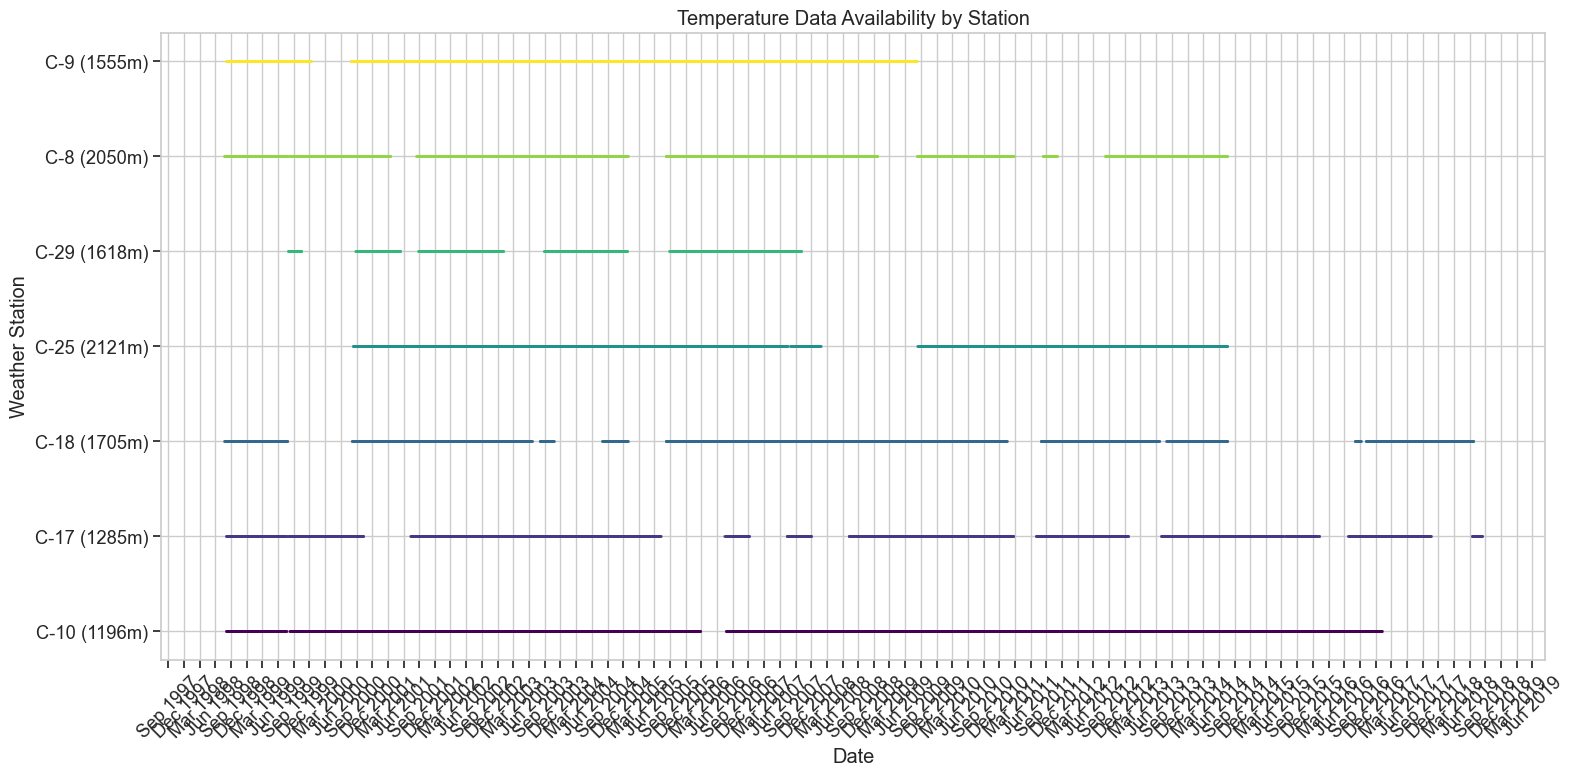

In [4]:
# --------------------------
# 1. Visualize data availability
# --------------------------
# Create a figure to show data availability across all stations
fig, ax = plt.subplots(figsize=(16, 8))

# For each camp, create a scatter plot of available data points
camps = df_daily['Camp'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(camps)))

for i, camp in enumerate(sorted(camps)):
    camp_data = df_daily[df_daily['Camp'] == camp]
    # Check if the temperature column exists and has data
    if not camp_data[temp_col_daily].isna().all():
        valid_data = camp_data.dropna(subset=[temp_col_daily])
        ax.scatter(valid_data['Date'], [i] * len(valid_data), 
                  s=1, alpha=0.5, color=colors[i], label=f"{camp} ({camp_data['Elevation_m'].iloc[0]}m)")

ax.set_yticks(range(len(camps)))
ax.set_yticklabels([f"{camp} ({df_daily[df_daily['Camp'] == camp]['Elevation_m'].iloc[0]}m)" for camp in sorted(camps)])
ax.set_title('Temperature Data Availability by Station')
ax.set_xlabel('Date')
ax.set_ylabel('Weather Station')

# Format x-axis to show months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



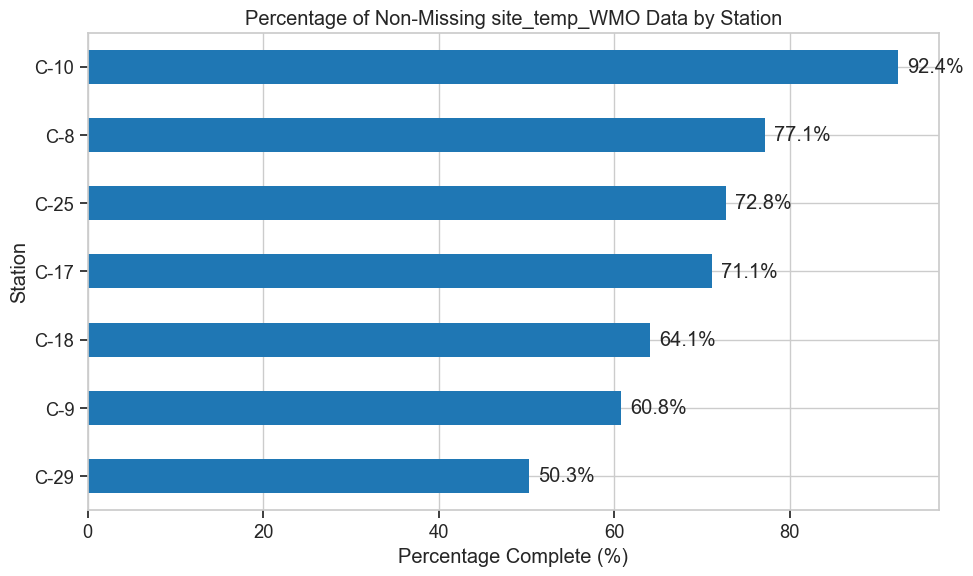

In [5]:
# --------------------------
# 2. Calculate data completeness
# --------------------------
# Calculate percentage of non-missing temperature data by station
completeness = df_daily.groupby('Camp')[temp_col_daily].apply(
    lambda x: 100 * (1 - x.isna().sum() / len(x))
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
completeness.plot(kind='barh', ax=ax)
ax.set_title(f'Percentage of Non-Missing {temp_col_daily} Data by Station')
ax.set_xlabel('Percentage Complete (%)')
ax.set_ylabel('Station')
for i, v in enumerate(completeness):
    ax.text(v + 1, i, f"{v:.1f}%", va='center')
plt.tight_layout()
plt.show()



/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/1945052813.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_avg = df_daily.groupby(['Camp', 'season'])[temp_col_daily].mean().unstack()


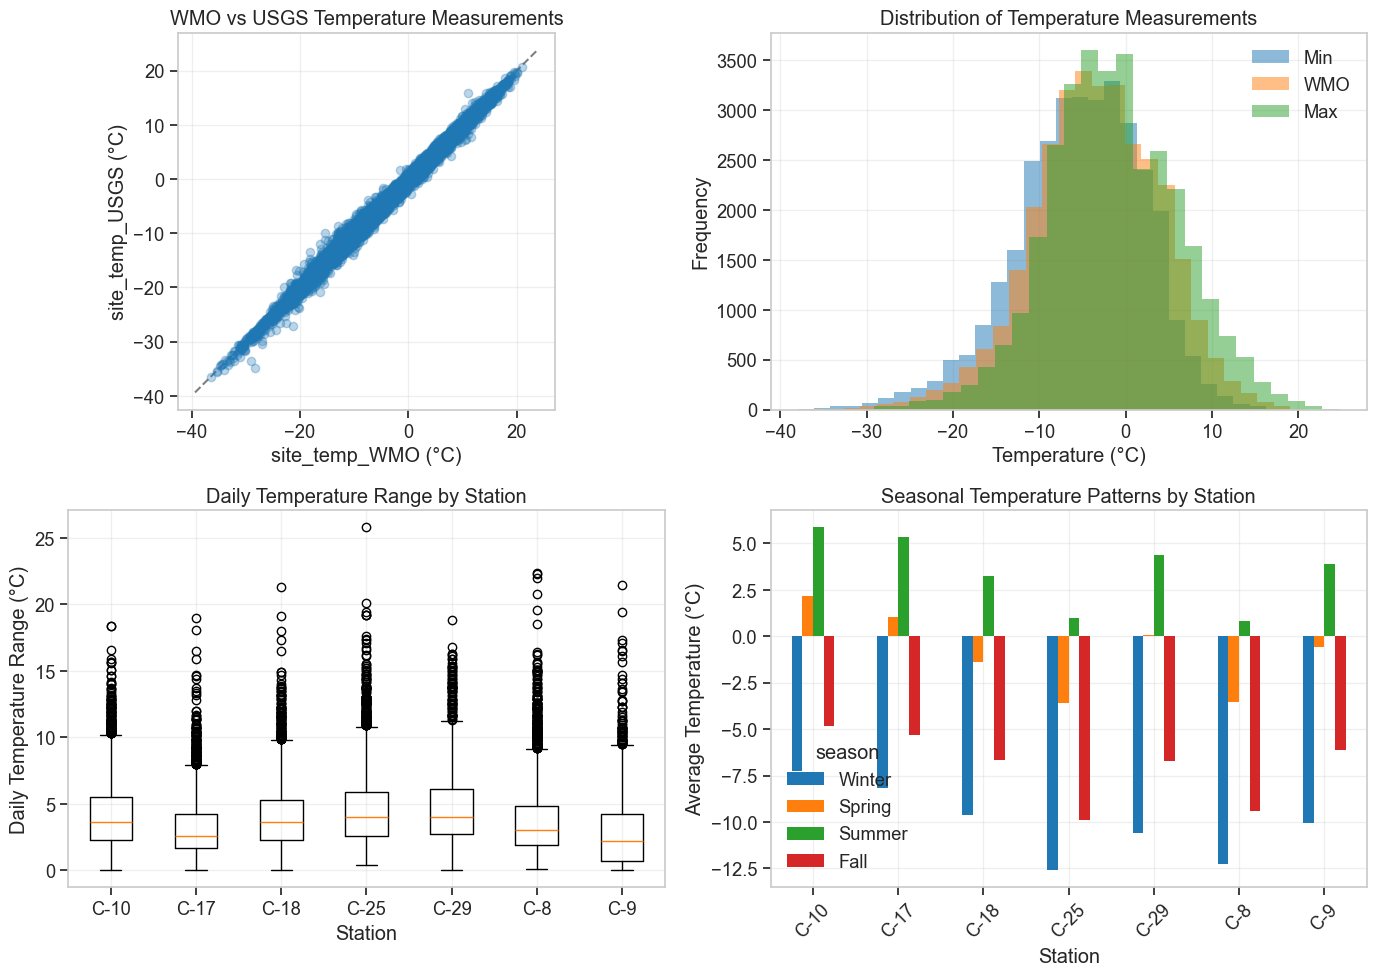

In [6]:
# --------------------------
# 3. Comparing the different temperature measurements
# --------------------------
# Create a plot to compare the different temperature measurements
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# Scatter plot of WMO vs USGS temperatures
ax = axs[0]
valid_mask = (~df_daily['site_temp_WMO'].isna()) & (~df_daily['site_temp_USGS'].isna())
ax.scatter(df_daily.loc[valid_mask, 'site_temp_WMO'], 
          df_daily.loc[valid_mask, 'site_temp_USGS'],
          alpha=0.3)
ax.set_xlabel('site_temp_WMO (°C)')
ax.set_ylabel('site_temp_USGS (°C)')
ax.set_title('WMO vs USGS Temperature Measurements')
# Add a 1:1 line
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Histogram of min, max, and WMO temperatures
ax = axs[1]
valid_mask = (~df_daily['site_temp_min'].isna()) & (~df_daily['site_temp_max'].isna()) & (~df_daily['site_temp_WMO'].isna())
ax.hist(df_daily.loc[valid_mask, 'site_temp_min'], bins=30, alpha=0.5, label='Min')
ax.hist(df_daily.loc[valid_mask, 'site_temp_WMO'], bins=30, alpha=0.5, label='WMO')
ax.hist(df_daily.loc[valid_mask, 'site_temp_max'], bins=30, alpha=0.5, label='Max')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Temperature Measurements')
ax.legend()
ax.grid(True, alpha=0.3)

# Daily temperature range (max - min)
ax = axs[2]
df_daily['temp_range'] = df_daily['site_temp_max'] - df_daily['site_temp_min']
valid_mask = ~df_daily['temp_range'].isna()
stations = df_daily.loc[valid_mask, 'Camp'].unique()
data = []
for station in sorted(stations):
    station_data = df_daily[(df_daily['Camp'] == station) & valid_mask]['temp_range']
    if len(station_data) > 0:
        data.append(station_data)
if data:
    ax.boxplot(data, labels=sorted(stations))
    ax.set_xlabel('Station')
    ax.set_ylabel('Daily Temperature Range (°C)')
    ax.set_title('Daily Temperature Range by Station')
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3)

# Seasonal temperature patterns
ax = axs[3]
seasonal_avg = df_daily.groupby(['Camp', 'season'])[temp_col_daily].mean().unstack()
if not seasonal_avg.empty:
    seasonal_avg.plot(kind='bar', ax=ax)
    ax.set_xlabel('Station')
    ax.set_ylabel('Average Temperature (°C)')
    ax.set_title('Seasonal Temperature Patterns by Station')
    plt.xticks(rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



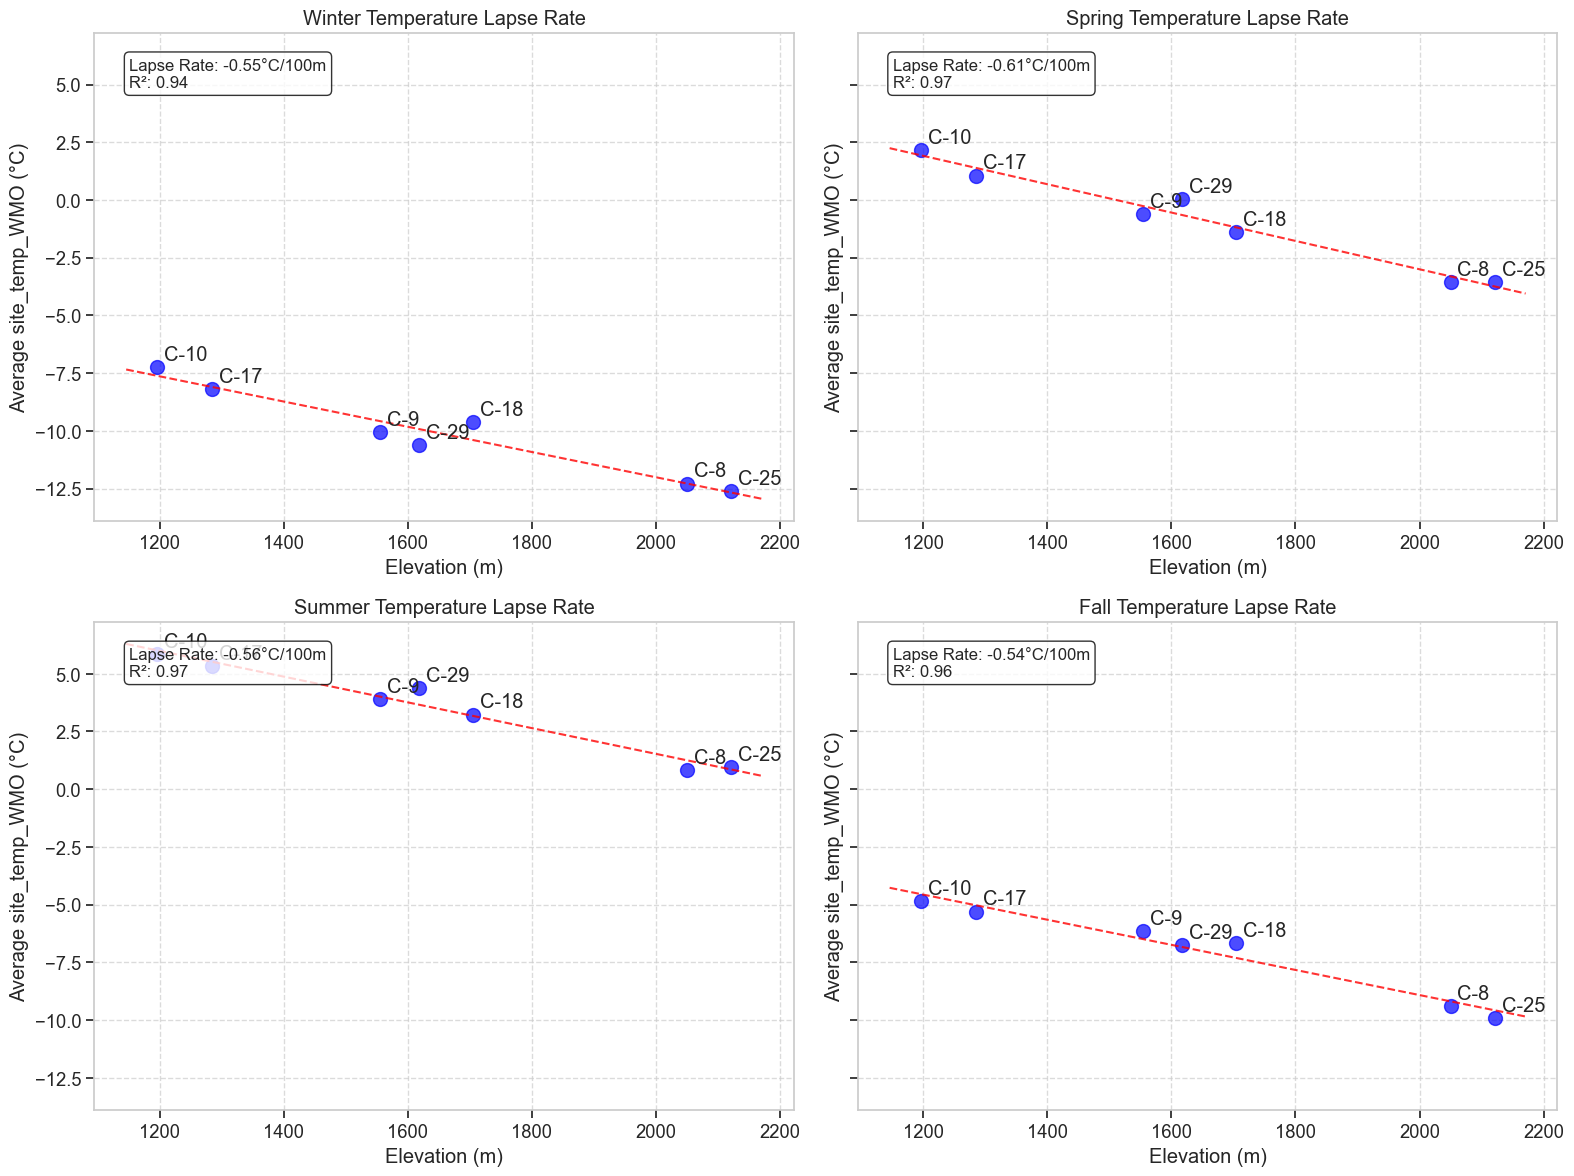

In [7]:
# --------------------------
# 4. Visualize temperature lapse rate for each season
# --------------------------
# Function to calculate lapse rate
def calculate_lapse_rate(temps, elevations):
    """Calculate temperature lapse rate in °C/100m"""
    # Use only non-NaN pairs of temperature and elevation
    valid_mask = ~np.isnan(temps) & ~np.isnan(elevations)
    if sum(valid_mask) < 2:  # Need at least 2 points for regression
        return np.nan, np.nan, np.nan
    
    # Linear regression: temp ~ elevation
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        elevations[valid_mask], temps[valid_mask])
    
    # Convert slope to °C/100m
    lapse_rate = slope * 100
    
    return lapse_rate, r_value**2, p_value

# Create a figure for seasonal lapse rates
fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axs = axs.flatten()

for i, season in enumerate(['Winter', 'Spring', 'Summer', 'Fall']):
    season_data = df_daily[df_daily['season'] == season]
    
    # Group by elevation and calculate mean temperature
    elev_temp = season_data.groupby(['Camp', 'Elevation_m'])[temp_col_daily].mean().reset_index()
    
    # Plot scatter of elevation vs temperature
    if not elev_temp.empty:
        axs[i].scatter(elev_temp['Elevation_m'], elev_temp[temp_col_daily], 
                       s=100, alpha=0.7, c='blue')
        
        # Add station labels
        for j, row in elev_temp.iterrows():
            axs[i].annotate(row['Camp'], (row['Elevation_m'], row[temp_col_daily]),
                           xytext=(5, 5), textcoords='offset points')
        
        # If we have at least 2 data points, fit a line
        if len(elev_temp) >= 2:
            # Calculate lapse rate
            lapse_rate, r2, p_value = calculate_lapse_rate(
                elev_temp[temp_col_daily].values, elev_temp['Elevation_m'].values)
            
            # Plot regression line
            x_range = np.linspace(elev_temp['Elevation_m'].min() - 50, 
                                 elev_temp['Elevation_m'].max() + 50, 100)
            y_pred = lapse_rate/100 * x_range + (elev_temp[temp_col_daily].mean() - 
                                               lapse_rate/100 * elev_temp['Elevation_m'].mean())
            axs[i].plot(x_range, y_pred, 'r--', alpha=0.8)
            
            lr_text = f"Lapse Rate: {lapse_rate:.2f}°C/100m\nR²: {r2:.2f}"
            axs[i].text(0.05, 0.95, lr_text, transform=axs[i].transAxes, 
                       fontsize=12, verticalalignment='top', 
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        axs[i].set_title(f'{season} Temperature Lapse Rate')
        axs[i].set_xlabel('Elevation (m)')
        axs[i].set_ylabel(f'Average {temp_col_daily} (°C)')
        axs[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



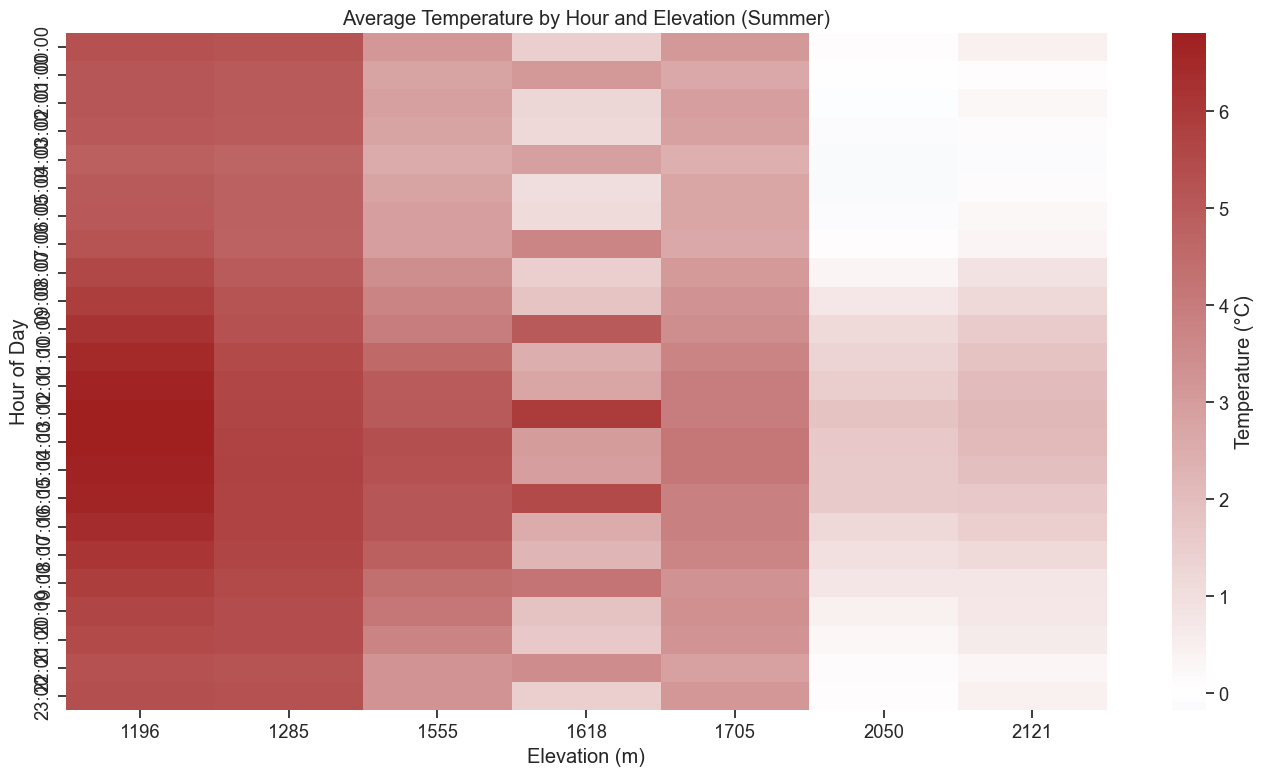

In [10]:

# --------------------------
# 6. Create a heatmap of temperature by elevation and time of day (using hourly data)
# --------------------------
# Use hourly data to examine diurnal patterns
if 'datetime' in df_hourly.columns:
    # Create pivot table: hours vs elevation with temperature values
    df_hourly_filtered = df_hourly.dropna(subset=[temp_col_hourly])
    
    # Get summer data for better pattern visibility
    summer_data = df_hourly_filtered[df_hourly_filtered['season'] == 'Summer']
    
    # Check if we have sufficient data
    if not summer_data.empty and len(summer_data['Camp'].unique()) > 1:
        pivot = pd.pivot_table(
            summer_data,
            index='hour', 
            columns=['Camp', 'Elevation_m'], 
            values=temp_col_hourly,
            aggfunc='mean'
        )
        
        # Create a simplified pivot for easier visualization
        # Average across camps with the same elevation
        simplified_pivot = pd.pivot_table(
            summer_data,
            index='hour', 
            columns='Elevation_m', 
            values=temp_col_hourly,
            aggfunc='mean'
        )
        
        # Sort columns by elevation
        if not simplified_pivot.empty:
            simplified_pivot = simplified_pivot.sort_index(axis=1)
            
            # Create heatmap
            fig, ax = plt.subplots(figsize=(14, 8))
            
            # Custom colormap from blue (cold) to red (warm)
            cmap = LinearSegmentedColormap.from_list('temp_cmap', ['#2040A0', '#FFFFFF', '#A02020'])
            
            sns.heatmap(simplified_pivot, cmap=cmap, center=0, 
                       cbar_kws={'label': 'Temperature (°C)'}, ax=ax)
            
            ax.set_title('Average Temperature by Hour and Elevation (Summer)')
            ax.set_xlabel('Elevation (m)')
            ax.set_ylabel('Hour of Day')
            
            # Customize y-ticks to show hours in 24-hour format
            hours = list(range(24))
            ax.set_yticks(np.arange(0.5, 24.5))
            ax.set_yticklabels([f"{h:02d}:00" for h in hours])
            
            plt.tight_layout()
            plt.show()



ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (229,) and arg 1 with shape (248,).

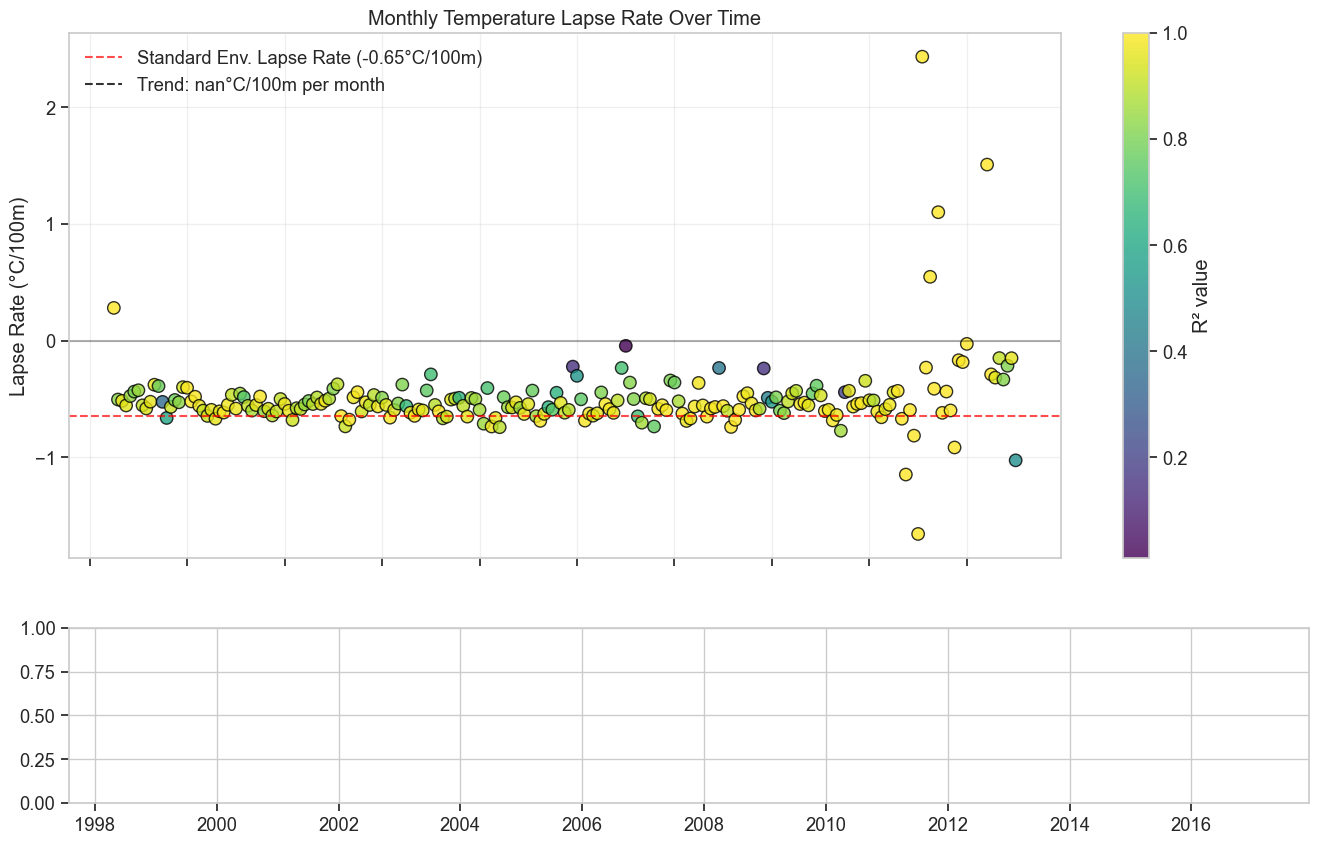

In [11]:
# --------------------------
# 7. Lapse rate time series - monthly averages
# --------------------------
# Calculate monthly lapse rates
df_daily['year_month'] = df_daily['Date'].dt.to_period('M')

# Initialize lists to store results
months = []
lapse_rates = []
r2_values = []

# Iterate through each month
for ym, group in df_daily.groupby('year_month'):
    # Get monthly average temperature for each elevation
    monthly_avg = group.groupby(['Camp', 'Elevation_m'])[temp_col_daily].mean()
    
    if len(monthly_avg) >= 3:  # Need at least 3 elevations for meaningful lapse rate
        # Calculate lapse rate
        lr, r2, _ = calculate_lapse_rate(
            monthly_avg.values, 
            monthly_avg.index.get_level_values('Elevation_m').values
        )
        
        months.append(ym.to_timestamp())
        lapse_rates.append(lr)
        r2_values.append(r2)

# Plot the lapse rate time series
if months:  # Only create the plot if we have data
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # Top plot: Lapse rate time series
    sc = ax1.scatter(months, lapse_rates, c=r2_values, cmap='viridis', 
                   s=80, alpha=0.8, edgecolor='k')
    
    # Add colorbar for R² values
    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label('R² value')
    
    # Add a horizontal line at 0 and -0.65 (typical environmental lapse rate)
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax1.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7, 
               label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    # Add trend line
    if len(months) > 1:
        x_nums = mdates.date2num(months)
        z = np.polyfit(x_nums, lapse_rates, 1)
        p = np.poly1d(z)
        ax1.plot(months, p(x_nums), "k--", alpha=0.8, 
                label=f"Trend: {z[0]:.4f}°C/100m per month")
    
    ax1.set_ylabel('Lapse Rate (°C/100m)')
    ax1.set_title('Monthly Temperature Lapse Rate Over Time')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Bottom plot: Number of stations used for each calculation
    station_counts = []
    for ym, group in df_daily.groupby('year_month'):
        # Count stations with non-NaN temperatures
        valid_stations = group.groupby('Camp')[temp_col_daily].apply(
            lambda x: not x.isna().all()).sum()
        station_counts.append(valid_stations)
    
    ax2.bar(months, station_counts, color='skyblue', alpha=0.7)
    ax2.set_ylabel('Stations with Data')
    ax2.set_ylim(0, df_daily['Camp'].nunique() + 0.5)
    ax2.grid(True, axis='y', alpha=0.3)
    
    # Format x-axis
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()



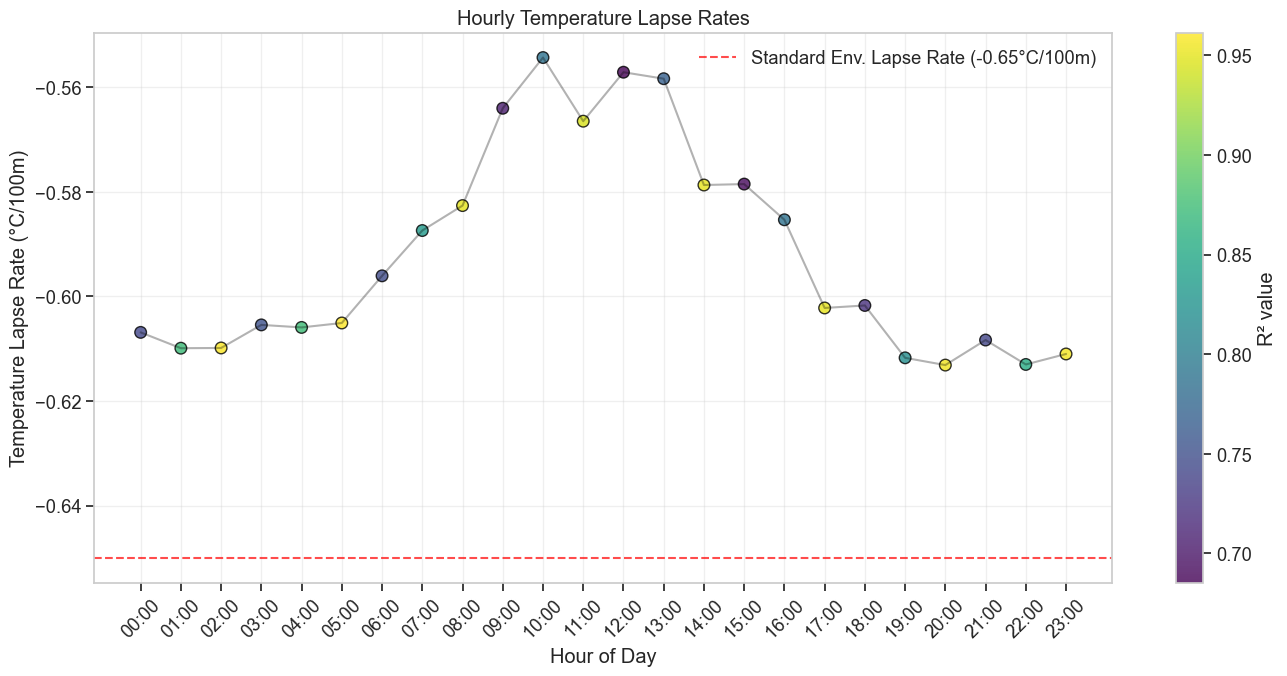

In [12]:
# --------------------------
# 8. Hourly lapse rates - diurnal pattern
# --------------------------
# Calculate lapse rates by time of day (hourly)
if 'datetime' in df_hourly.columns:
    # Check if we have enough data
    if df_hourly_filtered['Camp'].nunique() >= 2:
        # Initialize arrays to store results
        hourly_lapse_rates = np.zeros(24)
        hourly_r2 = np.zeros(24)
        hourly_p_values = np.zeros(24)
        hourly_counts = np.zeros(24)
        
        # For each hour, calculate the lapse rate
        for hour in range(24):
            hour_data = df_hourly_filtered[df_hourly_filtered['hour'] == hour]
            
            # Group by elevation and calculate average temperature
            elev_temp = hour_data.groupby(['Camp', 'Elevation_m'])[temp_col_hourly].mean()
            
            if len(elev_temp) >= 3:  # Need at least 3 elevations
                # Calculate lapse rate
                lr, r2, p = calculate_lapse_rate(
                    elev_temp.values, 
                    elev_temp.index.get_level_values('Elevation_m').values
                )
                
                hourly_lapse_rates[hour] = lr
                hourly_r2[hour] = r2
                hourly_p_values[hour] = p
                hourly_counts[hour] = len(elev_temp)
        
        # Create a figure
        fig, ax = plt.subplots(figsize=(14, 7))
        
        # Plot lapse rate by hour, color by R²
        sc = ax.scatter(range(24), hourly_lapse_rates, 
                      c=hourly_r2, cmap='viridis', 
                      s=hourly_counts*10, alpha=0.8, edgecolor='k')
        
        # Connect points with lines
        ax.plot(range(24), hourly_lapse_rates, 'k-', alpha=0.3)
        
        # Add colorbar for R² values
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label('R² value')
        
        # Add reference line for standard environmental lapse rate
        ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7, 
                   label='Standard Env. Lapse Rate (-0.65°C/100m)')
        
        # Customize x-axis
        ax.set_xticks(range(24))
        ax.set_xticklabels([f"{h:02d}:00" for h in range(24)])
        plt.xticks(rotation=45)
        
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Temperature Lapse Rate (°C/100m)')
        ax.set_title('Hourly Temperature Lapse Rates')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        plt.tight_layout()
        plt.show()



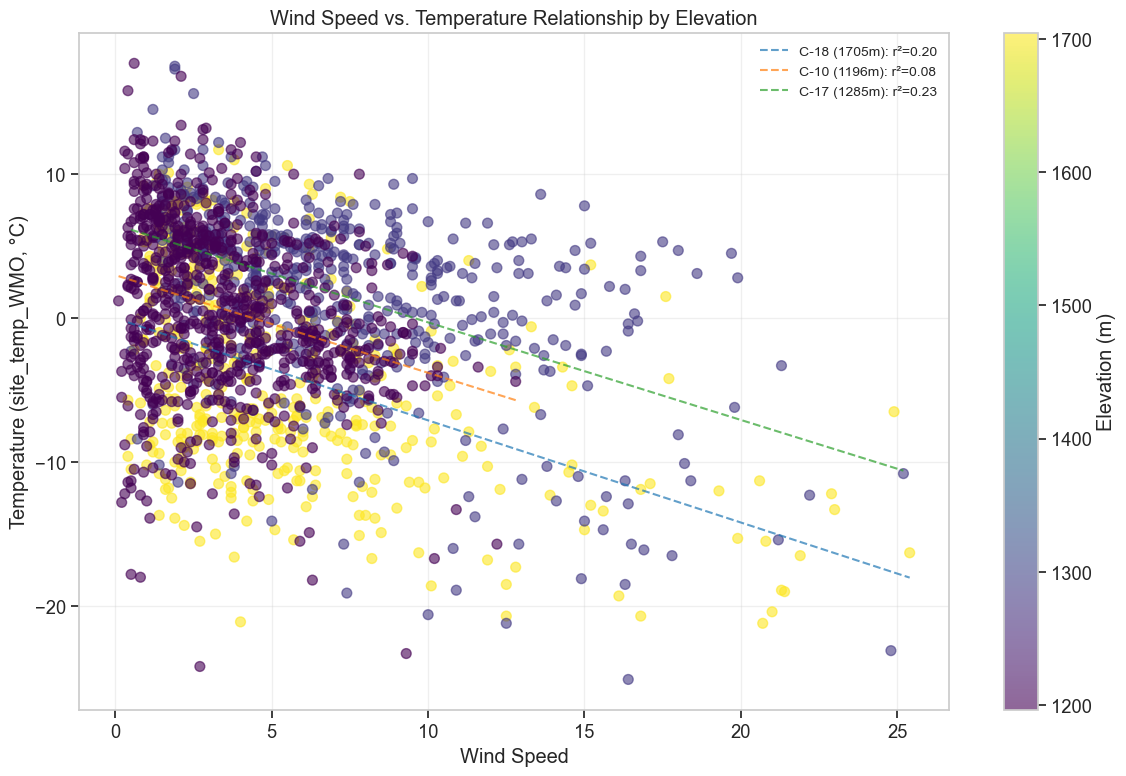

In [13]:
# --------------------------
# 9. Wind speed vs. temperature relationship by elevation
# --------------------------
# Check if wind speed data is available
if 'WindSpeed' in df_daily.columns:
    # Create a scatter plot of wind speed vs. temperature, colored by elevation
    valid_mask = (~df_daily['WindSpeed'].isna()) & (~df_daily[temp_col_daily].isna())
    if sum(valid_mask) > 10:  # Only proceed if we have enough data points
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(
            df_daily.loc[valid_mask, 'WindSpeed'], 
            df_daily.loc[valid_mask, temp_col_daily],
            c=df_daily.loc[valid_mask, 'Elevation_m'],
            cmap='viridis',
            alpha=0.6,
            s=50
        )
        
        # Add a colorbar
        cbar = plt.colorbar(scatter)
        cbar.set_label('Elevation (m)')
        
        # Add regression lines for each elevation group
        for camp in df_daily['Camp'].unique():
            camp_mask = valid_mask & (df_daily['Camp'] == camp)
            if sum(camp_mask) >= 5:  # Need at least 5 points for regression
                camp_data = df_daily.loc[camp_mask]
                
                # Perform linear regression
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    camp_data['WindSpeed'], camp_data[temp_col_daily])
                
                # Generate regression line
                x_range = np.linspace(camp_data['WindSpeed'].min(), camp_data['WindSpeed'].max(), 100)
                y_pred = slope * x_range + intercept
                
                # Plot regression line
                plt.plot(x_range, y_pred, '--', linewidth=1.5, alpha=0.7,
                        label=f"{camp} ({int(camp_data['Elevation_m'].iloc[0])}m): r²={r_value**2:.2f}")
        
        plt.xlabel('Wind Speed')
        plt.ylabel(f'Temperature ({temp_col_daily}, °C)')
        plt.title('Wind Speed vs. Temperature Relationship by Elevation')
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()



/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/122447618.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(elev[valid_mask], temp[valid_mask])
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/122447618.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(elev[valid_mask], temp[valid_mask])
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/122447618.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(elev[valid_mask], temp[valid_mask])
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/122447618.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(elev[valid_mask], temp[valid

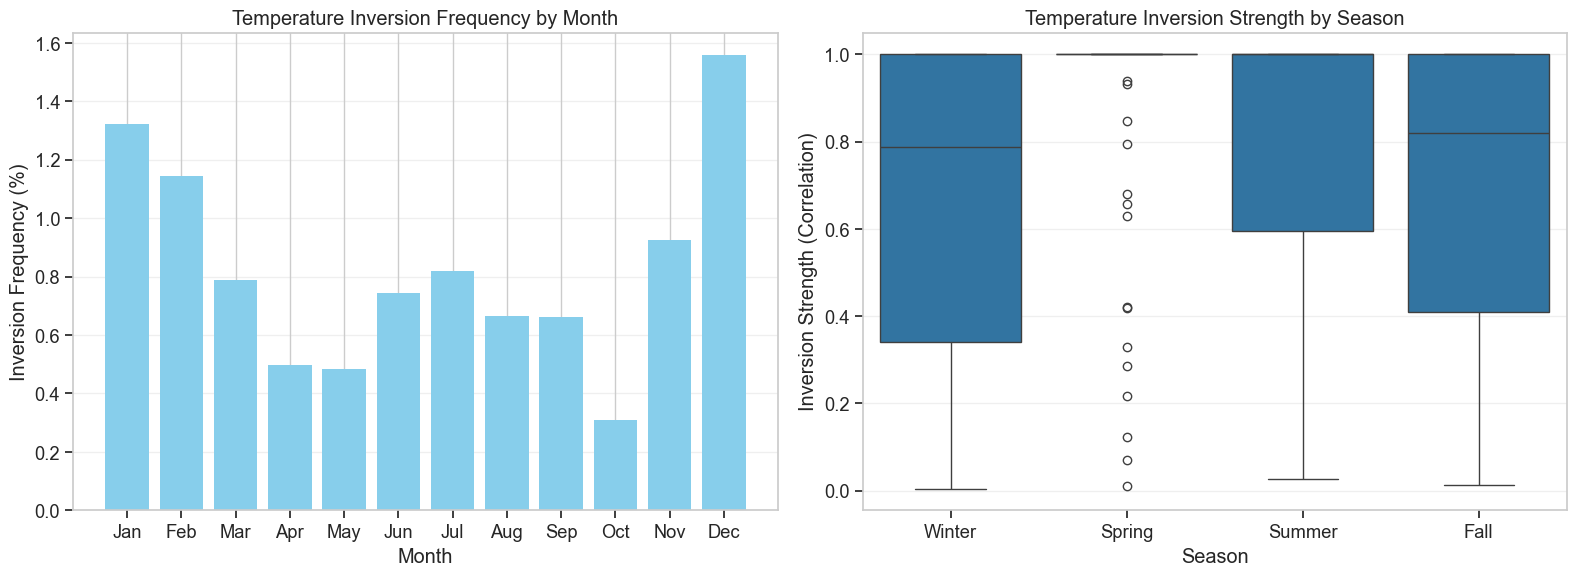

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/122447618.py:82: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_inversions = inversion_date_map.resample('M').mean()


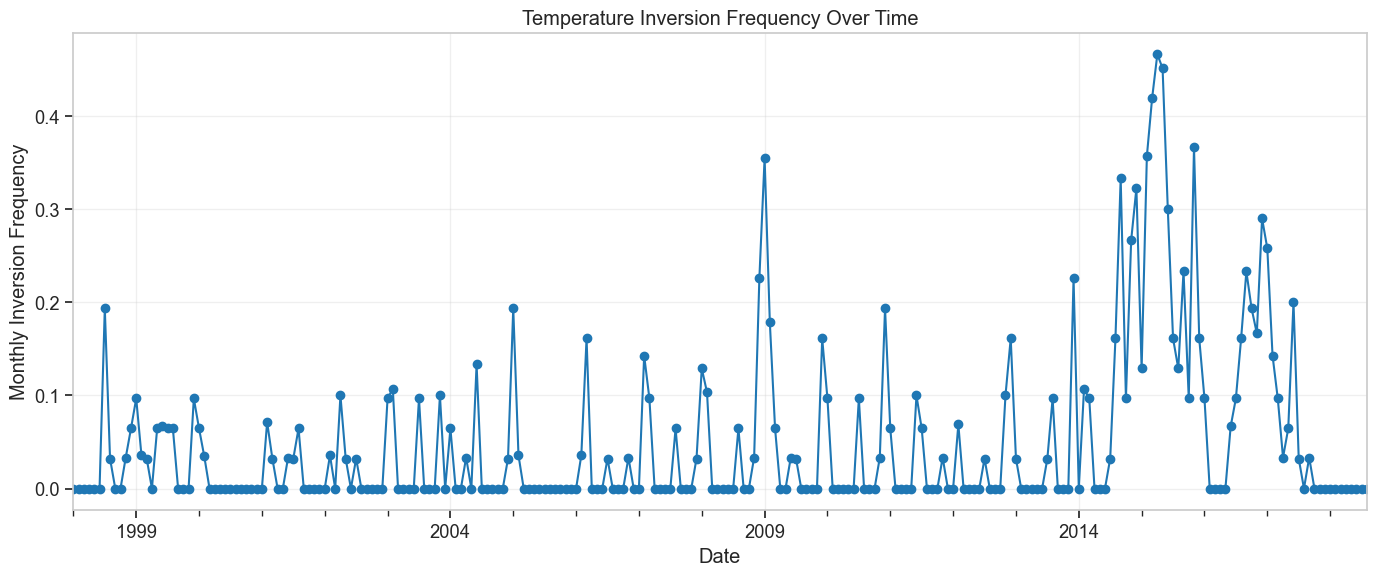

In [14]:
# --------------------------
# 10. Inversion frequency analysis
# --------------------------
# Calculate how often temperature inversions occur
# (Higher elevations having warmer temperatures than lower elevations)

# Group data by date
daily_by_date = df_daily.groupby('Date')

# Initialize list to store inversion data
inversion_dates = []
inversion_strength = []

# For each day, check if there's a temperature inversion
for date, group in daily_by_date:
    # Check if we have at least 2 stations with data
    if len(group.dropna(subset=[temp_col_daily])) >= 2:
        # Calculate correlation between elevation and temperature
        elev = group['Elevation_m'].values
        temp = group[temp_col_daily].values
        
        # Use only valid pairs
        valid_mask = ~np.isnan(elev) & ~np.isnan(temp)
        if sum(valid_mask) >= 2:
            correlation, p_value = stats.pearsonr(elev[valid_mask], temp[valid_mask])
            
            # Positive correlation indicates inversion
            if correlation > 0:
                inversion_dates.append(date)
                inversion_strength.append(correlation)

# Calculate inversion frequency by month
if inversion_dates:
    inversion_df = pd.DataFrame({
        'Date': inversion_dates,
        'Strength': inversion_strength
    })
    inversion_df['Month'] = pd.DatetimeIndex(inversion_df['Date']).month
    inversion_df['Season'] = pd.cut(inversion_df['Month'], 
                                    bins=[0, 3, 6, 9, 12],
                                    labels=['Winter', 'Spring', 'Summer', 'Fall'])
    
    # Count inversions by month
    monthly_counts = df_daily.groupby(df_daily['Date'].dt.month).size()
    inversion_monthly = inversion_df.groupby('Month').size()
    
    # Calculate percentage
    inversion_pct = (inversion_monthly / monthly_counts * 100).fillna(0)
    
    # Plot inversion frequency
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Monthly frequency
    ax1.bar(inversion_pct.index, inversion_pct.values, color='skyblue')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Inversion Frequency (%)')
    ax1.set_title('Temperature Inversion Frequency by Month')
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax1.grid(True, axis='y', alpha=0.3)
    
    # Box plot of inversion strength by season
    if not inversion_df.empty:
        sns.boxplot(x='Season', y='Strength', data=inversion_df, ax=ax2)
        ax2.set_xlabel('Season')
        ax2.set_ylabel('Inversion Strength (Correlation)')
        ax2.set_title('Temperature Inversion Strength by Season')
        ax2.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create a map of inversion dates
    if len(inversion_dates) > 0:
        inversion_date_map = pd.DataFrame(index=pd.date_range(
            min(df_daily['Date']), max(df_daily['Date'])))
        inversion_date_map['inversion'] = 0
        inversion_date_map.loc[inversion_dates, 'inversion'] = 1
        
        # Resample to monthly averages for better visualization
        monthly_inversions = inversion_date_map.resample('M').mean()
        
        # Plot frequency over time
        plt.figure(figsize=(14, 6))
        monthly_inversions['inversion'].plot(marker='o')
        plt.xlabel('Date')
        plt.ylabel('Monthly Inversion Frequency')
        plt.title('Temperature Inversion Frequency Over Time')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates
from scipy import stats
from sklearn.decomposition import PCA
from scipy import signal

# Set the style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the merged data files
daily_data_path = Path("merged_daily_weather_data.csv")
hourly_data_path = Path("merged_hourly_weather_data.csv")

df_daily = pd.read_csv(daily_data_path)
df_hourly = pd.read_csv(hourly_data_path)

# Convert timestamp columns to datetime
df_daily['Date'] = pd.to_datetime(df_daily['Date'], format='%Y/%m/%d')
if 'local_time' in df_hourly.columns:
    df_hourly['datetime'] = pd.to_datetime(df_hourly['local_time'])
elif 'datetime' in df_hourly.columns:
    df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

# Define the transect order from maritime to continental
transect_order = ['C-17', 'C-10', 'C-9', 'C-18', 'C-8', 'C-25', 'C-26', 'C-29']

# Create a numeric index for the position in the transect
transect_position = {camp: i for i, camp in enumerate(transect_order)}

# Add transect position to the dataframes
df_daily['transect_pos'] = df_daily['Camp'].map(transect_position)
df_hourly['transect_pos'] = df_hourly['Camp'].map(transect_position)

# Extract seasons
df_daily['month'] = df_daily['Date'].dt.month
df_daily['year'] = df_daily['Date'].dt.year
df_daily['season'] = pd.cut(df_daily['month'], 
                            bins=[0, 3, 6, 9, 12],
                            labels=['Winter', 'Spring', 'Summer', 'Fall'])

df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['month'] = df_hourly['datetime'].dt.month
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['season'] = pd.cut(df_hourly['month'], 
                             bins=[0, 3, 6, 9, 12],
                             labels=['Winter', 'Spring', 'Summer', 'Fall'])

# Define main temperature column
temp_col_daily = 'site_temp_WMO'
temp_col_hourly = 'site_temp_WMO'



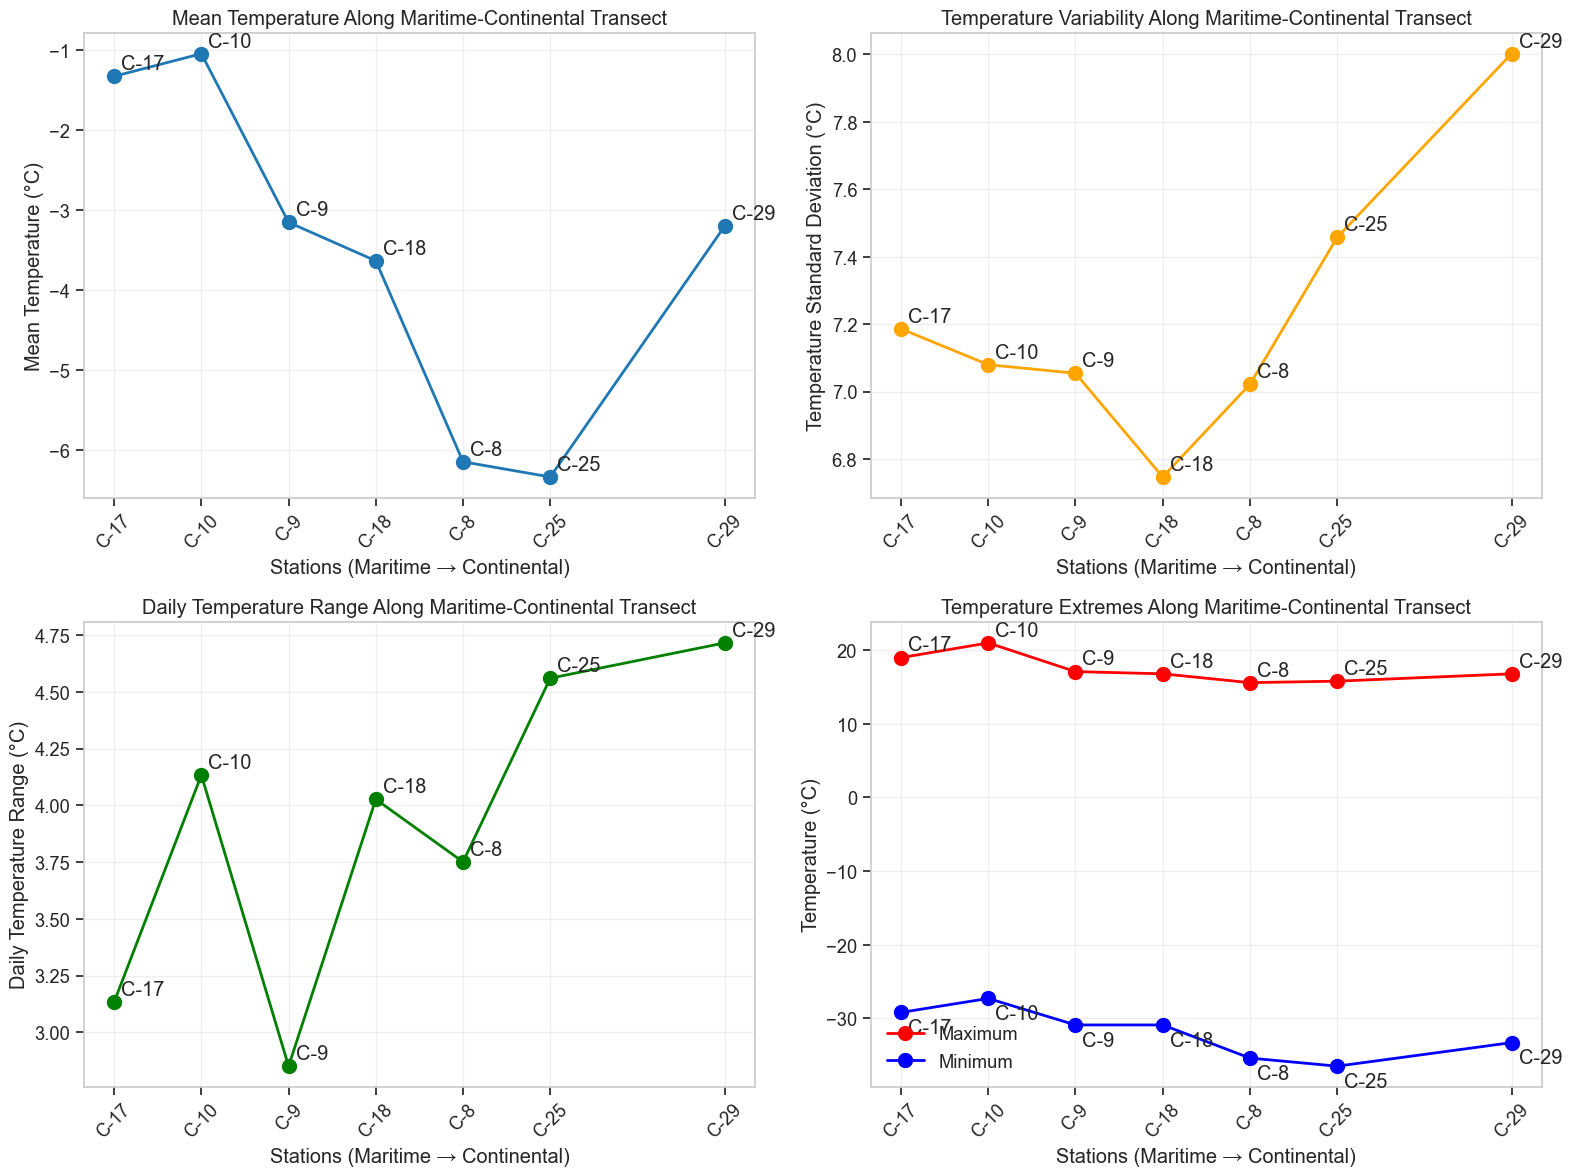

In [16]:
# --------------------------
# 1. Temperature Metrics Along the Maritime-Continental Transect
# --------------------------
# Calculate key temperature metrics by station
metrics = df_daily.groupby('Camp').agg({
    'site_temp_WMO': ['mean', 'std', 'min', 'max'],
    'site_temp_min': ['mean'],
    'site_temp_max': ['mean']
}).reset_index()

# Flatten the column hierarchy
metrics.columns = ['_'.join(col).strip('_') for col in metrics.columns.values]

# Calculate the daily temperature range
metrics['daily_temp_range'] = metrics['site_temp_max_mean'] - metrics['site_temp_min_mean']

# Add transect position
metrics['transect_pos'] = metrics['Camp'].map(transect_position)

# Sort by transect position
metrics = metrics.sort_values('transect_pos')

# For plotting, we'll use only stations that exist in our transect order
metrics = metrics[metrics['Camp'].isin(transect_order)]
metrics_sorted = metrics.sort_values('transect_pos')

# Create a figure
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# Plot 1: Mean Temperature along the transect
ax = axs[0]
ax.plot(metrics_sorted['transect_pos'], metrics_sorted['site_temp_WMO_mean'], 'o-', linewidth=2, markersize=10)
for i, row in metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_mean']),
               xytext=(5, 5), textcoords='offset points')
ax.set_xticks(metrics_sorted['transect_pos'])
ax.set_xticklabels(metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Mean Temperature (°C)')
ax.set_title('Mean Temperature Along Maritime-Continental Transect')
ax.grid(True, alpha=0.3)

# Plot 2: Temperature Variability (Standard Deviation)
ax = axs[1]
ax.plot(metrics_sorted['transect_pos'], metrics_sorted['site_temp_WMO_std'], 'o-', linewidth=2, markersize=10, color='orange')
for i, row in metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_std']),
               xytext=(5, 5), textcoords='offset points')
ax.set_xticks(metrics_sorted['transect_pos'])
ax.set_xticklabels(metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Temperature Standard Deviation (°C)')
ax.set_title('Temperature Variability Along Maritime-Continental Transect')
ax.grid(True, alpha=0.3)

# Plot 3: Daily Temperature Range
ax = axs[2]
ax.plot(metrics_sorted['transect_pos'], metrics_sorted['daily_temp_range'], 'o-', linewidth=2, markersize=10, color='green')
for i, row in metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['daily_temp_range']),
               xytext=(5, 5), textcoords='offset points')
ax.set_xticks(metrics_sorted['transect_pos'])
ax.set_xticklabels(metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Daily Temperature Range (°C)')
ax.set_title('Daily Temperature Range Along Maritime-Continental Transect')
ax.grid(True, alpha=0.3)

# Plot 4: Temperature Extremes
ax = axs[3]
ax.plot(metrics_sorted['transect_pos'], metrics_sorted['site_temp_WMO_max'], 'o-', linewidth=2, markersize=10, color='red', label='Maximum')
ax.plot(metrics_sorted['transect_pos'], metrics_sorted['site_temp_WMO_min'], 'o-', linewidth=2, markersize=10, color='blue', label='Minimum')
for i, row in metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_max']),
               xytext=(5, 5), textcoords='offset points')
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_min']),
               xytext=(5, -15), textcoords='offset points')
ax.set_xticks(metrics_sorted['transect_pos'])
ax.set_xticklabels(metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Extremes Along Maritime-Continental Transect')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/1412949863.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_metrics = df_daily.groupby(['Camp', 'season'])[temp_col_daily].agg(['mean', 'std']).reset_index()


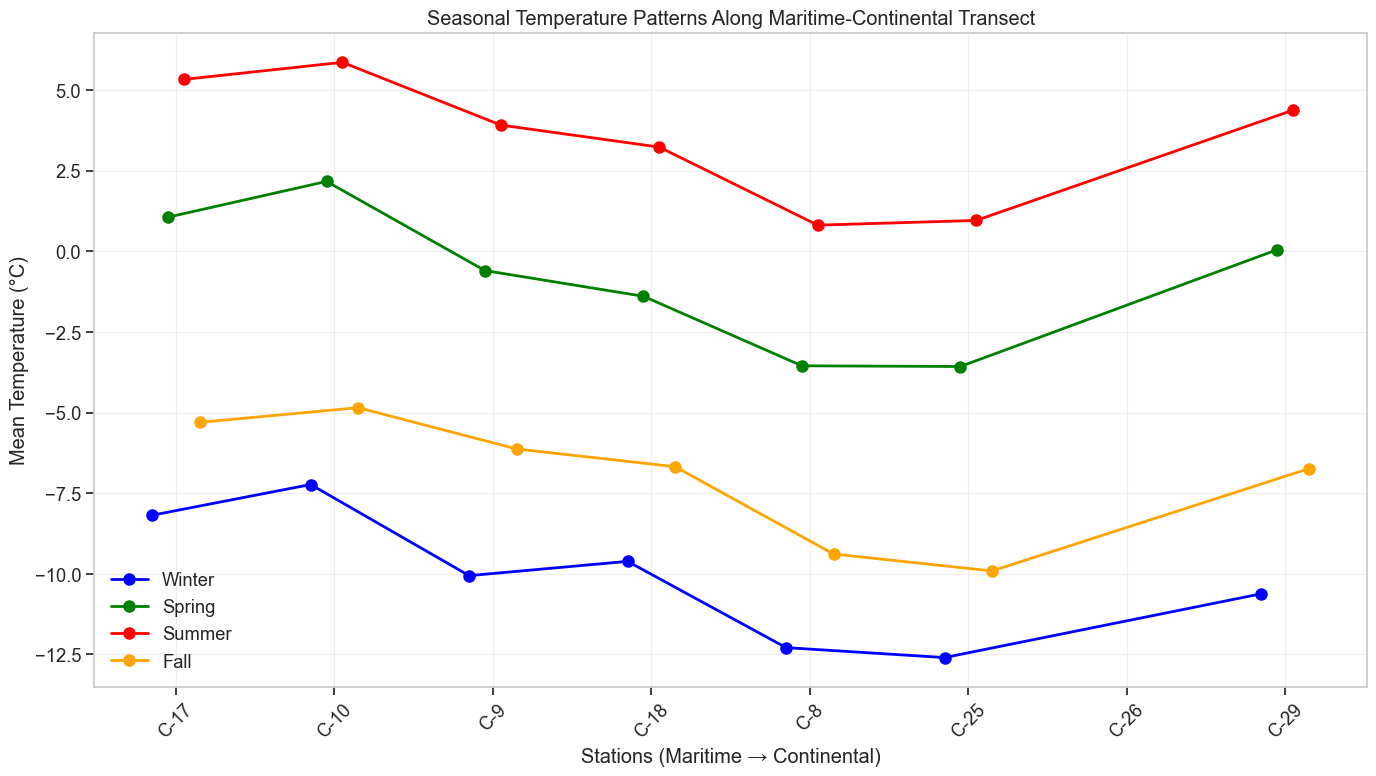

In [17]:
# --------------------------
# 2. Seasonal Analysis Along the Transect
# --------------------------
# Calculate seasonal averages by station
seasonal_metrics = df_daily.groupby(['Camp', 'season'])[temp_col_daily].agg(['mean', 'std']).reset_index()

# Add transect position
seasonal_metrics['transect_pos'] = seasonal_metrics['Camp'].map(transect_position)

# Filter for stations in our transect
seasonal_metrics = seasonal_metrics[seasonal_metrics['Camp'].isin(transect_order)]

# Create a figure
plt.figure(figsize=(14, 8))

# Create points for each season, offset for clarity
season_offsets = {'Winter': -0.15, 'Spring': -0.05, 'Summer': 0.05, 'Fall': 0.15}
colors = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Fall': 'orange'}

# Plot each season
for season, offset in season_offsets.items():
    season_data = seasonal_metrics[seasonal_metrics['season'] == season]
    season_data_sorted = season_data.sort_values('transect_pos')
    
    plt.plot(season_data_sorted['transect_pos'] + offset, season_data_sorted['mean'], 
            'o-', linewidth=2, markersize=8, label=season, color=colors[season])

plt.xticks(range(len(transect_order)), transect_order, rotation=45)
plt.xlabel('Stations (Maritime → Continental)')
plt.ylabel('Mean Temperature (°C)')
plt.title('Seasonal Temperature Patterns Along Maritime-Continental Transect')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



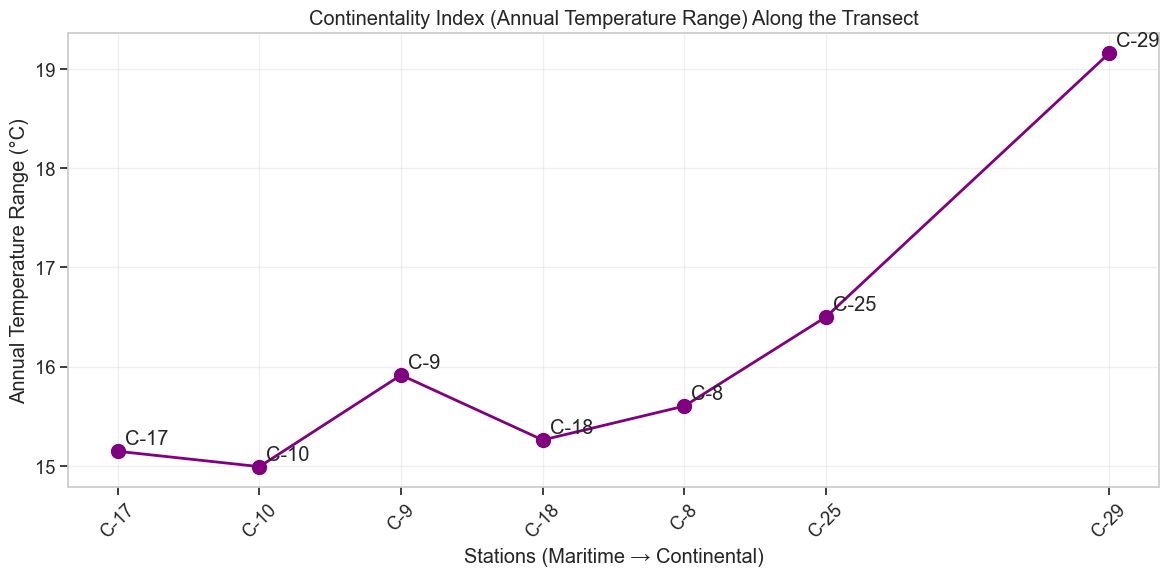

In [18]:
# --------------------------
# 3. Continentality Index
# --------------------------
# Calculate annual temperature range for each station (as a measure of continentality)
# First, get monthly averages
monthly_avgs = df_daily.groupby(['Camp', 'month'])[temp_col_daily].mean().reset_index()

# Calculate annual temperature range for each station
annual_range = monthly_avgs.groupby('Camp').agg(
    annual_range=pd.NamedAgg(column=temp_col_daily, aggfunc=lambda x: x.max() - x.min())
).reset_index()

# Add transect position
annual_range['transect_pos'] = annual_range['Camp'].map(transect_position)

# Filter for stations in our transect and sort
annual_range = annual_range[annual_range['Camp'].isin(transect_order)]
annual_range_sorted = annual_range.sort_values('transect_pos')

# Create a figure
plt.figure(figsize=(12, 6))
plt.plot(annual_range_sorted['transect_pos'], annual_range_sorted['annual_range'], 
        'o-', linewidth=2, markersize=10, color='purple')

for i, row in annual_range_sorted.iterrows():
    plt.annotate(row['Camp'], (row['transect_pos'], row['annual_range']),
               xytext=(5, 5), textcoords='offset points')

plt.xticks(annual_range_sorted['transect_pos'], annual_range_sorted['Camp'], rotation=45)
plt.xlabel('Stations (Maritime → Continental)')
plt.ylabel('Annual Temperature Range (°C)')
plt.title('Continentality Index (Annual Temperature Range) Along the Transect')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



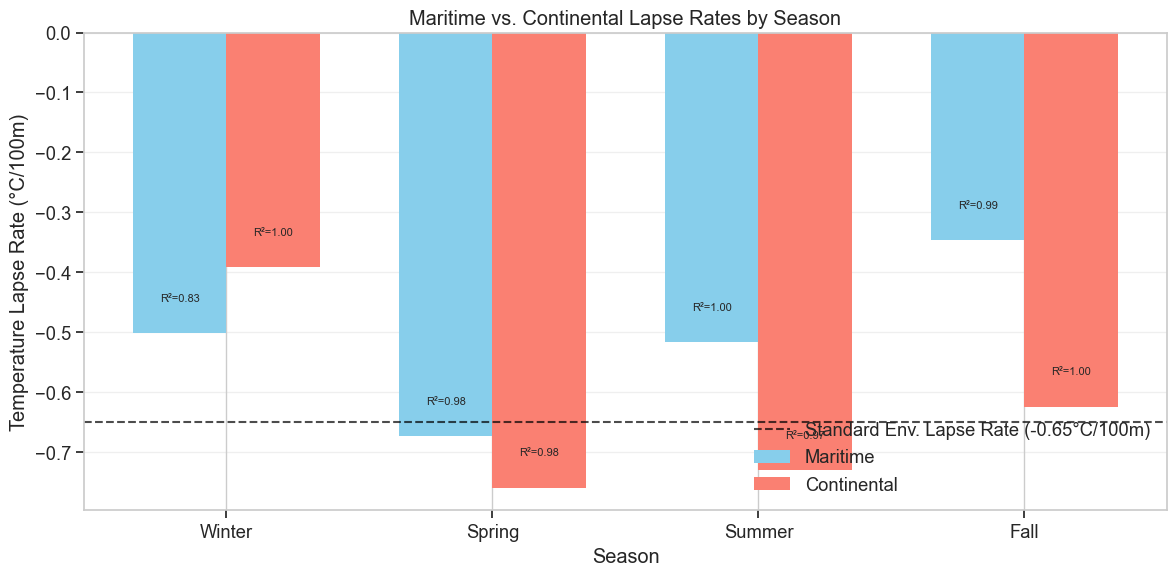

In [19]:
# --------------------------
# 4. Maritime vs. Continental Lapse Rates
# --------------------------
# Split the transect into maritime and continental segments
maritime_stations = ['C-17', 'C-10', 'C-9', 'C-18']
continental_stations = ['C-8', 'C-25', 'C-26', 'C-29']

# Function to calculate lapse rate (from earlier code)
def calculate_lapse_rate(temps, elevations):
    """Calculate temperature lapse rate in °C/100m"""
    # Use only non-NaN pairs of temperature and elevation
    valid_mask = ~np.isnan(temps) & ~np.isnan(elevations)
    if sum(valid_mask) < 2:  # Need at least 2 points for regression
        return np.nan, np.nan, np.nan
    
    # Linear regression: temp ~ elevation
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        elevations[valid_mask], temps[valid_mask])
    
    # Convert slope to °C/100m
    lapse_rate = slope * 100
    
    return lapse_rate, r_value**2, p_value

# Calculate seasonal lapse rates for maritime and continental segments
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
maritime_lapse_rates = []
continental_lapse_rates = []

for season in seasons:
    season_data = df_daily[df_daily['season'] == season]
    
    # Maritime lapse rate
    maritime_data = season_data[season_data['Camp'].isin(maritime_stations)]
    if not maritime_data.empty:
        maritime_elev_temp = maritime_data.groupby(['Camp', 'Elevation_m'])[temp_col_daily].mean().reset_index()
        if len(maritime_elev_temp) >= 2:
            lr, r2, _ = calculate_lapse_rate(
                maritime_elev_temp[temp_col_daily].values, 
                maritime_elev_temp['Elevation_m'].values
            )
            maritime_lapse_rates.append((season, lr, r2))
    
    # Continental lapse rate
    continental_data = season_data[season_data['Camp'].isin(continental_stations)]
    if not continental_data.empty:
        continental_elev_temp = continental_data.groupby(['Camp', 'Elevation_m'])[temp_col_daily].mean().reset_index()
        if len(continental_elev_temp) >= 2:
            lr, r2, _ = calculate_lapse_rate(
                continental_elev_temp[temp_col_daily].values, 
                continental_elev_temp['Elevation_m'].values
            )
            continental_lapse_rates.append((season, lr, r2))

# Prepare data for plotting
maritime_df = pd.DataFrame(maritime_lapse_rates, columns=['Season', 'LapseRate', 'R2'])
continental_df = pd.DataFrame(continental_lapse_rates, columns=['Season', 'LapseRate', 'R2'])

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Set width of bars
bar_width = 0.35

# Set positions of the bars on X axis
r1 = np.arange(len(maritime_df))
r2 = [x + bar_width for x in r1]

# Create bars
if not maritime_df.empty:
    maritime_bars = ax.bar(r1, maritime_df['LapseRate'], width=bar_width, 
                          color='skyblue', label='Maritime')
    # Add R² values on top of bars
    for i, bar in enumerate(maritime_bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
               f"R²={maritime_df['R2'].iloc[i]:.2f}",
               ha='center', va='bottom', rotation=0, size=8)

if not continental_df.empty:
    continental_bars = ax.bar(r2, continental_df['LapseRate'], width=bar_width, 
                             color='salmon', label='Continental')
    # Add R² values on top of bars
    for i, bar in enumerate(continental_bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
               f"R²={continental_df['R2'].iloc[i]:.2f}",
               ha='center', va='bottom', rotation=0, size=8)

# Add a horizontal line at the standard environmental lapse rate
ax.axhline(y=-0.65, color='k', linestyle='--', alpha=0.7, 
           label='Standard Env. Lapse Rate (-0.65°C/100m)')

# Add labels and title
ax.set_xlabel('Season')
ax.set_ylabel('Temperature Lapse Rate (°C/100m)')
ax.set_title('Maritime vs. Continental Lapse Rates by Season')
ax.set_xticks([r + bar_width/2 for r in range(len(maritime_df))])
ax.set_xticklabels(maritime_df['Season'])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



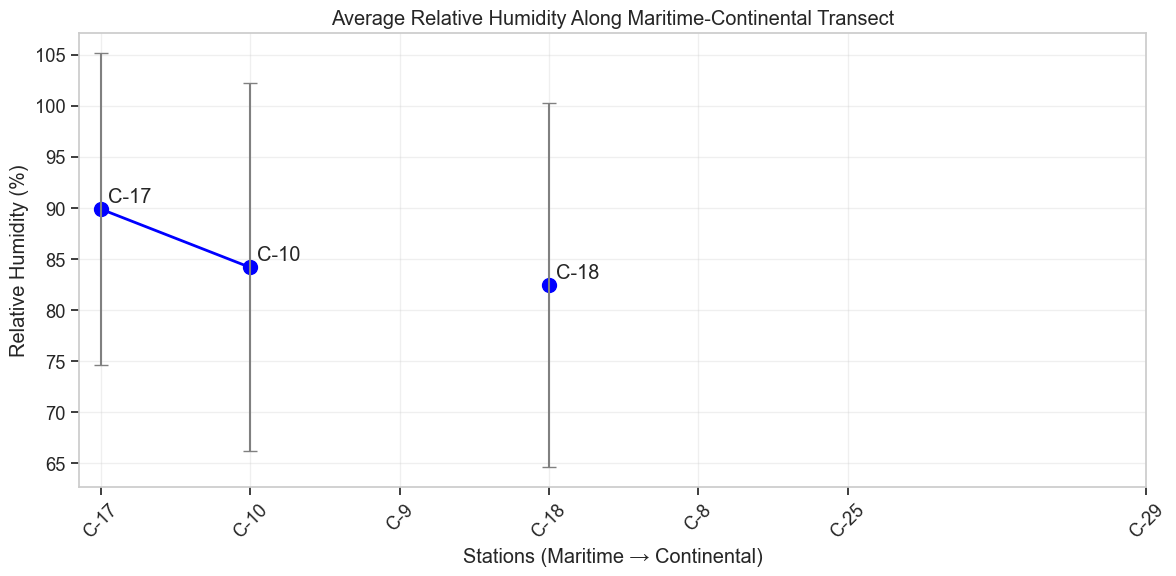

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/3224915633.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_humidity = df_daily.groupby(['Camp', 'season'])['RelHum'].mean().reset_index()


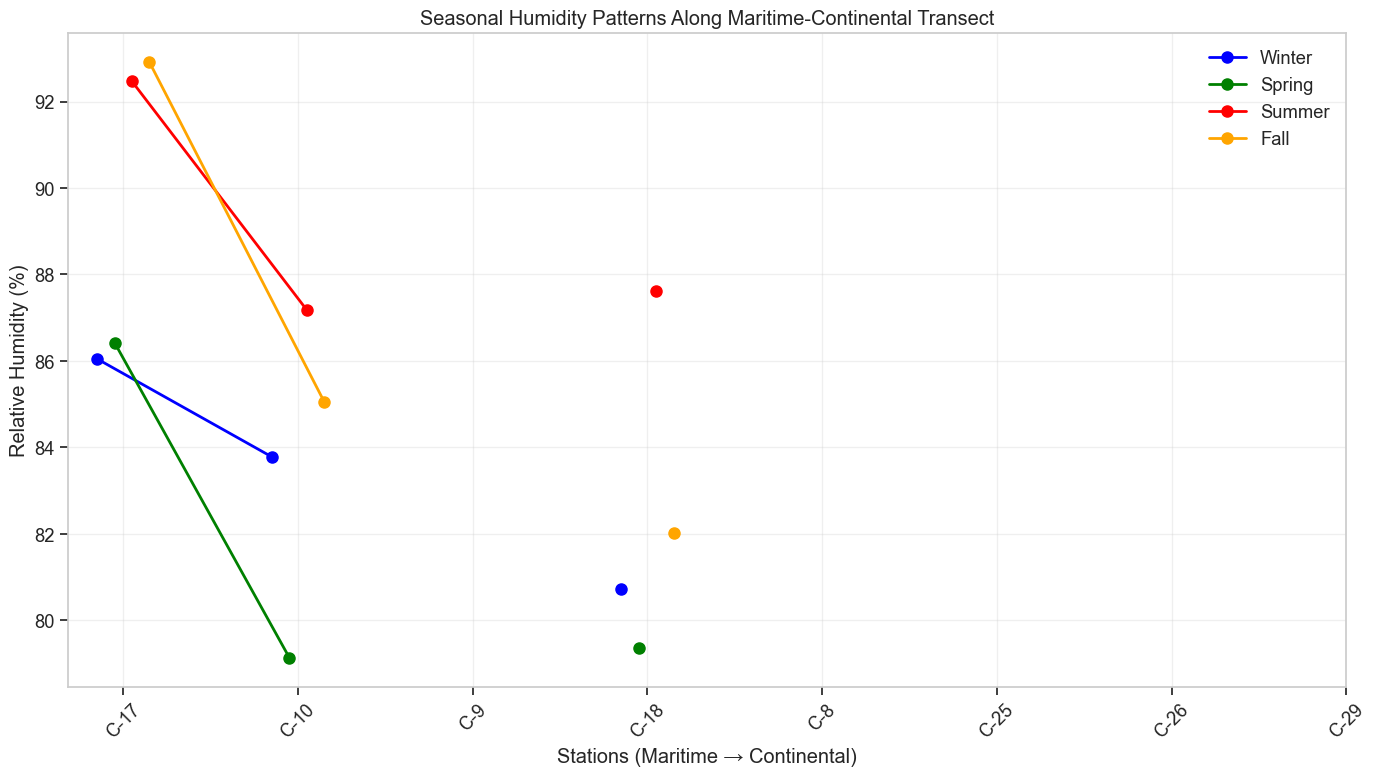

In [20]:
# --------------------------
# 5. Humidity Analysis Along Transect
# --------------------------
# Check if RelHum column exists
if 'RelHum' in df_daily.columns:
    # Calculate average relative humidity by station
    humidity_stats = df_daily.groupby('Camp')['RelHum'].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    # Add transect position and filter
    humidity_stats['transect_pos'] = humidity_stats['Camp'].map(transect_position)
    humidity_stats = humidity_stats[humidity_stats['Camp'].isin(transect_order)]
    humidity_stats_sorted = humidity_stats.sort_values('transect_pos')
    
    # Create figure
    plt.figure(figsize=(12, 6))
    plt.plot(humidity_stats_sorted['transect_pos'], humidity_stats_sorted['mean'], 
            'o-', linewidth=2, markersize=10, color='blue')
    
    # Add error bars
    plt.errorbar(humidity_stats_sorted['transect_pos'], humidity_stats_sorted['mean'], 
                yerr=humidity_stats_sorted['std'], fmt='none', ecolor='gray', capsize=5)
    
    # Add labels
    for i, row in humidity_stats_sorted.iterrows():
        plt.annotate(row['Camp'], (row['transect_pos'], row['mean']),
                   xytext=(5, 5), textcoords='offset points')
    
    plt.xticks(humidity_stats_sorted['transect_pos'], humidity_stats_sorted['Camp'], rotation=45)
    plt.xlabel('Stations (Maritime → Continental)')
    plt.ylabel('Relative Humidity (%)')
    plt.title('Average Relative Humidity Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Seasonal humidity analysis
    if not df_daily.empty:
        seasonal_humidity = df_daily.groupby(['Camp', 'season'])['RelHum'].mean().reset_index()
        seasonal_humidity['transect_pos'] = seasonal_humidity['Camp'].map(transect_position)
        seasonal_humidity = seasonal_humidity[seasonal_humidity['Camp'].isin(transect_order)]
        
        # Plot seasonal humidity patterns
        plt.figure(figsize=(14, 8))
        
        # Plot each season
        for season, offset in season_offsets.items():
            season_data = seasonal_humidity[seasonal_humidity['season'] == season]
            if not season_data.empty:
                season_data_sorted = season_data.sort_values('transect_pos')
                plt.plot(season_data_sorted['transect_pos'] + offset, season_data_sorted['RelHum'], 
                        'o-', linewidth=2, markersize=8, label=season, color=colors[season])
        
        plt.xticks(range(len(transect_order)), transect_order, rotation=45)
        plt.xlabel('Stations (Maritime → Continental)')
        plt.ylabel('Relative Humidity (%)')
        plt.title('Seasonal Humidity Patterns Along Maritime-Continental Transect')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()



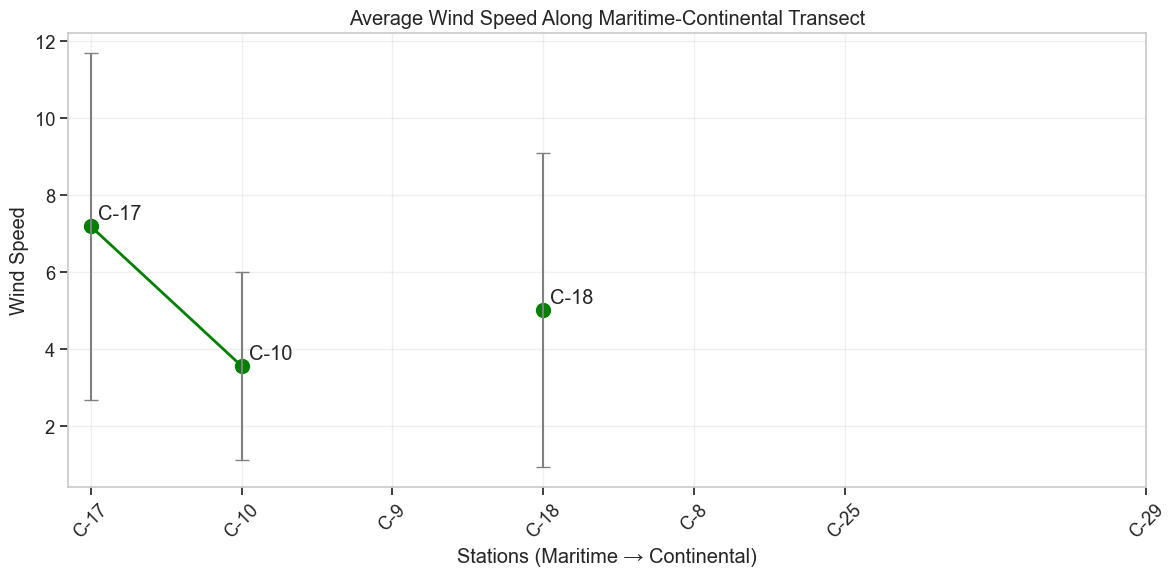

In [22]:
# --------------------------
# 6. Wind Speed Analysis Along Transect
# --------------------------
if 'WindSpeed' in df_daily.columns:
    # Calculate average wind speed by station
    wind_stats = df_daily.groupby('Camp')['WindSpeed'].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    # Add transect position and filter
    wind_stats['transect_pos'] = wind_stats['Camp'].map(transect_position)
    wind_stats = wind_stats[wind_stats['Camp'].isin(transect_order)]
    wind_stats_sorted = wind_stats.sort_values('transect_pos')
    
    # Create figure
    plt.figure(figsize=(12, 6))
    plt.plot(wind_stats_sorted['transect_pos'], wind_stats_sorted['mean'], 
            'o-', linewidth=2, markersize=10, color='green')
    
    # Add error bars
    plt.errorbar(wind_stats_sorted['transect_pos'], wind_stats_sorted['mean'], 
                yerr=wind_stats_sorted['std'], fmt='none', ecolor='gray', capsize=5)
    
    # Add labels
    for i, row in wind_stats_sorted.iterrows():
        plt.annotate(row['Camp'], (row['transect_pos'], row['mean']),
                   xytext=(5, 5), textcoords='offset points')
    
    plt.xticks(wind_stats_sorted['transect_pos'], wind_stats_sorted['Camp'], rotation=45)
    plt.xlabel('Stations (Maritime → Continental)')
    plt.ylabel('Wind Speed')
    plt.title('Average Wind Speed Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



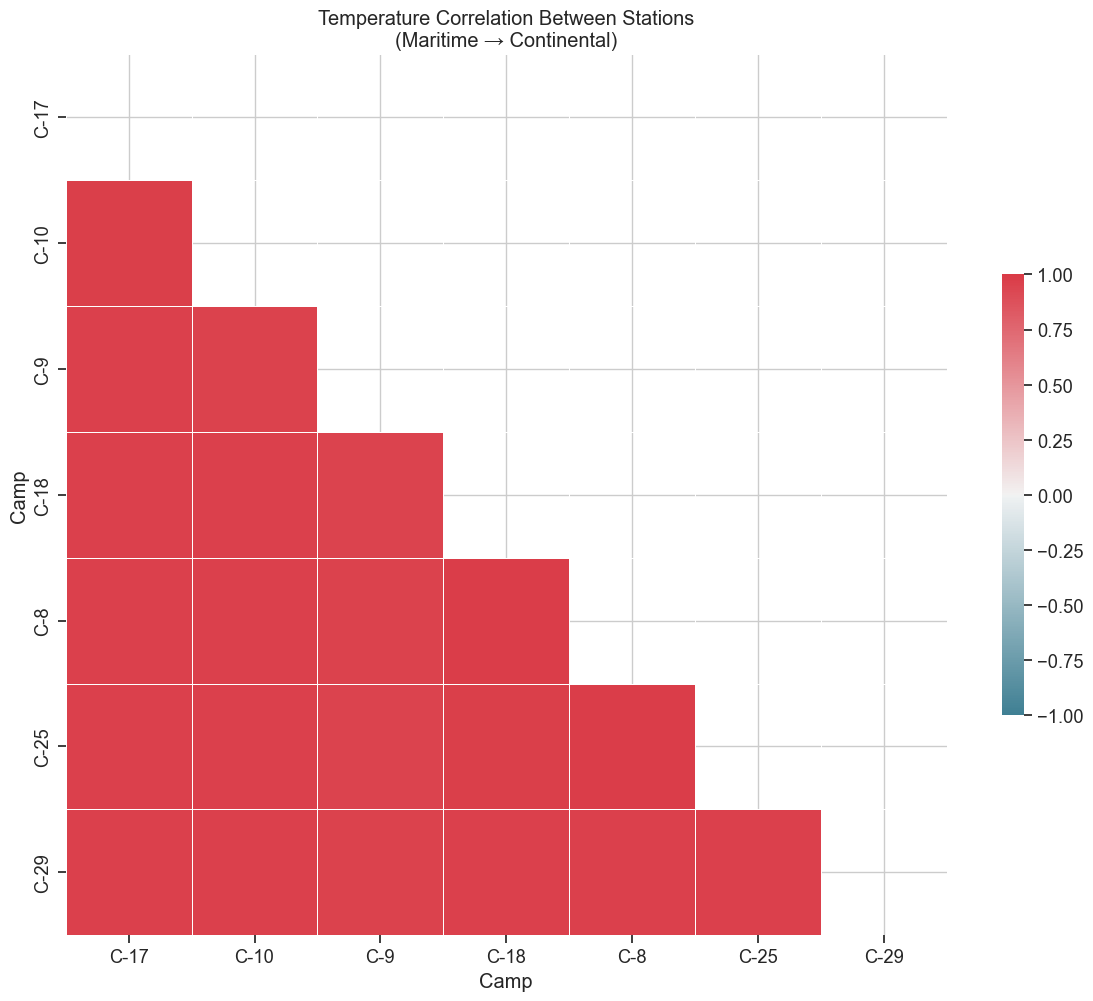

In [23]:
# --------------------------
# 7. Temperature Correlation Analysis
# --------------------------
# Create a cross-correlation matrix between stations
# First, pivot the daily data to have one column per station
pivot_daily = df_daily.pivot_table(
    index='Date',
    columns='Camp',
    values=temp_col_daily
)

# Calculate correlation matrix
corr_matrix = pivot_daily.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Only include stations in our transect
transect_stations = [station for station in transect_order if station in corr_matrix.columns]
corr_matrix_transect = corr_matrix.loc[transect_stations, transect_stations]

# Sort by transect position
sorted_indices = sorted(range(len(transect_stations)), key=lambda k: transect_position[transect_stations[k]])
sorted_stations = [transect_stations[i] for i in sorted_indices]
corr_matrix_sorted = corr_matrix_transect.loc[sorted_stations, sorted_stations]

sns.heatmap(corr_matrix_sorted, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Temperature Correlation Between Stations\n(Maritime → Continental)')
plt.tight_layout()
plt.show()



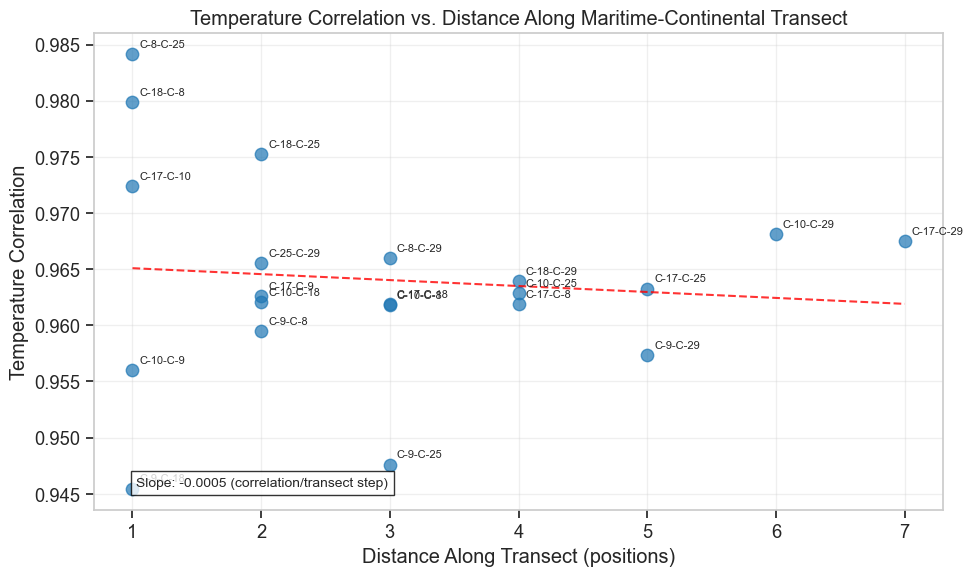

In [24]:
# --------------------------
# 8. Correlation vs. Distance Along Transect
# --------------------------
# Calculate "distance" along transect (using position as proxy)
# Create empty lists to store pairwise correlations and distances
pairwise_corr = []
pairwise_dist = []
pairwise_labels = []

# Calculate correlations and distances
for i, station1 in enumerate(sorted_stations):
    for j, station2 in enumerate(sorted_stations):
        if i < j:  # Only unique pairs
            # Calculate distance along transect
            dist = transect_position[station2] - transect_position[station1]
            
            # Get correlation if both stations have data
            if station1 in pivot_daily.columns and station2 in pivot_daily.columns:
                # Calculate correlation for non-NaN pairs
                valid_data = pivot_daily[[station1, station2]].dropna()
                if len(valid_data) >= 10:  # Need at least 10 points for meaningful correlation
                    corr = valid_data[station1].corr(valid_data[station2])
                    
                    pairwise_corr.append(corr)
                    pairwise_dist.append(dist)
                    pairwise_labels.append(f"{station1}-{station2}")

# Plot correlation vs. distance
if pairwise_corr:
    plt.figure(figsize=(10, 6))
    plt.scatter(pairwise_dist, pairwise_corr, s=80, alpha=0.7)
    
    # Add labels for each point
    for i, label in enumerate(pairwise_labels):
        plt.annotate(label, (pairwise_dist[i], pairwise_corr[i]),
                   xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add trend line
    if len(pairwise_dist) > 1:
        z = np.polyfit(pairwise_dist, pairwise_corr, 1)
        p = np.poly1d(z)
        x_range = np.linspace(min(pairwise_dist), max(pairwise_dist), 100)
        plt.plot(x_range, p(x_range), "r--", alpha=0.8)
        
        # Add text with slope
        slope_text = f"Slope: {z[0]:.4f} (correlation/transect step)"
        plt.text(0.05, 0.05, slope_text, transform=plt.gca().transAxes, 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.xlabel('Distance Along Transect (positions)')
    plt.ylabel('Temperature Correlation')
    plt.title('Temperature Correlation vs. Distance Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



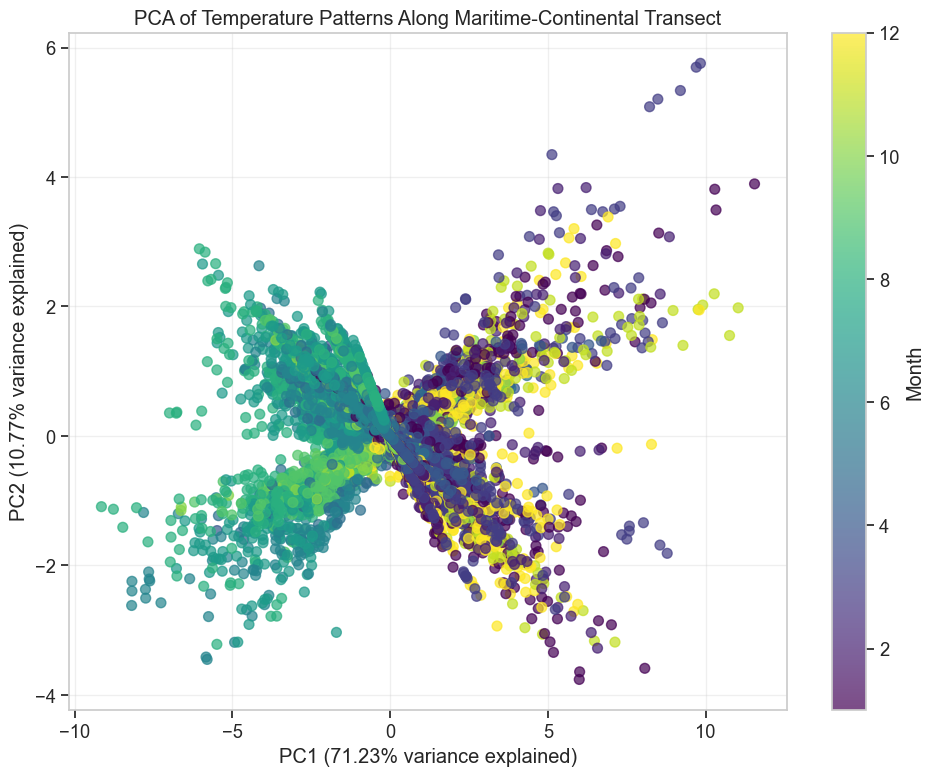

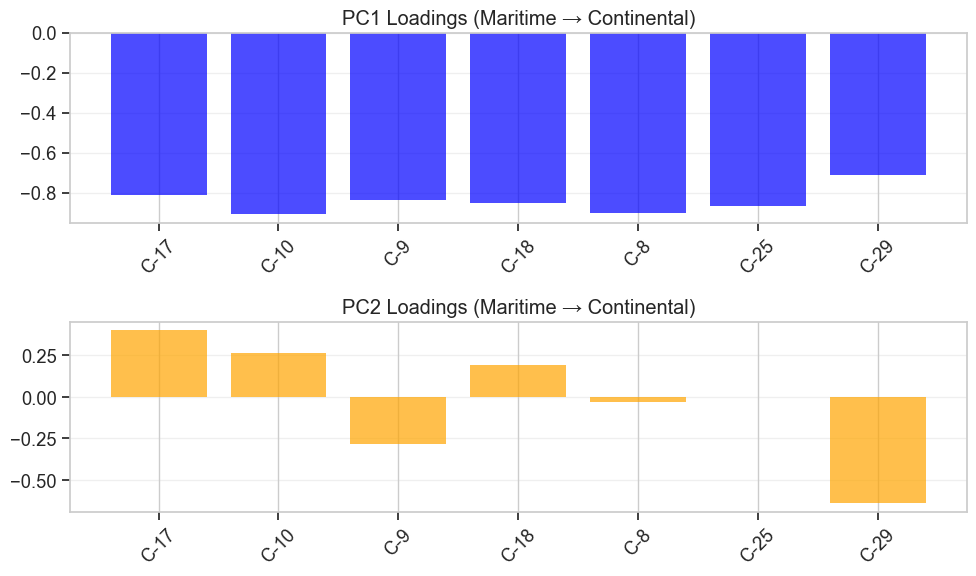

In [25]:
# --------------------------
# 9. Principal Component Analysis of Temperature Patterns
# --------------------------
# Prepare data for PCA - fill NaN values with mean for each column
pivot_filled = pivot_daily.copy()
for col in pivot_filled.columns:
    pivot_filled[col] = pivot_filled[col].fillna(pivot_filled[col].mean())

# Only include stations in our transect
transect_cols = [col for col in pivot_filled.columns if col in transect_order]
pivot_transect = pivot_filled[transect_cols]

# Check if we have enough data for PCA
if len(pivot_transect.columns) >= 2 and len(pivot_transect) >= 5:
    # Standardize the data
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pivot_transect)
    
    # Apply PCA
    pca = PCA()
    pca_result = pca.fit_transform(scaled_data)
    
    # Create a DataFrame with PCA results
    pca_df = pd.DataFrame(
        data=pca_result[:, :2],
        columns=['PC1', 'PC2']
    )
    
    # Add date information
    pca_df['Date'] = pivot_transect.index
    pca_df['month'] = pca_df['Date'].dt.month
    pca_df['season'] = pd.cut(pca_df['month'], 
                              bins=[0, 3, 6, 9, 12],
                              labels=['Winter', 'Spring', 'Summer', 'Fall'])
    
    # Plot PCA results
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['month'], 
                        cmap='viridis', alpha=0.7, s=50)
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Month')
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)')
    plt.title('PCA of Temperature Patterns Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot the loadings
    # Each loading indicates how much each station contributes to a principal component
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    loading_df = pd.DataFrame(
        loadings[:, :2],
        columns=['PC1', 'PC2'],
        index=pivot_transect.columns
    )
    
    # Add transect position
    loading_df['transect_pos'] = loading_df.index.map(transect_position)
    loading_df = loading_df.sort_values('transect_pos')
    
    # Plot loadings
    plt.figure(figsize=(10, 6))
    
    # PC1 loadings
    plt.subplot(2, 1, 1)
    plt.bar(loading_df.index, loading_df['PC1'], color='blue', alpha=0.7)
    plt.title('PC1 Loadings (Maritime → Continental)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.3)
    
    # PC2 loadings
    plt.subplot(2, 1, 2)
    plt.bar(loading_df.index, loading_df['PC2'], color='orange', alpha=0.7)
    plt.title('PC2 Loadings (Maritime → Continental)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()



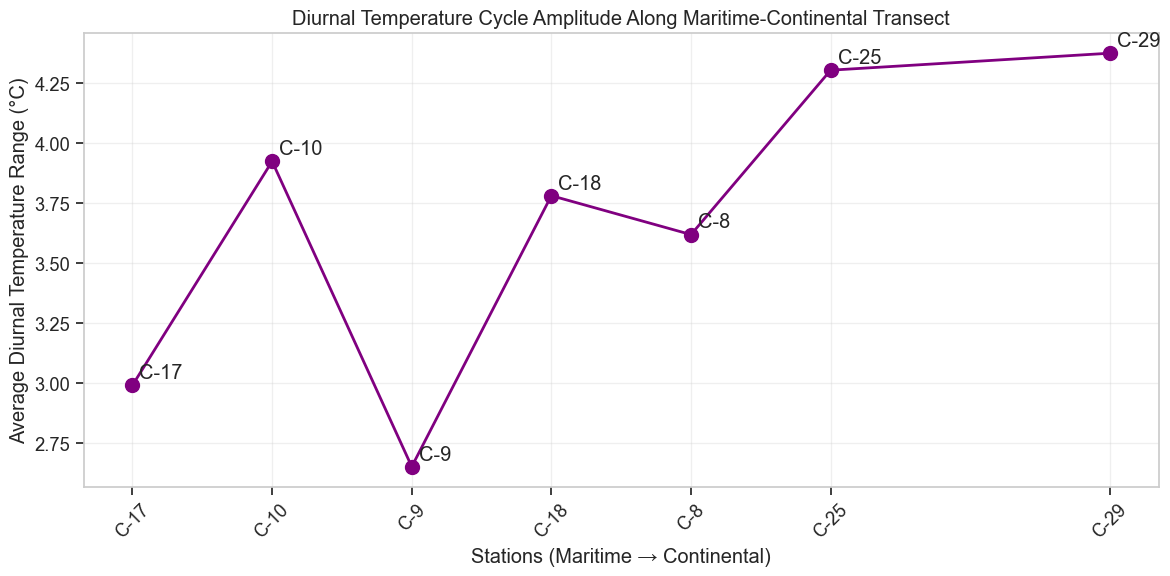

In [26]:
# --------------------------
# 10. Amplitude of Diurnal Cycle Along Transect (using hourly data)
# --------------------------
if 'datetime' in df_hourly.columns:
    # Group hourly data by station and day and calculate daily min/max
    df_hourly['date'] = df_hourly['datetime'].dt.date
    diurnal = df_hourly.groupby(['Camp', 'date'])[temp_col_hourly].agg(['min', 'max']).reset_index()
    
    # Calculate diurnal range
    diurnal['diurnal_range'] = diurnal['max'] - diurnal['min']
    
    # Calculate average diurnal range by station
    diurnal_avg = diurnal.groupby('Camp')['diurnal_range'].mean().reset_index()
    
    # Add transect position and filter
    diurnal_avg['transect_pos'] = diurnal_avg['Camp'].map(transect_position)
    diurnal_avg = diurnal_avg[diurnal_avg['Camp'].isin(transect_order)]
    diurnal_avg_sorted = diurnal_avg.sort_values('transect_pos')
    
    # Create figure
    if not diurnal_avg_sorted.empty:
        plt.figure(figsize=(12, 6))
        plt.plot(diurnal_avg_sorted['transect_pos'], diurnal_avg_sorted['diurnal_range'], 
                'o-', linewidth=2, markersize=10, color='purple')
        
        # Add labels
        for i, row in diurnal_avg_sorted.iterrows():
            plt.annotate(row['Camp'], (row['transect_pos'], row['diurnal_range']),
                       xytext=(5, 5), textcoords='offset points')
        
        plt.xticks(diurnal_avg_sorted['transect_pos'], diurnal_avg_sorted['Camp'], rotation=45)
        plt.xlabel('Stations (Maritime → Continental)')
        plt.ylabel('Average Diurnal Temperature Range (°C)')
        plt.title('Diurnal Temperature Cycle Amplitude Along Maritime-Continental Transect')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates
from scipy import stats
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

# Set the style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the merged data files
daily_data_path = Path("merged_daily_weather_data.csv")
hourly_data_path = Path("merged_hourly_weather_data.csv")

df_daily = pd.read_csv(daily_data_path)
df_hourly = pd.read_csv(hourly_data_path)

# Convert timestamp columns to datetime
df_daily['Date'] = pd.to_datetime(df_daily['Date'], format='%Y/%m/%d')
if 'local_time' in df_hourly.columns:
    df_hourly['datetime'] = pd.to_datetime(df_hourly['local_time'])
elif 'datetime' in df_hourly.columns:
    df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

# Define the transect order from maritime to continental
transect_order = ['C-17', 'C-10', 'C-9', 'C-18', 'C-8', 'C-25', 'C-26', 'C-29']

# Create a numeric index for the position in the transect
transect_position = {camp: i for i, camp in enumerate(transect_order)}

# Add transect position to the dataframes
df_daily['transect_pos'] = df_daily['Camp'].map(transect_position)
df_hourly['transect_pos'] = df_hourly['Camp'].map(transect_position)

# Extract time components
df_daily['month'] = df_daily['Date'].dt.month
df_daily['year'] = df_daily['Date'].dt.year
df_daily['season'] = pd.cut(df_daily['month'], 
                           bins=[0, 3, 6, 9, 12],
                           labels=['Winter', 'Spring', 'Summer', 'Fall'])

df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['month'] = df_hourly['datetime'].dt.month
df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['season'] = pd.cut(df_hourly['month'], 
                            bins=[0, 3, 6, 9, 12],
                            labels=['Winter', 'Spring', 'Summer', 'Fall'])
df_hourly['date'] = df_hourly['datetime'].dt.date

# Filter for summer months (June, July, August)
df_daily_summer = df_daily[(df_daily['month'] >= 6) & (df_daily['month'] <= 8)]
df_hourly_summer = df_hourly[(df_hourly['month'] >= 6) & (df_hourly['month'] <= 8)]

# Define temperature column
temp_col_daily = 'site_temp_WMO'
temp_col_hourly = 'site_temp_WMO'



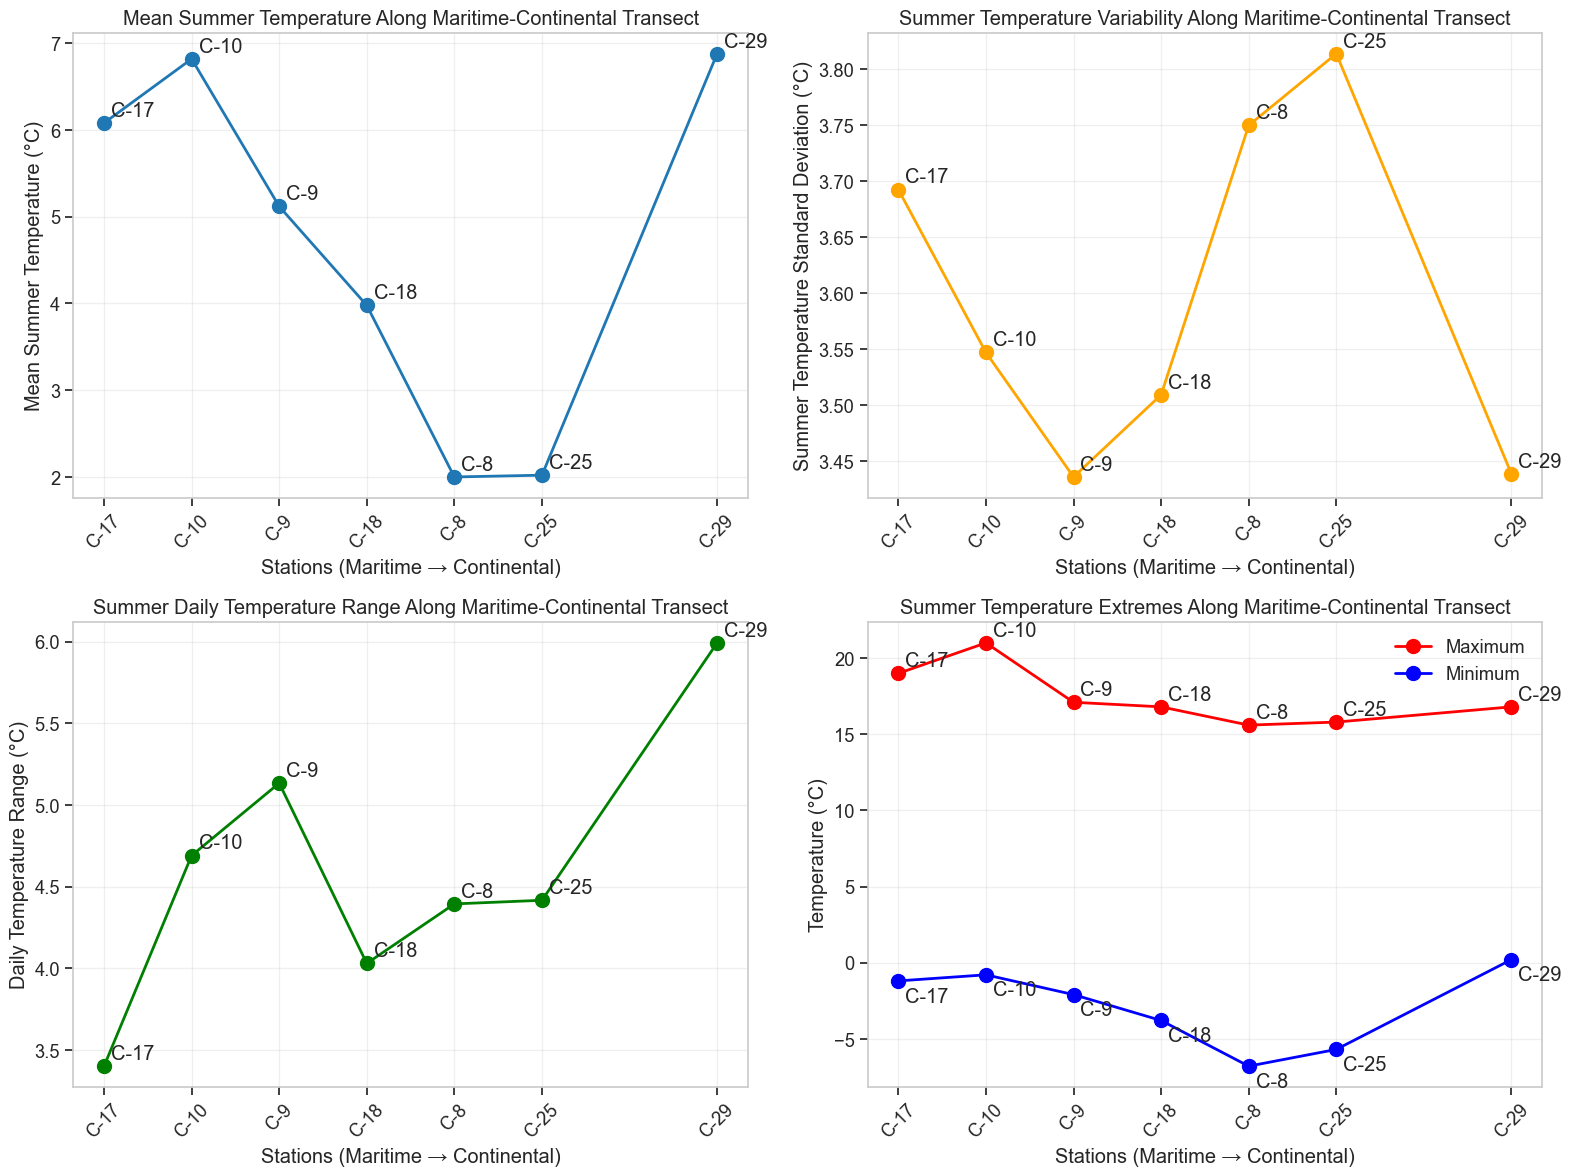

In [28]:
# --------------------------
# 1. Summer Temperature Metrics Along the Maritime-Continental Transect
# --------------------------
# Calculate key temperature metrics by station for summer
summer_metrics = df_daily_summer.groupby('Camp').agg({
    'site_temp_WMO': ['mean', 'std', 'min', 'max'],
    'site_temp_min': ['mean'],
    'site_temp_max': ['mean']
}).reset_index()

# Flatten the column hierarchy
summer_metrics.columns = ['_'.join(col).strip('_') for col in summer_metrics.columns.values]

# Calculate the daily temperature range
summer_metrics['daily_temp_range'] = summer_metrics['site_temp_max_mean'] - summer_metrics['site_temp_min_mean']

# Add transect position
summer_metrics['transect_pos'] = summer_metrics['Camp'].map(transect_position)

# For plotting, use only stations that exist in our transect order
summer_metrics = summer_metrics[summer_metrics['Camp'].isin(transect_order)]
summer_metrics_sorted = summer_metrics.sort_values('transect_pos')

# Create a figure
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

# Plot 1: Mean Summer Temperature along the transect
ax = axs[0]
ax.plot(summer_metrics_sorted['transect_pos'], summer_metrics_sorted['site_temp_WMO_mean'], 'o-', linewidth=2, markersize=10)
for i, row in summer_metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_mean']),
               xytext=(5, 5), textcoords='offset points')
ax.set_xticks(summer_metrics_sorted['transect_pos'])
ax.set_xticklabels(summer_metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Mean Summer Temperature (°C)')
ax.set_title('Mean Summer Temperature Along Maritime-Continental Transect')
ax.grid(True, alpha=0.3)

# Plot 2: Summer Temperature Variability (Standard Deviation)
ax = axs[1]
ax.plot(summer_metrics_sorted['transect_pos'], summer_metrics_sorted['site_temp_WMO_std'], 'o-', linewidth=2, markersize=10, color='orange')
for i, row in summer_metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_std']),
               xytext=(5, 5), textcoords='offset points')
ax.set_xticks(summer_metrics_sorted['transect_pos'])
ax.set_xticklabels(summer_metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Summer Temperature Standard Deviation (°C)')
ax.set_title('Summer Temperature Variability Along Maritime-Continental Transect')
ax.grid(True, alpha=0.3)

# Plot 3: Summer Daily Temperature Range
ax = axs[2]
ax.plot(summer_metrics_sorted['transect_pos'], summer_metrics_sorted['daily_temp_range'], 'o-', linewidth=2, markersize=10, color='green')
for i, row in summer_metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['daily_temp_range']),
               xytext=(5, 5), textcoords='offset points')
ax.set_xticks(summer_metrics_sorted['transect_pos'])
ax.set_xticklabels(summer_metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Daily Temperature Range (°C)')
ax.set_title('Summer Daily Temperature Range Along Maritime-Continental Transect')
ax.grid(True, alpha=0.3)

# Plot 4: Summer Temperature Extremes
ax = axs[3]
ax.plot(summer_metrics_sorted['transect_pos'], summer_metrics_sorted['site_temp_WMO_max'], 'o-', linewidth=2, markersize=10, color='red', label='Maximum')
ax.plot(summer_metrics_sorted['transect_pos'], summer_metrics_sorted['site_temp_WMO_min'], 'o-', linewidth=2, markersize=10, color='blue', label='Minimum')
for i, row in summer_metrics_sorted.iterrows():
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_max']),
               xytext=(5, 5), textcoords='offset points')
    ax.annotate(row['Camp'], (row['transect_pos'], row['site_temp_WMO_min']),
               xytext=(5, -15), textcoords='offset points')
ax.set_xticks(summer_metrics_sorted['transect_pos'])
ax.set_xticklabels(summer_metrics_sorted['Camp'], rotation=45)
ax.set_xlabel('Stations (Maritime → Continental)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Summer Temperature Extremes Along Maritime-Continental Transect')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



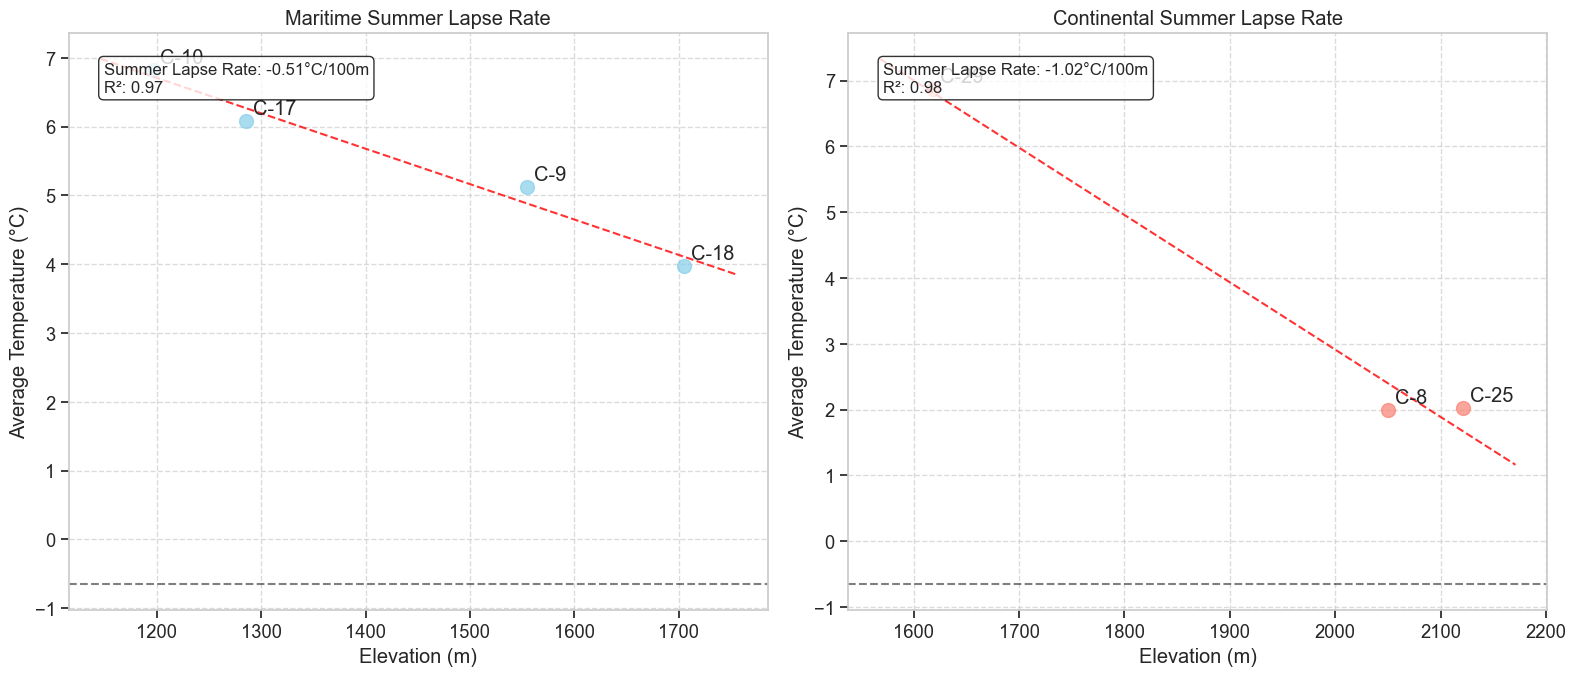

In [29]:
# --------------------------
# 2. Summer Lapse Rates - Maritime vs. Continental
# --------------------------
# Split the transect into maritime and continental segments
maritime_stations = ['C-17', 'C-10', 'C-9', 'C-18']
continental_stations = ['C-8', 'C-25', 'C-26', 'C-29']

# Function to calculate lapse rate
def calculate_lapse_rate(temps, elevations):
    """Calculate temperature lapse rate in °C/100m"""
    # Use only non-NaN pairs of temperature and elevation
    valid_mask = ~np.isnan(temps) & ~np.isnan(elevations)
    if sum(valid_mask) < 2:  # Need at least 2 points for regression
        return np.nan, np.nan, np.nan
    
    # Linear regression: temp ~ elevation
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        elevations[valid_mask], temps[valid_mask])
    
    # Convert slope to °C/100m
    lapse_rate = slope * 100
    
    return lapse_rate, r_value**2, p_value

# Calculate summer lapse rates for maritime and continental segments
maritime_data = df_daily_summer[df_daily_summer['Camp'].isin(maritime_stations)]
continental_data = df_daily_summer[df_daily_summer['Camp'].isin(continental_stations)]

# Calculate average lapse rates
maritime_elev_temp = maritime_data.groupby(['Camp', 'Elevation_m'])[temp_col_daily].mean().reset_index()
continental_elev_temp = continental_data.groupby(['Camp', 'Elevation_m'])[temp_col_daily].mean().reset_index()

maritime_lr, maritime_r2, _ = calculate_lapse_rate(
    maritime_elev_temp[temp_col_daily].values if len(maritime_elev_temp) >= 2 else [np.nan],
    maritime_elev_temp['Elevation_m'].values if len(maritime_elev_temp) >= 2 else [np.nan]
)

continental_lr, continental_r2, _ = calculate_lapse_rate(
    continental_elev_temp[temp_col_daily].values if len(continental_elev_temp) >= 2 else [np.nan],
    continental_elev_temp['Elevation_m'].values if len(continental_elev_temp) >= 2 else [np.nan]
)

# Create scatter plots with regression lines
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Maritime plot
if len(maritime_elev_temp) >= 2:
    ax1.scatter(maritime_elev_temp['Elevation_m'], maritime_elev_temp[temp_col_daily], 
               s=100, alpha=0.7, color='skyblue')
    
    # Add station labels
    for i, row in maritime_elev_temp.iterrows():
        ax1.annotate(row['Camp'], (row['Elevation_m'], row[temp_col_daily]),
                    xytext=(5, 5), textcoords='offset points')
    
    # Calculate and plot regression line
    x_range = np.linspace(maritime_elev_temp['Elevation_m'].min() - 50, 
                         maritime_elev_temp['Elevation_m'].max() + 50, 100)
    y_pred = maritime_lr/100 * x_range + (maritime_elev_temp[temp_col_daily].mean() - 
                                       maritime_lr/100 * maritime_elev_temp['Elevation_m'].mean())
    ax1.plot(x_range, y_pred, 'r--', alpha=0.8)
    
    lr_text = f"Summer Lapse Rate: {maritime_lr:.2f}°C/100m\nR²: {maritime_r2:.2f}"
    ax1.text(0.05, 0.95, lr_text, transform=ax1.transAxes, 
           fontsize=12, verticalalignment='top', 
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax1.set_title('Maritime Summer Lapse Rate')
    ax1.set_xlabel('Elevation (m)')
    ax1.set_ylabel('Average Temperature (°C)')
    ax1.grid(True, linestyle='--', alpha=0.7)

# Continental plot
if len(continental_elev_temp) >= 2:
    ax2.scatter(continental_elev_temp['Elevation_m'], continental_elev_temp[temp_col_daily], 
               s=100, alpha=0.7, color='salmon')
    
    # Add station labels
    for i, row in continental_elev_temp.iterrows():
        ax2.annotate(row['Camp'], (row['Elevation_m'], row[temp_col_daily]),
                    xytext=(5, 5), textcoords='offset points')
    
    # Calculate and plot regression line
    x_range = np.linspace(continental_elev_temp['Elevation_m'].min() - 50, 
                         continental_elev_temp['Elevation_m'].max() + 50, 100)
    y_pred = continental_lr/100 * x_range + (continental_elev_temp[temp_col_daily].mean() - 
                                          continental_lr/100 * continental_elev_temp['Elevation_m'].mean())
    ax2.plot(x_range, y_pred, 'r--', alpha=0.8)
    
    lr_text = f"Summer Lapse Rate: {continental_lr:.2f}°C/100m\nR²: {continental_r2:.2f}"
    ax2.text(0.05, 0.95, lr_text, transform=ax2.transAxes, 
           fontsize=12, verticalalignment='top', 
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax2.set_title('Continental Summer Lapse Rate')
    ax2.set_xlabel('Elevation (m)')
    ax2.set_ylabel('Average Temperature (°C)')
    ax2.grid(True, linestyle='--', alpha=0.7)

# Add a horizontal line at the standard environmental lapse rate on both plots
ax1.axhline(y=-0.65, color='k', linestyle='--', alpha=0.5, 
           label='Standard Env. Lapse Rate (-0.65°C/100m)')
ax2.axhline(y=-0.65, color='k', linestyle='--', alpha=0.5, 
           label='Standard Env. Lapse Rate (-0.65°C/100m)')

plt.tight_layout()
plt.show()



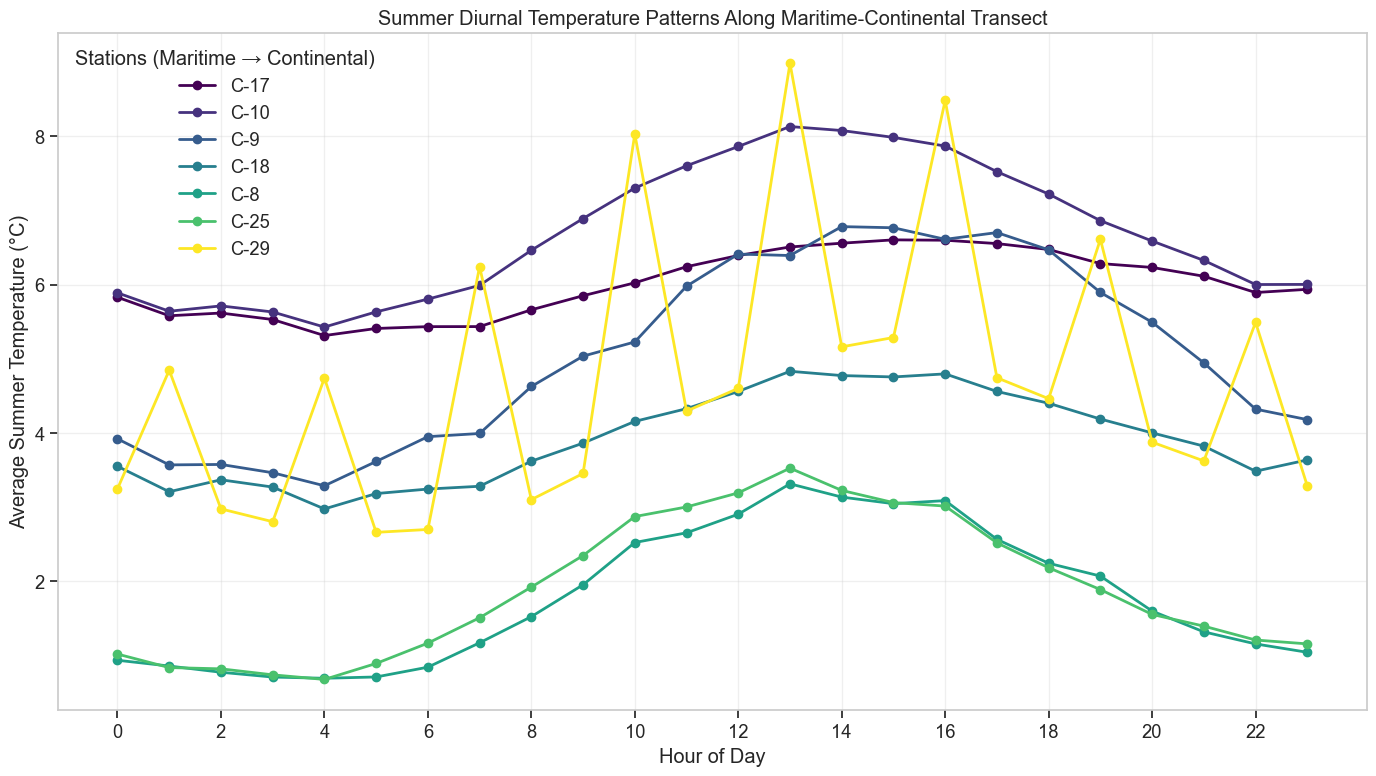

In [30]:
# --------------------------
# 3. Hourly Diurnal Temperature Pattern Analysis
# --------------------------
# Use hourly data to analyze diurnal temperature patterns along the transect
# Calculate average temperature by hour for each station in summer
hourly_summer_means = df_hourly_summer.groupby(['Camp', 'hour'])[temp_col_hourly].mean().reset_index()
hourly_summer_means['transect_pos'] = hourly_summer_means['Camp'].map(transect_position)

# Filter for stations in our transect
hourly_summer_means = hourly_summer_means[hourly_summer_means['Camp'].isin(transect_order)]

# Create plot
plt.figure(figsize=(14, 8))

# Create a colormap for the transect position
cmap = plt.cm.viridis
norm = plt.Normalize(0, len(transect_order)-1)

# Plot each station with color based on transect position
for camp in transect_order:
    if camp in hourly_summer_means['Camp'].values:
        station_data = hourly_summer_means[hourly_summer_means['Camp'] == camp]
        pos = transect_position[camp]
        plt.plot(station_data['hour'], station_data[temp_col_hourly], 'o-', 
                linewidth=2, label=camp, color=cmap(norm(pos)))

plt.xticks(range(0, 24, 2))
plt.xlabel('Hour of Day')
plt.ylabel('Average Summer Temperature (°C)')
plt.title('Summer Diurnal Temperature Patterns Along Maritime-Continental Transect')
plt.legend(title='Stations (Maritime → Continental)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



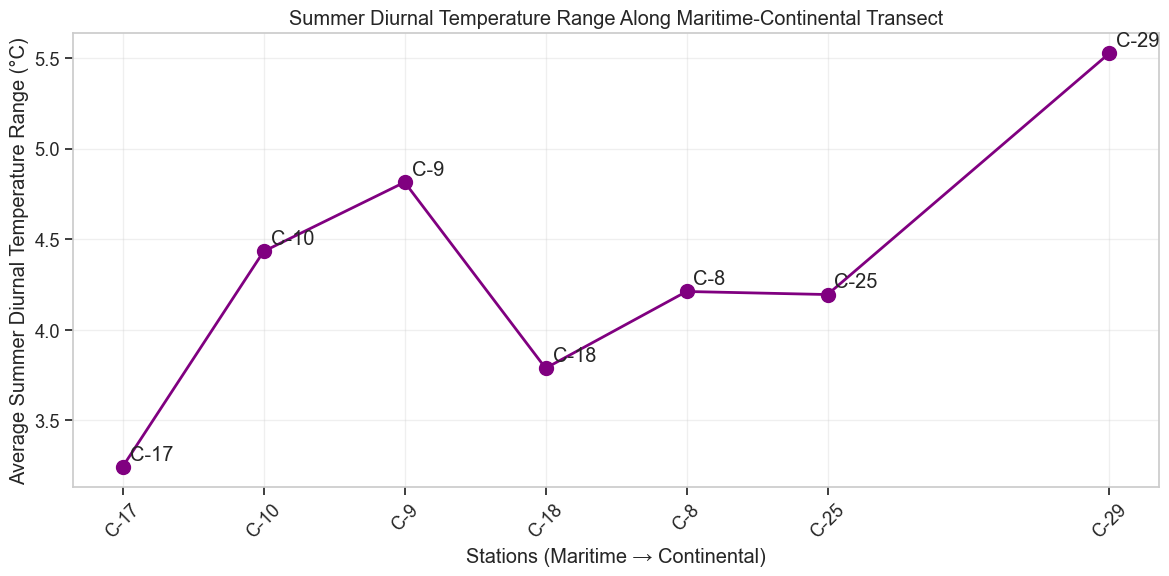

In [31]:
# --------------------------
# 4. Diurnal Temperature Range by Station (Hourly Data)
# --------------------------
# Calculate diurnal temperature range for each day and station
diurnal_ranges = df_hourly_summer.groupby(['Camp', 'date'])[temp_col_hourly].agg(['min', 'max']).reset_index()
diurnal_ranges['temp_range'] = diurnal_ranges['max'] - diurnal_ranges['min']

# Calculate average diurnal range by station
avg_diurnal_range = diurnal_ranges.groupby('Camp')['temp_range'].mean().reset_index()
avg_diurnal_range['transect_pos'] = avg_diurnal_range['Camp'].map(transect_position)

# Filter and sort
avg_diurnal_range = avg_diurnal_range[avg_diurnal_range['Camp'].isin(transect_order)]
avg_diurnal_range_sorted = avg_diurnal_range.sort_values('transect_pos')

# Create figure
plt.figure(figsize=(12, 6))
plt.plot(avg_diurnal_range_sorted['transect_pos'], avg_diurnal_range_sorted['temp_range'], 
        'o-', linewidth=2, markersize=10, color='purple')

# Add labels
for i, row in avg_diurnal_range_sorted.iterrows():
    plt.annotate(row['Camp'], (row['transect_pos'], row['temp_range']),
               xytext=(5, 5), textcoords='offset points')

plt.xticks(avg_diurnal_range_sorted['transect_pos'], avg_diurnal_range_sorted['Camp'], rotation=45)
plt.xlabel('Stations (Maritime → Continental)')
plt.ylabel('Average Summer Diurnal Temperature Range (°C)')
plt.title('Summer Diurnal Temperature Range Along Maritime-Continental Transect')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



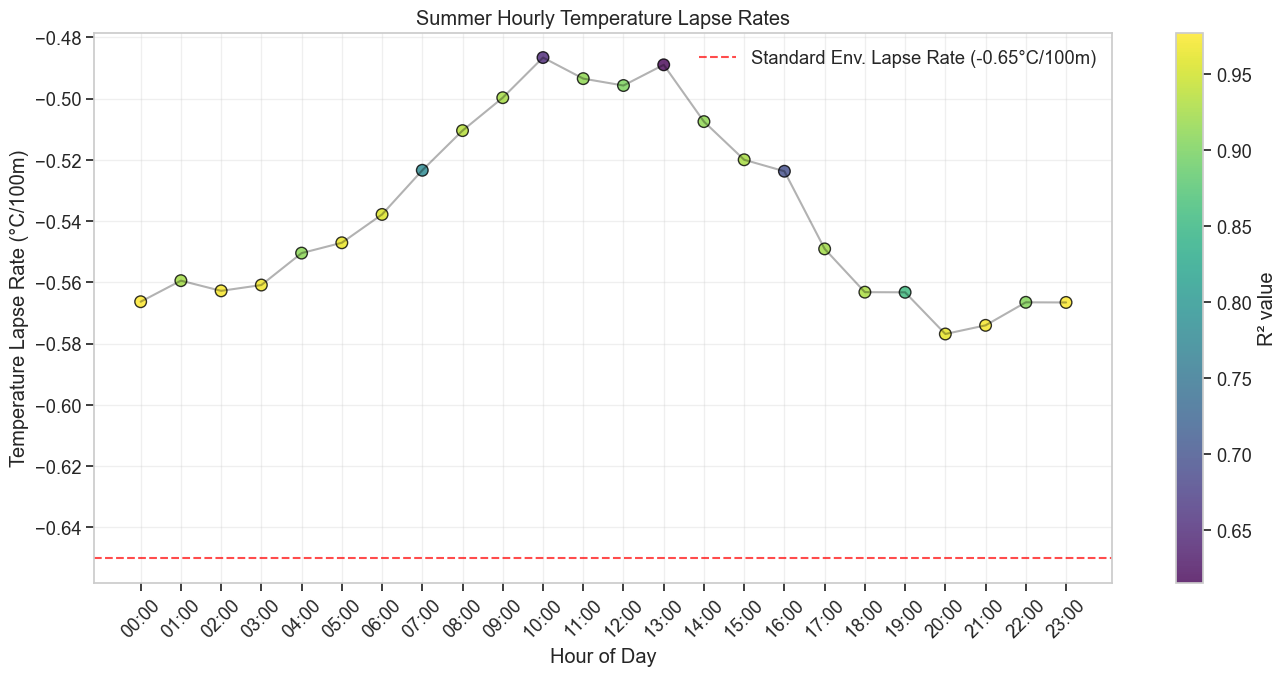

In [32]:
# --------------------------
# 5. Hourly Summer Lapse Rates by Time of Day
# --------------------------
# Calculate lapse rates for each hour of the day using summer hourly data
hourly_lapse_rates = np.zeros(24)
hourly_r2 = np.zeros(24)
hourly_counts = np.zeros(24)

# For each hour, calculate the lapse rate
for hour in range(24):
    hour_data = df_hourly_summer[df_hourly_summer['hour'] == hour]
    
    # Group by elevation and calculate average temperature
    elev_temp = hour_data.groupby(['Camp', 'Elevation_m'])[temp_col_hourly].mean().reset_index()
    
    if len(elev_temp) >= 3:  # Need at least 3 elevations
        # Calculate lapse rate
        lr, r2, _ = calculate_lapse_rate(
            elev_temp[temp_col_hourly].values, 
            elev_temp['Elevation_m'].values
        )
        
        hourly_lapse_rates[hour] = lr
        hourly_r2[hour] = r2
        hourly_counts[hour] = len(elev_temp)

# Create a figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot lapse rate by hour, color by R²
sc = ax.scatter(range(24), hourly_lapse_rates, 
              c=hourly_r2, cmap='viridis', 
              s=hourly_counts*10, alpha=0.8, edgecolor='k')

# Connect points with lines
ax.plot(range(24), hourly_lapse_rates, 'k-', alpha=0.3)

# Add colorbar for R² values
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('R² value')

# Add reference line for standard environmental lapse rate
ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7, 
           label='Standard Env. Lapse Rate (-0.65°C/100m)')

# Customize x-axis
ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)])
plt.xticks(rotation=45)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Temperature Lapse Rate (°C/100m)')
ax.set_title('Summer Hourly Temperature Lapse Rates')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()



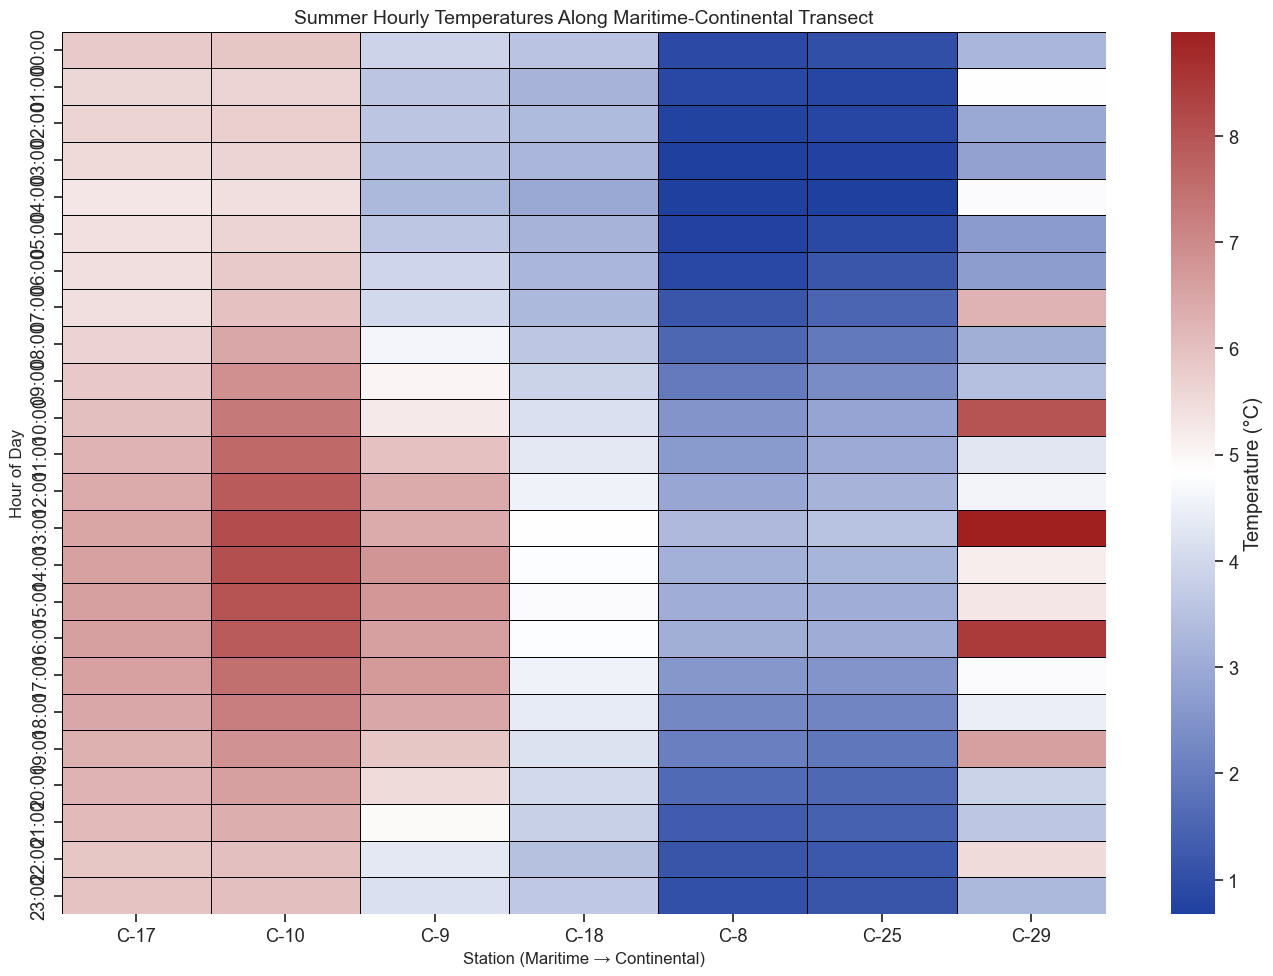

In [33]:
# --------------------------
# 6. Summer Daily Temperature Heatmap by Hour and Station
# --------------------------
# Create a pivot table: hours vs stations with temperature values
summer_pivot = pd.pivot_table(
    df_hourly_summer,
    index='hour', 
    columns='Camp', 
    values=temp_col_hourly,
    aggfunc='mean'
)

# Filter and sort by transect position
transect_cols = [col for col in summer_pivot.columns if col in transect_order]
summer_pivot = summer_pivot[transect_cols]
summer_pivot = summer_pivot[sorted(summer_pivot.columns, key=lambda x: transect_position.get(x, 999))]

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Custom colormap from blue (cold) to red (warm)
cmap = LinearSegmentedColormap.from_list('temp_cmap', ['#2040A0', '#FFFFFF', '#A02020'])

sns.heatmap(summer_pivot, cmap=cmap, 
           cbar_kws={'label': 'Temperature (°C)'}, ax=ax, 
           linewidths=0.5, linecolor='black')

ax.set_title('Summer Hourly Temperatures Along Maritime-Continental Transect', fontsize=14)
ax.set_xlabel('Station (Maritime → Continental)', fontsize=12)
ax.set_ylabel('Hour of Day', fontsize=12)

# Customize y-ticks to show hours in 24-hour format
hours = list(range(24))
ax.set_yticks(np.arange(0.5, 24.5))
ax.set_yticklabels([f"{h:02d}:00" for h in hours])

plt.tight_layout()
plt.show()



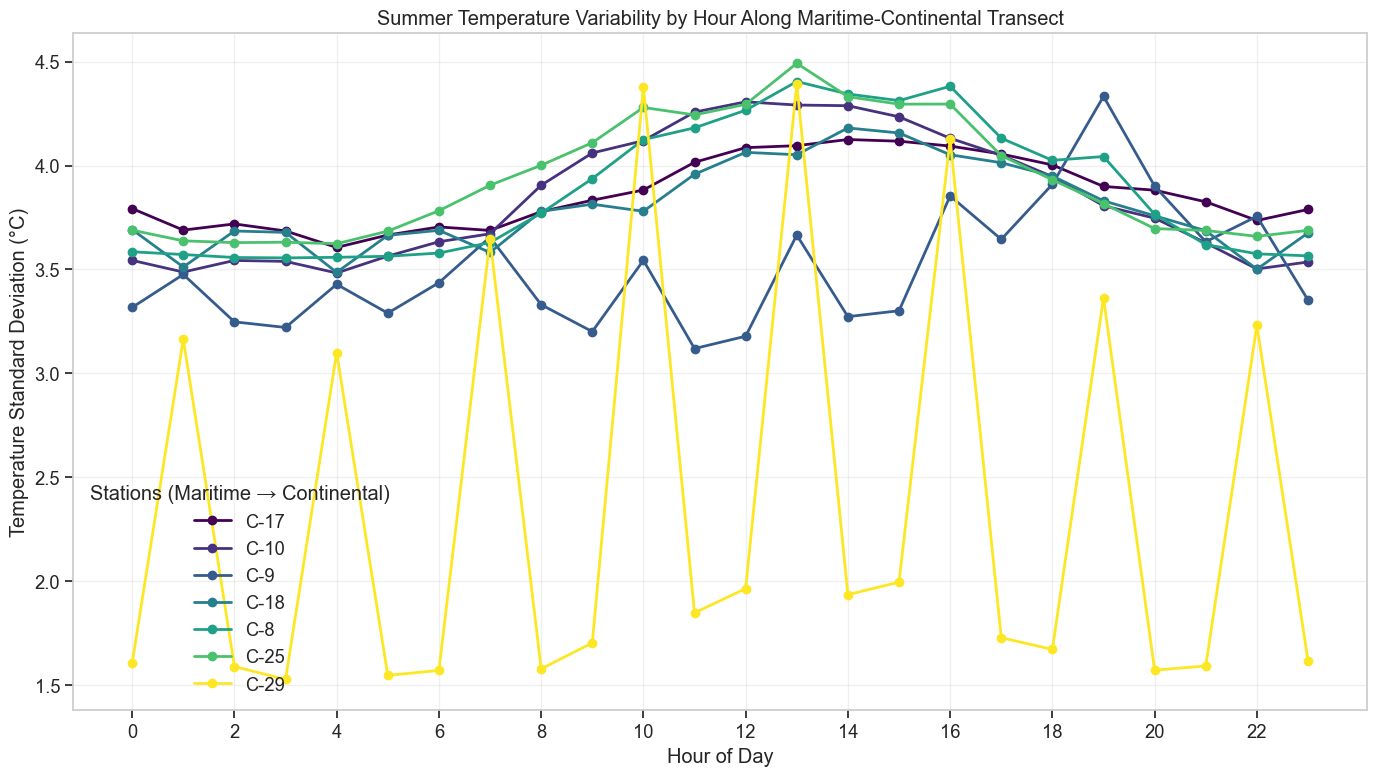

In [34]:
# --------------------------
# 7. Summer Temperature Variability by Hour
# --------------------------
# Calculate temperature standard deviation for each hour and station
hourly_summer_std = df_hourly_summer.groupby(['Camp', 'hour'])[temp_col_hourly].std().reset_index()
hourly_summer_std['transect_pos'] = hourly_summer_std['Camp'].map(transect_position)

# Filter for stations in our transect
hourly_summer_std = hourly_summer_std[hourly_summer_std['Camp'].isin(transect_order)]

# Create plot
plt.figure(figsize=(14, 8))

# Create a colormap for the transect position
cmap = plt.cm.viridis
norm = plt.Normalize(0, len(transect_order)-1)

# Plot each station with color based on transect position
for camp in transect_order:
    if camp in hourly_summer_std['Camp'].values:
        station_data = hourly_summer_std[hourly_summer_std['Camp'] == camp]
        pos = transect_position[camp]
        plt.plot(station_data['hour'], station_data[temp_col_hourly], 'o-', 
                linewidth=2, label=camp, color=cmap(norm(pos)))

plt.xticks(range(0, 24, 2))
plt.xlabel('Hour of Day')
plt.ylabel('Temperature Standard Deviation (°C)')
plt.title('Summer Temperature Variability by Hour Along Maritime-Continental Transect')
plt.legend(title='Stations (Maritime → Continental)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



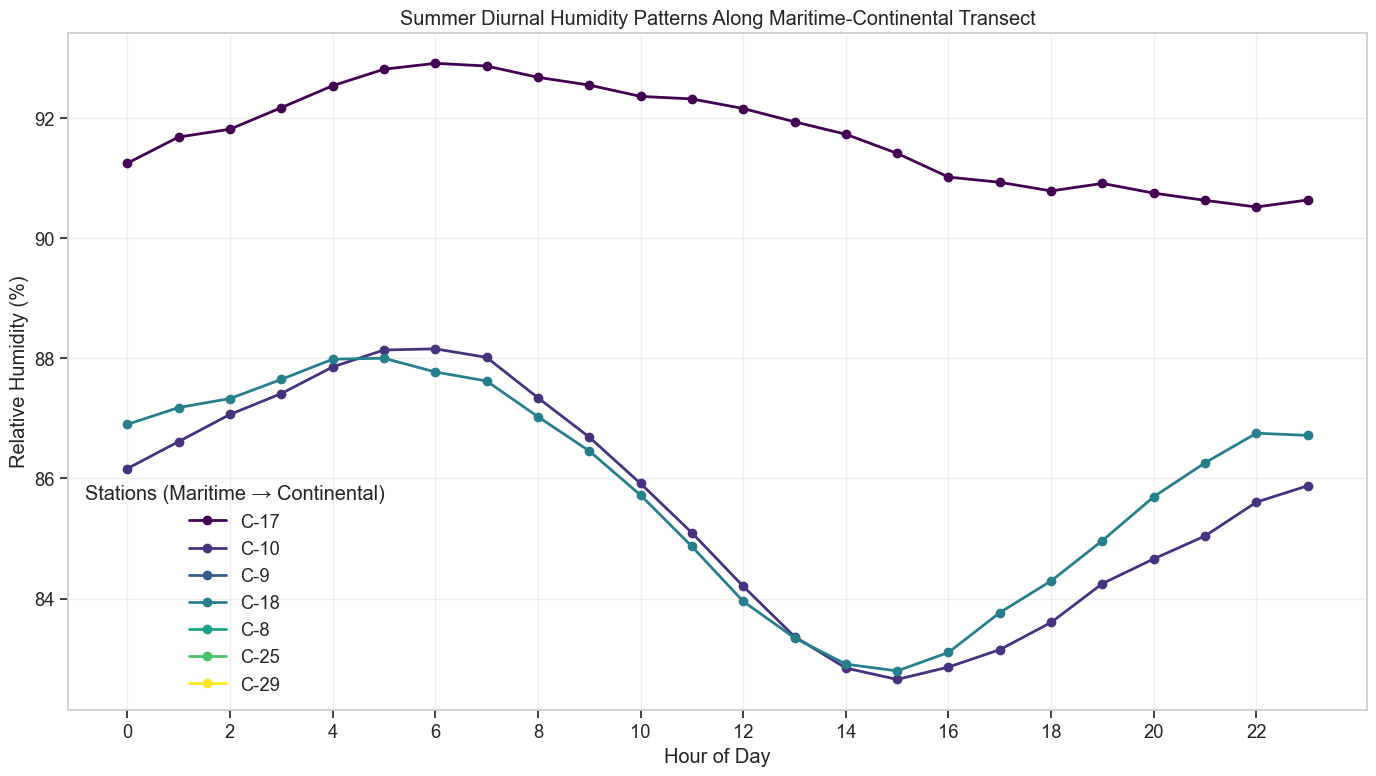

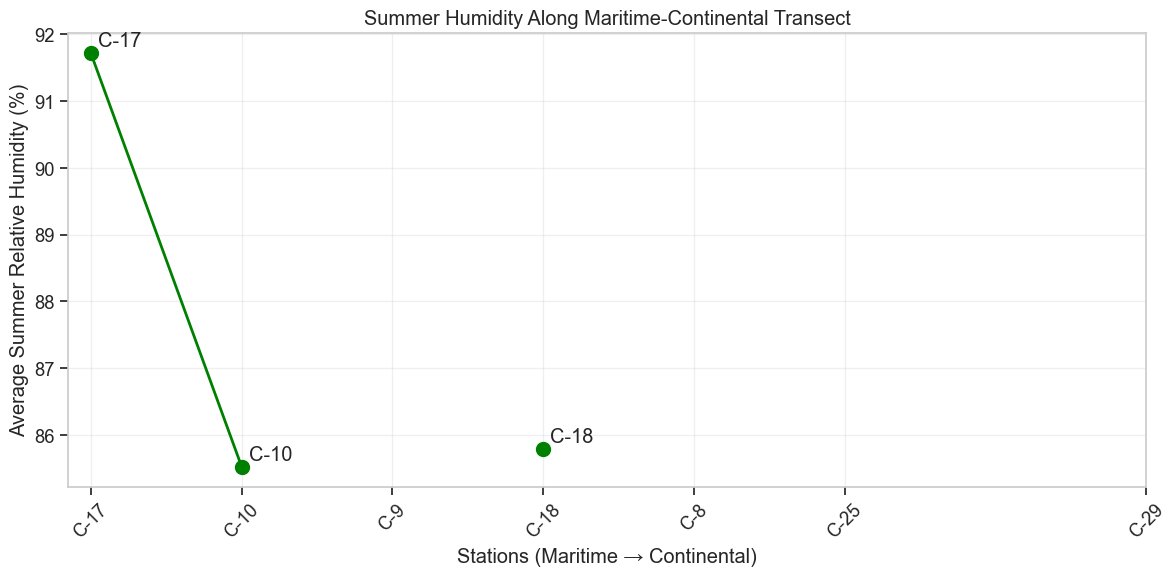

In [35]:
# --------------------------
# 8. Summer Humidity Analysis Along Transect (Hourly Data)
# --------------------------
if 'RelHum' in df_hourly_summer.columns:
    # Calculate hourly average humidity by station
    hourly_humidity = df_hourly_summer.groupby(['Camp', 'hour'])['RelHum'].mean().reset_index()
    hourly_humidity['transect_pos'] = hourly_humidity['Camp'].map(transect_position)
    
    # Filter for stations in our transect
    hourly_humidity = hourly_humidity[hourly_humidity['Camp'].isin(transect_order)]
    
    # Create plot
    plt.figure(figsize=(14, 8))
    
    # Plot each station with color based on transect position
    for camp in transect_order:
        if camp in hourly_humidity['Camp'].values:
            station_data = hourly_humidity[hourly_humidity['Camp'] == camp]
            pos = transect_position[camp]
            plt.plot(station_data['hour'], station_data['RelHum'], 'o-', 
                    linewidth=2, label=camp, color=cmap(norm(pos)))
    
    plt.xticks(range(0, 24, 2))
    plt.xlabel('Hour of Day')
    plt.ylabel('Relative Humidity (%)')
    plt.title('Summer Diurnal Humidity Patterns Along Maritime-Continental Transect')
    plt.legend(title='Stations (Maritime → Continental)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate average humidity by station
    avg_humidity = df_hourly_summer.groupby('Camp')['RelHum'].mean().reset_index()
    avg_humidity['transect_pos'] = avg_humidity['Camp'].map(transect_position)
    
    # Filter and sort
    avg_humidity = avg_humidity[avg_humidity['Camp'].isin(transect_order)]
    avg_humidity_sorted = avg_humidity.sort_values('transect_pos')
    
    # Create figure
    plt.figure(figsize=(12, 6))
    plt.plot(avg_humidity_sorted['transect_pos'], avg_humidity_sorted['RelHum'], 
            'o-', linewidth=2, markersize=10, color='green')
    
    # Add labels
    for i, row in avg_humidity_sorted.iterrows():
        plt.annotate(row['Camp'], (row['transect_pos'], row['RelHum']),
                   xytext=(5, 5), textcoords='offset points')
    
    plt.xticks(avg_humidity_sorted['transect_pos'], avg_humidity_sorted['Camp'], rotation=45)
    plt.xlabel('Stations (Maritime → Continental)')
    plt.ylabel('Average Summer Relative Humidity (%)')
    plt.title('Summer Humidity Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



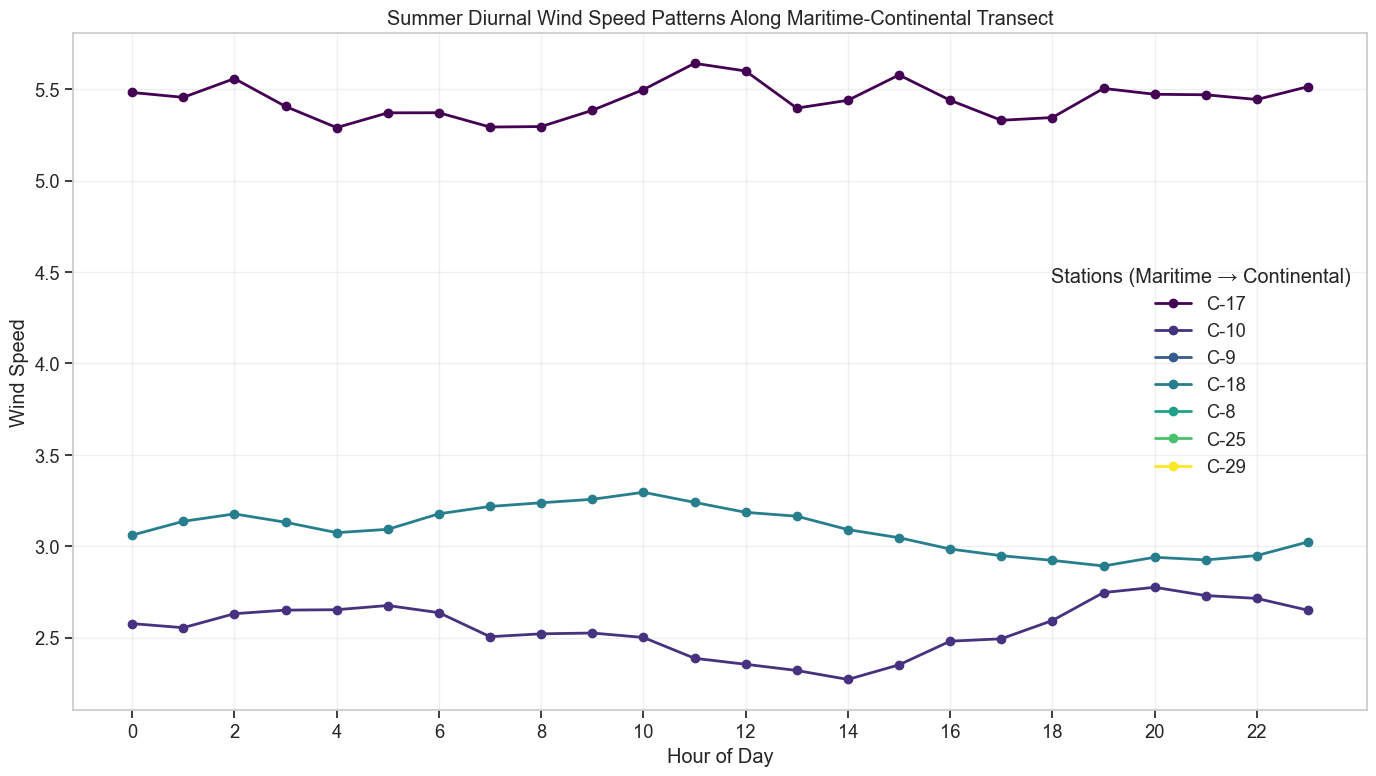

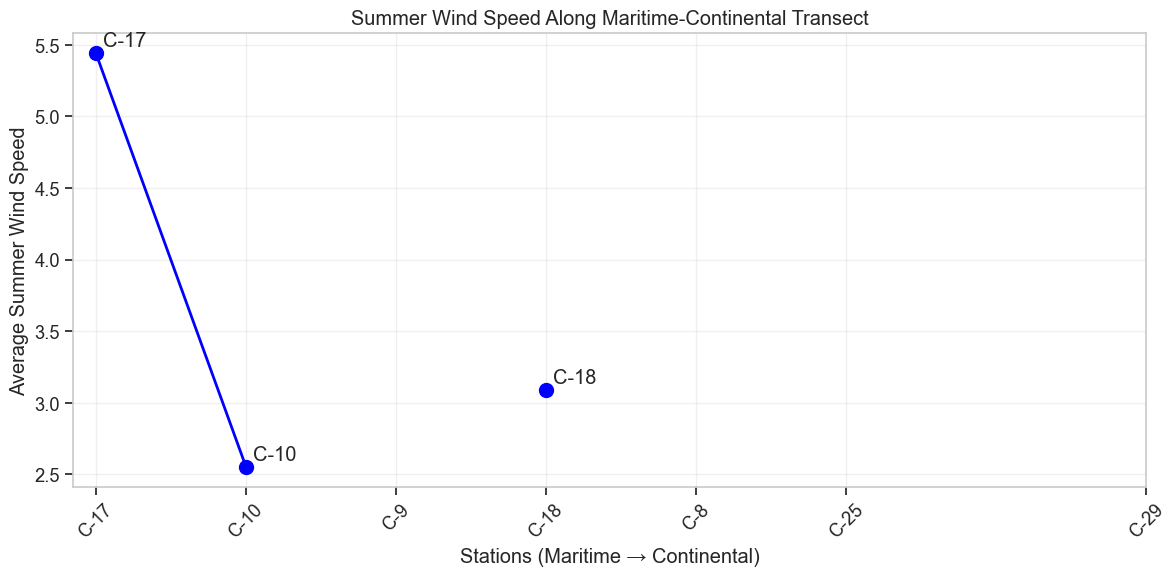

In [36]:
# --------------------------
# 9. Wind Speed Analysis for Summer (Hourly Data)
# --------------------------
if 'WindSpeed' in df_hourly_summer.columns:
    # Calculate hourly average wind speed by station
    hourly_wind = df_hourly_summer.groupby(['Camp', 'hour'])['WindSpeed'].mean().reset_index()
    hourly_wind['transect_pos'] = hourly_wind['Camp'].map(transect_position)
    
    # Filter for stations in our transect
    hourly_wind = hourly_wind[hourly_wind['Camp'].isin(transect_order)]
    
    # Create plot
    plt.figure(figsize=(14, 8))
    
    # Plot each station with color based on transect position
    for camp in transect_order:
        if camp in hourly_wind['Camp'].values:
            station_data = hourly_wind[hourly_wind['Camp'] == camp]
            pos = transect_position[camp]
            plt.plot(station_data['hour'], station_data['WindSpeed'], 'o-', 
                    linewidth=2, label=camp, color=cmap(norm(pos)))
    
    plt.xticks(range(0, 24, 2))
    plt.xlabel('Hour of Day')
    plt.ylabel('Wind Speed')
    plt.title('Summer Diurnal Wind Speed Patterns Along Maritime-Continental Transect')
    plt.legend(title='Stations (Maritime → Continental)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate average wind speed by station
    avg_wind = df_hourly_summer.groupby('Camp')['WindSpeed'].mean().reset_index()
    avg_wind['transect_pos'] = avg_wind['Camp'].map(transect_position)
    
    # Filter and sort
    avg_wind = avg_wind[avg_wind['Camp'].isin(transect_order)]
    avg_wind_sorted = avg_wind.sort_values('transect_pos')
    
    # Create figure
    plt.figure(figsize=(12, 6))
    plt.plot(avg_wind_sorted['transect_pos'], avg_wind_sorted['WindSpeed'], 
            'o-', linewidth=2, markersize=10, color='blue')
    
    # Add labels
    for i, row in avg_wind_sorted.iterrows():
        plt.annotate(row['Camp'], (row['transect_pos'], row['WindSpeed']),
                   xytext=(5, 5), textcoords='offset points')
    
    plt.xticks(avg_wind_sorted['transect_pos'], avg_wind_sorted['Camp'], rotation=45)
    plt.xlabel('Stations (Maritime → Continental)')
    plt.ylabel('Average Summer Wind Speed')
    plt.title('Summer Wind Speed Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



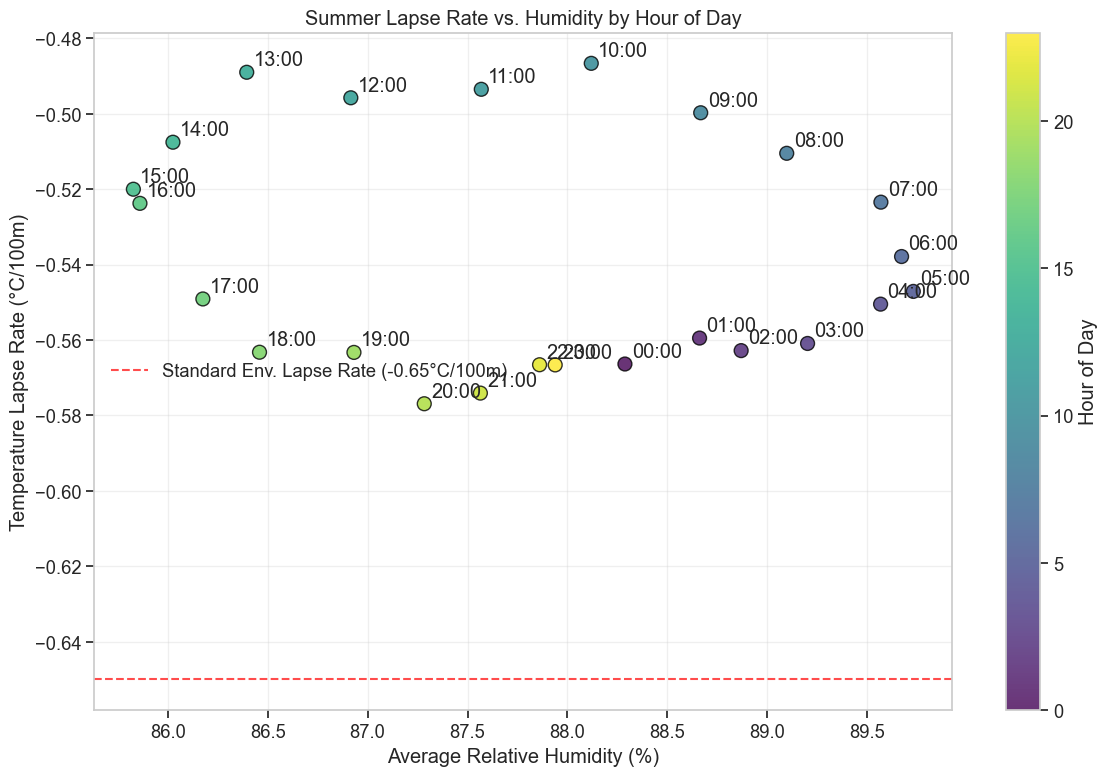

In [37]:
# --------------------------
# 10. Summer Lapse Rate vs. Humidity Analysis
# --------------------------
if 'RelHum' in df_hourly_summer.columns:
    # Calculate hourly lapse rates and average humidity
    lapse_rates_by_hour = []
    humidity_by_hour = []
    hours = []
    r2_values = []
    
    for hour in range(24):
        hour_data = df_hourly_summer[df_hourly_summer['hour'] == hour]
        
        # Calculate lapse rate
        elev_temp = hour_data.groupby(['Camp', 'Elevation_m'])[temp_col_hourly].mean().reset_index()
        if len(elev_temp) >= 3:
            lr, r2, _ = calculate_lapse_rate(
                elev_temp[temp_col_hourly].values, 
                elev_temp['Elevation_m'].values
            )
            
            # Calculate average humidity for this hour
            avg_humidity = hour_data['RelHum'].mean()
            
            lapse_rates_by_hour.append(lr)
            humidity_by_hour.append(avg_humidity)
            hours.append(hour)
            r2_values.append(r2)
    
    # Create scatter plot
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(humidity_by_hour, lapse_rates_by_hour, 
                        c=hours, cmap='viridis', 
                        s=100, alpha=0.8, edgecolor='k')
    
    # Add hour labels
    for i, hour in enumerate(hours):
        plt.annotate(f"{hour:02d}:00", (humidity_by_hour[i], lapse_rates_by_hour[i]),
                   xytext=(5, 5), textcoords='offset points')
    
    # Add colorbar for hour of day
    cbar = plt.colorbar(scatter)
    cbar.set_label('Hour of Day')
    
    # Add reference line for standard environmental lapse rate
    plt.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7, 
               label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    plt.xlabel('Average Relative Humidity (%)')
    plt.ylabel('Temperature Lapse Rate (°C/100m)')
    plt.title('Summer Lapse Rate vs. Humidity by Hour of Day')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [45]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates
from scipy import stats
from sklearn.decomposition import PCA
from scipy.signal import detrend
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from jiflr import ROOT

# Set the style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the McGee JIRP hourly data
mcgee_data_path = Path(ROOT, "notebooks/camp-wx-lapse-rate/processed_data/mcgee_jirp_hourly_weather_data.csv")
df_mcgee = pd.read_csv(mcgee_data_path)

# Convert datetime to proper datetime format
df_mcgee['datetime'] = pd.to_datetime(df_mcgee['datetime'], format="mixed")
df_mcgee['date'] = pd.to_datetime(df_mcgee['date'])

# Extract time components
df_mcgee['month'] = df_mcgee['datetime'].dt.month
df_mcgee['hour'] = df_mcgee['datetime'].dt.hour
df_mcgee['year'] = df_mcgee['datetime'].dt.year
df_mcgee['day'] = df_mcgee['datetime'].dt.day
df_mcgee['season'] = pd.cut(df_mcgee['month'], 
                            bins=[0, 3, 6, 9, 12],
                            labels=['Winter', 'Spring', 'Summer', 'Fall'])

# Filter for summer months (June, July, August)
df_mcgee_summer = df_mcgee[(df_mcgee['month'] >= 6) & (df_mcgee['month'] <= 8)]

# Convert temperature from Fahrenheit to Celsius if needed
if df_mcgee['temperature'].mean() > 40:  # Likely Fahrenheit
    df_mcgee['temperature_c'] = (df_mcgee['temperature'] - 32) * 5/9
    df_mcgee_summer['temperature_c'] = (df_mcgee_summer['temperature'] - 32) * 5/9
    temp_col = 'temperature_c'
else:
    temp_col = 'temperature'

# Define the transect order from maritime to continental
transect_order = ['C-17', 'C-10', 'C-9', 'C-18', 'C-8', 'C-25', 'C-26', 'C-29', 'C-30']

# Create a numeric index for the position in the transect
transect_position = {camp: i for i, camp in enumerate(transect_order)}

# Add transect position to the dataframes
df_mcgee['transect_pos'] = df_mcgee['camp_id'].map(transect_position)
df_mcgee_summer['transect_pos'] = df_mcgee_summer['camp_id'].map(transect_position)

# Split stations into maritime and continental segments
maritime_stations = ['C-17', 'C-10', 'C-9', 'C-18']
continental_stations = ['C-8', 'C-25', 'C-26', 'C-29', 'C-30']

# Function to calculate lapse rate
def calculate_lapse_rate(temps, elevations):
    """Calculate temperature lapse rate in °C/100m"""
    # Use only non-NaN pairs of temperature and elevation
    valid_mask = ~np.isnan(temps) & ~np.isnan(elevations)
    if sum(valid_mask) < 2:  # Need at least 2 points for regression
        return np.nan, np.nan, np.nan
    
    # Linear regression: temp ~ elevation
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        elevations[valid_mask], temps[valid_mask])
    
    # Convert slope to °C/100m
    lapse_rate = slope * 100
    
    return lapse_rate, r_value**2, p_value

# Display basic information about the dataset
print(f"Total records: {len(df_mcgee)}")
print(f"Summer records: {len(df_mcgee_summer)}")
print(f"Date range: {df_mcgee['datetime'].min()} to {df_mcgee['datetime'].max()}")
print(f"Unique stations: {df_mcgee['camp_id'].nunique()}")
print(f"Stations: {sorted(df_mcgee['camp_id'].unique())}")

# Check if we have elevation data for all stations
elevation_summary = df_mcgee.groupby('camp_id')['elevation'].first().reset_index()
print("\nElevation data by station:")
print(elevation_summary)



Total records: 1286726
Summer records: 318588
Date range: 1998-07-20 09:59:59.999000 to 2024-08-09 14:59:59.999000
Unique stations: 7
Stations: ['C-10', 'C-17', 'C-18', 'C-25', 'C-26', 'C-30', 'C-8']

Elevation data by station:
  camp_id  elevation
0    C-10       1196
1    C-17       1285
2    C-18       1705
3    C-25       2121
4    C-26       1435
5    C-30        674
6     C-8       2050


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/2577910469.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mcgee_summer['transect_pos'] = df_mcgee_summer['camp_id'].map(transect_position)


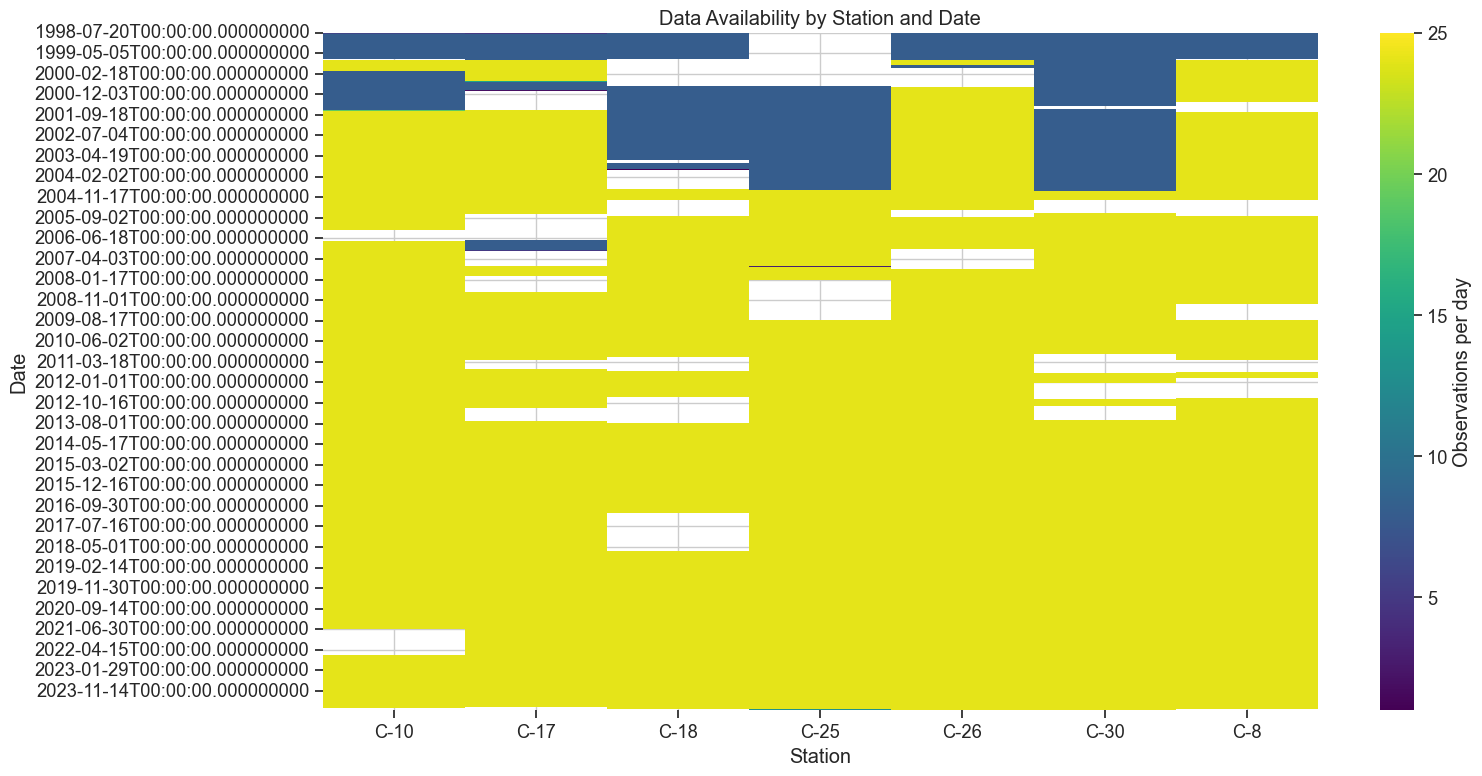

In [46]:
# --------------------------
# 1. Data Availability and Completeness
# --------------------------
# Visualize data availability by station and date
plt.figure(figsize=(16, 8))

# Count observations by station and date
availability = df_mcgee.groupby(['date', 'camp_id']).size().reset_index(name='count')

# Create a pivot table
pivot_avail = availability.pivot(index='date', columns='camp_id', values='count')

# Plot availability heatmap
sns.heatmap(pivot_avail, cmap='viridis', cbar_kws={'label': 'Observations per day'})
plt.title('Data Availability by Station and Date')
plt.ylabel('Date')
plt.xlabel('Station')
plt.tight_layout()
plt.show()



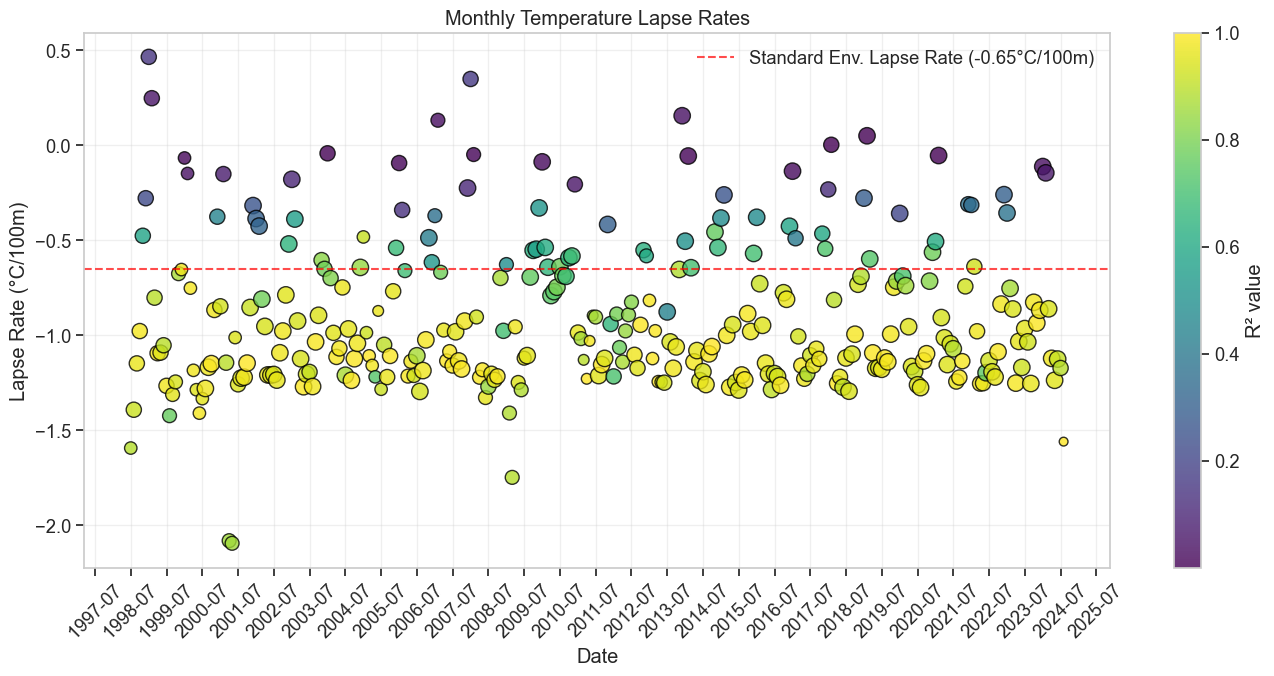

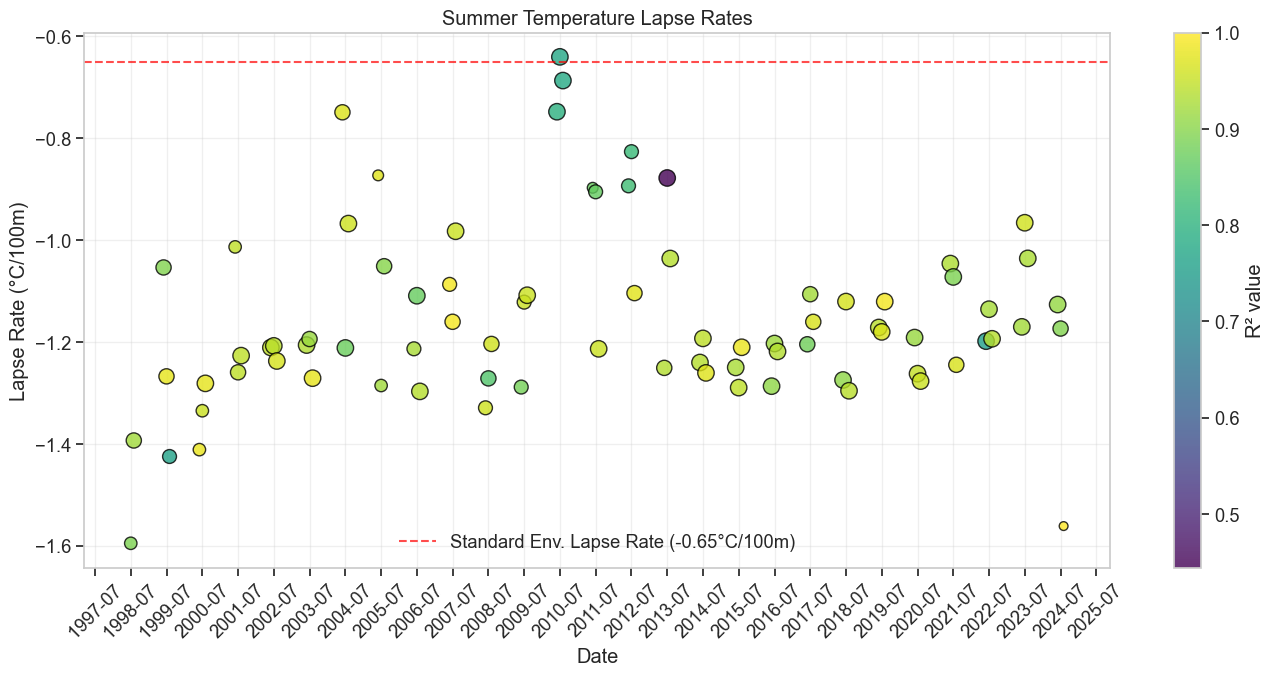

In [51]:
# --------------------------
# 2. Monthly Lapse Rates for Whole Dataset
# --------------------------
# Create a dataframe to store monthly lapse rates
monthly_lapse_rates = []

# Group by year and month
for (year, month), group in df_mcgee.groupby(['year', 'month']):
    # Group by station and calculate average temperature
    station_temps = group.groupby(['camp_id', 'elevation'])[temp_col].mean().reset_index()
    
    # Only calculate lapse rate if we have enough stations with elevation data
    valid_stations = station_temps.dropna(subset=['elevation'])
    if len(valid_stations) >= 2:
        # Calculate lapse rate
        lr, r2, p = calculate_lapse_rate(
            valid_stations[temp_col].values,
            valid_stations['elevation'].values
        )
        
        # Store results
        monthly_lapse_rates.append({
            'year': year,
            'month': month,
            'lapse_rate': lr,
            'r2': r2,
            'p_value': p,
            'stations_used': len(valid_stations)
        })

monthly_lr_df = pd.DataFrame(monthly_lapse_rates)

if not monthly_lr_df.empty:
    # Create a date column for plotting
    monthly_lr_df['date'] = pd.to_datetime(monthly_lr_df[['year', 'month']].assign(day=1))
    
    # Plot monthly lapse rates
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Scatter plot with size proportional to number of stations and color by R²
    scatter = ax.scatter(monthly_lr_df['date'], monthly_lr_df['lapse_rate'],
                        s=monthly_lr_df['stations_used'] * 20,
                        c=monthly_lr_df['r2'], cmap='viridis',
                        alpha=0.8, edgecolor='k')
    
    # Add reference line for standard environmental lapse rate
    ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7,
               label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    plt.xticks(rotation=45)
    
    # Add colorbar for R² values
    cbar = plt.colorbar(scatter)
    cbar.set_label('R² value')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title('Monthly Temperature Lapse Rates')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Focus on summer months
    summer_lr_df = monthly_lr_df[monthly_lr_df['month'].isin([6, 7, 8])]
    
    if not summer_lr_df.empty:
        fig, ax = plt.subplots(figsize=(14, 7))
        
        # Scatter plot with size proportional to number of stations and color by R²
        scatter = ax.scatter(summer_lr_df['date'], summer_lr_df['lapse_rate'],
                            s=summer_lr_df['stations_used'] * 20,
                            c=summer_lr_df['r2'], cmap='viridis',
                            alpha=0.8, edgecolor='k')
        
        # Add reference line for standard environmental lapse rate
        ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7,
                   label='Standard Env. Lapse Rate (-0.65°C/100m)')
        
        # Format x-axis
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
        plt.xticks(rotation=45)
        
        # Add colorbar for R² values
        cbar = plt.colorbar(scatter)
        cbar.set_label('R² value')
        
        ax.set_xlabel('Date')
        ax.set_ylabel('Lapse Rate (°C/100m)')
        ax.set_title('Summer Temperature Lapse Rates')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        plt.tight_layout()
        plt.show()
        


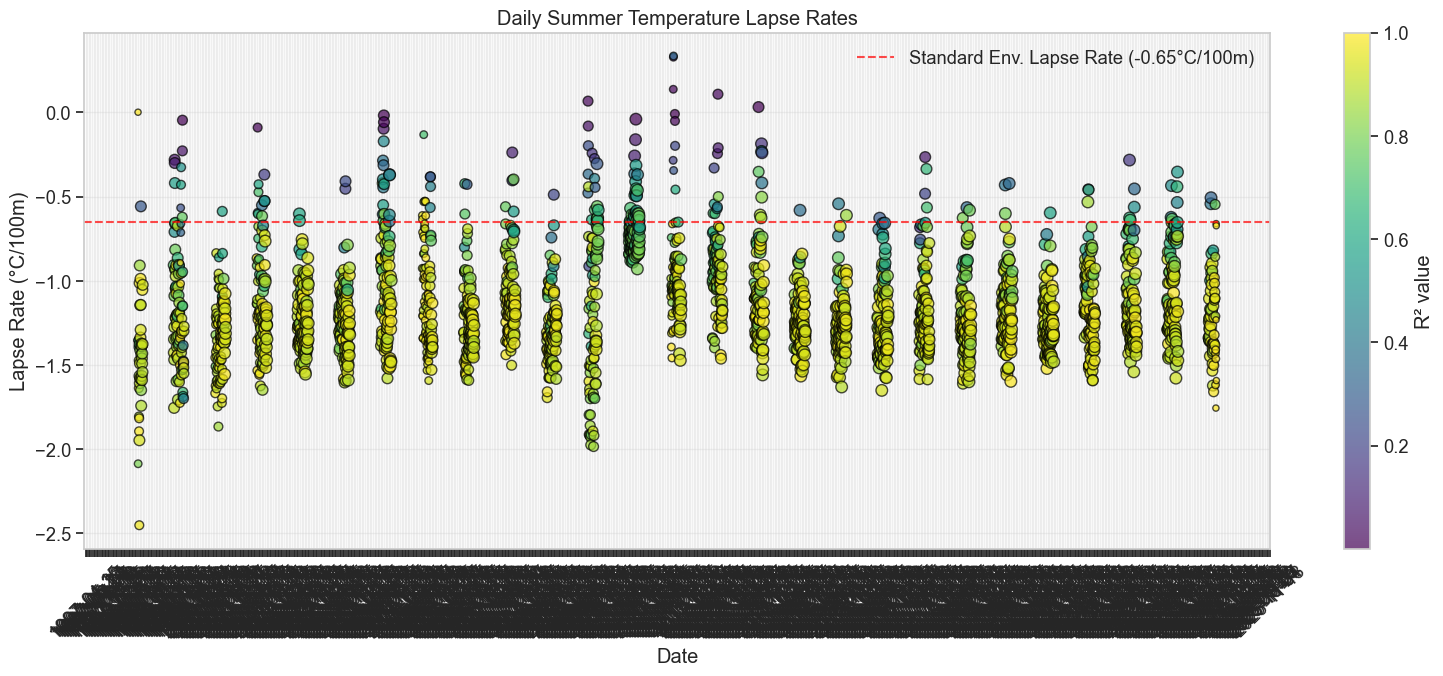

In [52]:
# --------------------------
# 3. Daily Lapse Rates for Summer
# --------------------------
# Calculate daily lapse rates for summer
daily_lapse_rates = []

for date, group in df_mcgee_summer.groupby('date'):
    # Group by station and calculate average temperature
    station_temps = group.groupby(['camp_id', 'elevation'])[temp_col].mean().reset_index()
    
    # Only calculate lapse rate if we have enough stations with elevation data
    valid_stations = station_temps.dropna(subset=['elevation'])
    if len(valid_stations) >= 2:
        # Calculate lapse rate
        lr, r2, p = calculate_lapse_rate(
            valid_stations[temp_col].values,
            valid_stations['elevation'].values
        )
        
        # Store results
        daily_lapse_rates.append({
            'date': date,
            'lapse_rate': lr,
            'r2': r2,
            'p_value': p,
            'stations_used': len(valid_stations)
        })

daily_lr_df = pd.DataFrame(daily_lapse_rates)

if not daily_lr_df.empty:
    # Plot daily lapse rates
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Scatter plot with size proportional to number of stations and color by R²
    scatter = ax.scatter(daily_lr_df['date'], daily_lr_df['lapse_rate'],
                        s=daily_lr_df['stations_used'] * 10,
                        c=daily_lr_df['r2'], cmap='viridis',
                        alpha=0.7, edgecolor='k')
    
    # Add reference line for standard environmental lapse rate
    ax.axhline(y=-0.65, color='r', linestyle='--', alpha=0.7,
               label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=45)
    
    # Add colorbar for R² values
    cbar = plt.colorbar(scatter)
    cbar.set_label('R² value')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title('Daily Summer Temperature Lapse Rates')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()



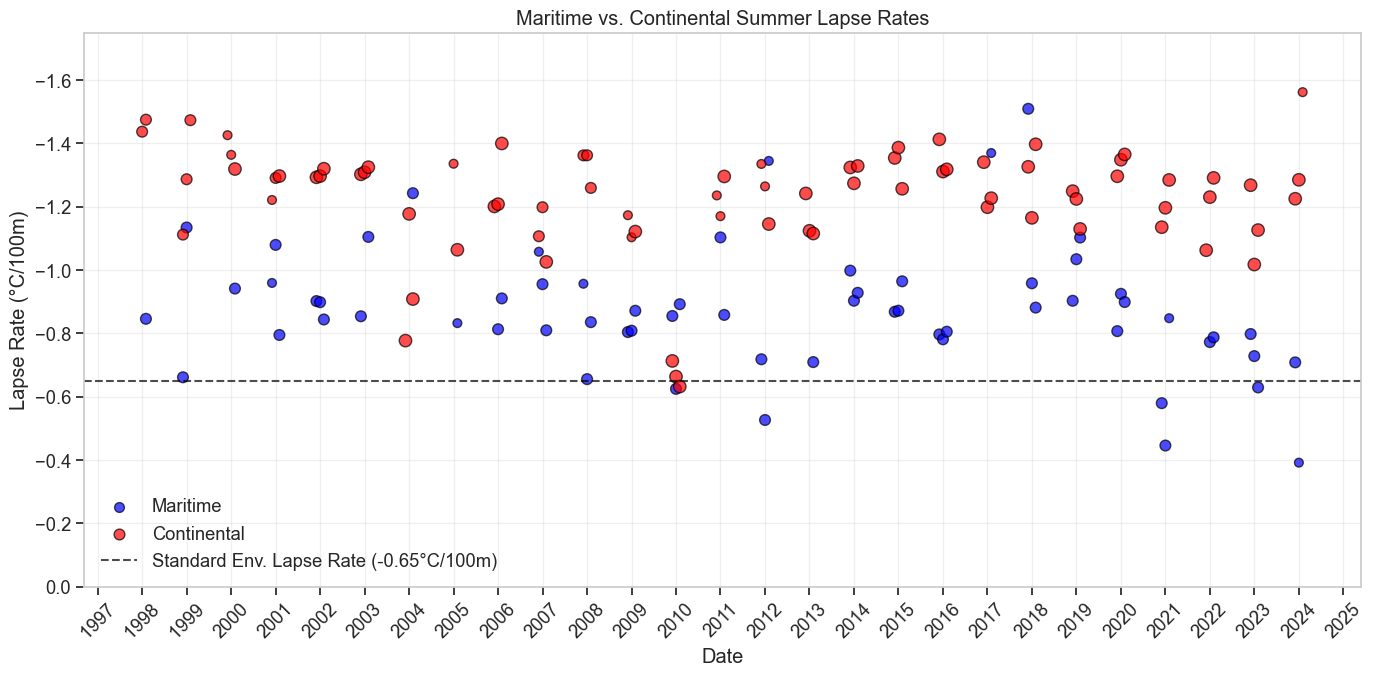

In [57]:
# --------------------------
# 4. Maritime vs. Continental Summer Lapse Rates
# --------------------------
# Calculate monthly lapse rates for maritime and continental regions separately
maritime_monthly_lr = []
continental_monthly_lr = []

for (year, month), group in df_mcgee.groupby(['year', 'month']):
    # Maritime lapse rate
    maritime_data = group[group['camp_id'].isin(maritime_stations)]
    station_temps = maritime_data.groupby(['camp_id', 'elevation'])[temp_col].mean().reset_index()
    valid_stations = station_temps.dropna(subset=['elevation'])
    
    if len(valid_stations) >= 2:
        lr, r2, p = calculate_lapse_rate(
            valid_stations[temp_col].values,
            valid_stations['elevation'].values
        )
        
        maritime_monthly_lr.append({
            'year': year,
            'month': month,
            'lapse_rate': lr,
            'r2': r2,
            'stations_used': len(valid_stations)
        })
    
    # Continental lapse rate
    continental_data = group[group['camp_id'].isin(continental_stations)]
    station_temps = continental_data.groupby(['camp_id', 'elevation'])[temp_col].mean().reset_index()
    valid_stations = station_temps.dropna(subset=['elevation'])
    
    if len(valid_stations) >= 2:
        lr, r2, p = calculate_lapse_rate(
            valid_stations[temp_col].values,
            valid_stations['elevation'].values
        )
        
        continental_monthly_lr.append({
            'year': year,
            'month': month,
            'lapse_rate': lr,
            'r2': r2,
            'stations_used': len(valid_stations)
        })

maritime_lr_df = pd.DataFrame(maritime_monthly_lr)
continental_lr_df = pd.DataFrame(continental_monthly_lr)

# Filter for summer months
if not maritime_lr_df.empty:
    maritime_lr_df['date'] = pd.to_datetime(maritime_lr_df[['year', 'month']].assign(day=1))
    maritime_summer_lr = maritime_lr_df[maritime_lr_df['month'].isin([6, 7, 8])]

if not continental_lr_df.empty:
    continental_lr_df['date'] = pd.to_datetime(continental_lr_df[['year', 'month']].assign(day=1))
    continental_summer_lr = continental_lr_df[continental_lr_df['month'].isin([6, 7, 8])]

# Create plot if we have data
if (not maritime_summer_lr.empty or not continental_summer_lr.empty):
    fig, ax = plt.subplots(figsize=(14, 7))
    
    if not maritime_summer_lr.empty:
        ax.scatter(maritime_summer_lr['date'], maritime_summer_lr['lapse_rate'],
                 s=maritime_summer_lr['stations_used'] * 20, alpha=0.7,
                 color='blue', label='Maritime', edgecolor='k')
    
    if not continental_summer_lr.empty:
        ax.scatter(continental_summer_lr['date'], continental_summer_lr['lapse_rate'],
                 s=continental_summer_lr['stations_used'] * 20, alpha=0.7,
                 color='red', label='Continental', edgecolor='k')
    
    # Add reference line for standard environmental lapse rate
    ax.axhline(y=-0.65, color='k', linestyle='--', alpha=0.7,
               label='Standard Env. Lapse Rate (-0.65°C/100m)')
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))
    plt.xticks(rotation=45)
    
    ax.set_ylim(0, -1.75)
    ax.set_xlabel('Date')
    ax.set_ylabel('Lapse Rate (°C/100m)')
    ax.set_title('Maritime vs. Continental Summer Lapse Rates')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()



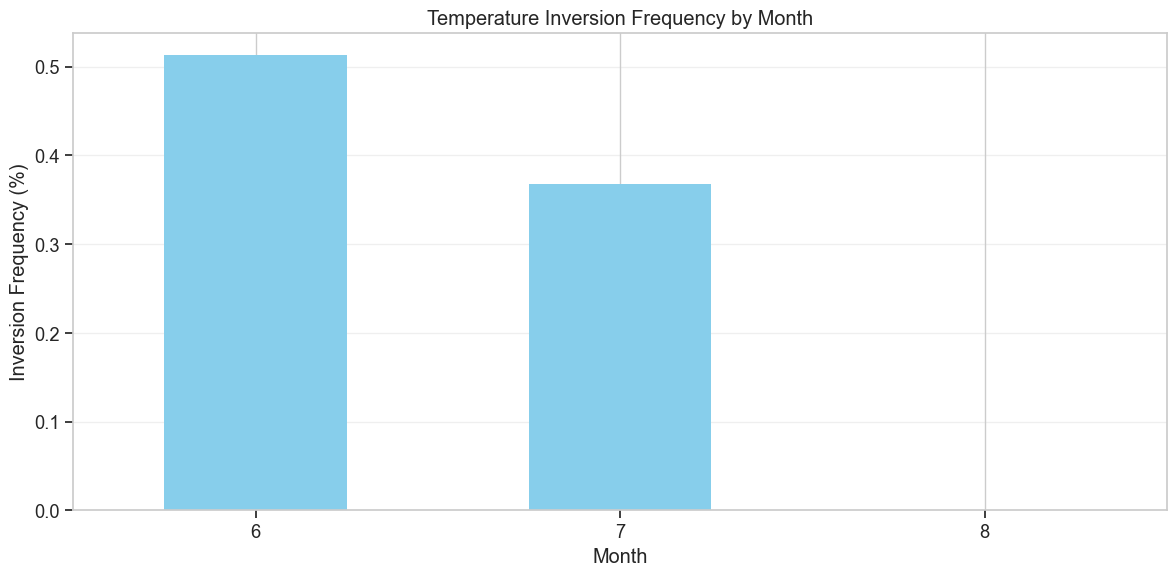

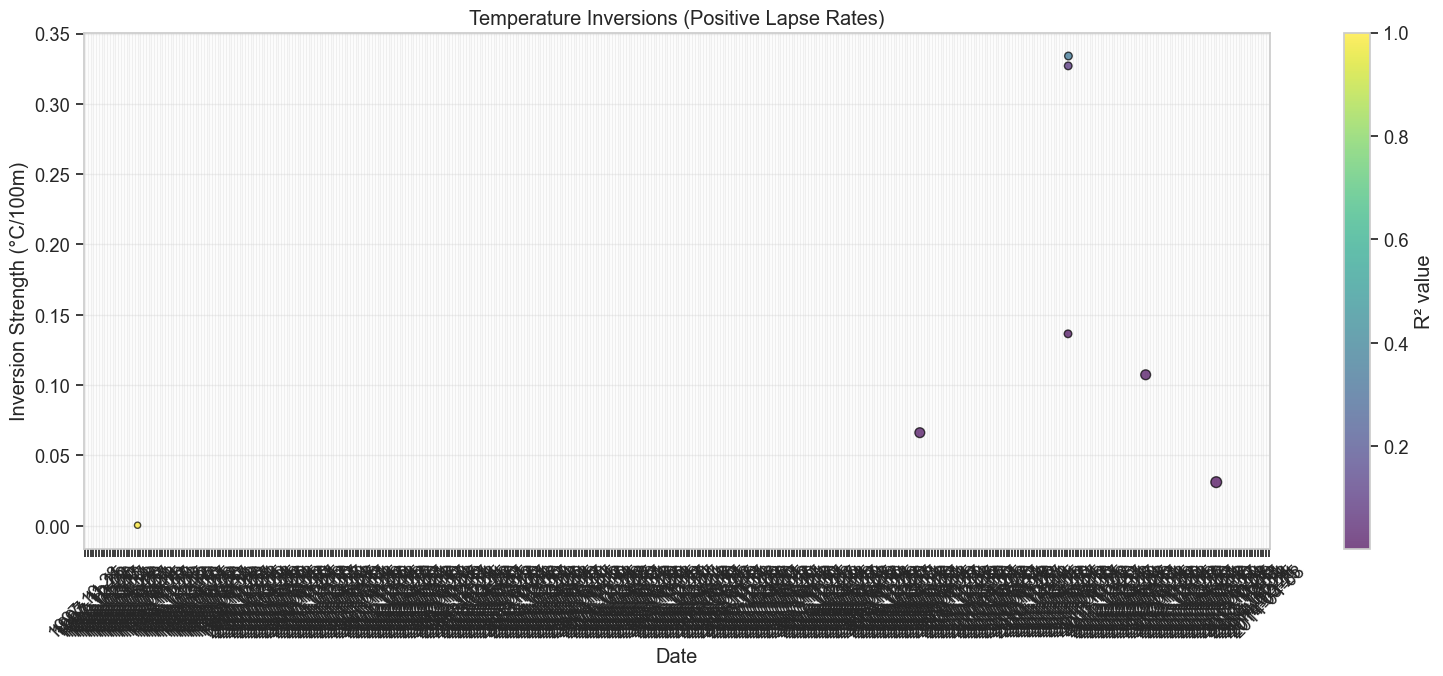

In [59]:
# --------------------------
# 5. Temperature Inversion Analysis
# --------------------------
# Calculate days with temperature inversions (positive lapse rates)
if not daily_lr_df.empty:
    # Identify inversions
    daily_lr_df['inversion'] = daily_lr_df['lapse_rate'] > 0
    
    # Calculate inversion frequency by month
    daily_lr_df['month'] = pd.DatetimeIndex(daily_lr_df['date']).month
    inversion_by_month = daily_lr_df.groupby('month')['inversion'].mean() * 100
    
    # Plot inversion frequency
    plt.figure(figsize=(12, 6))
    inversion_by_month.plot(kind='bar', color='skyblue')
    
    plt.xlabel('Month')
    plt.ylabel('Inversion Frequency (%)')
    plt.title('Temperature Inversion Frequency by Month')
    plt.xticks(rotation=0)
    # month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    # plt.xticks(range(len(month_names)), [month_names[i-1] for i in inversion_by_month.index])
    plt.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Plot inversion strength (positive lapse rates)
    inversion_days = daily_lr_df[daily_lr_df['inversion']]
    if not inversion_days.empty:
        fig, ax = plt.subplots(figsize=(16, 7))
        
        scatter = ax.scatter(inversion_days['date'], inversion_days['lapse_rate'],
                            s=inversion_days['stations_used'] * 10,
                            c=inversion_days['r2'], cmap='viridis',
                            alpha=0.7, edgecolor='k')
        
        # Format x-axis
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        plt.xticks(rotation=45)
        
        # Add colorbar for R² values
        cbar = plt.colorbar(scatter)
        cbar.set_label('R² value')
        
        ax.set_xlabel('Date')
        ax.set_ylabel('Inversion Strength (°C/100m)')
        ax.set_title('Temperature Inversions (Positive Lapse Rates)')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()



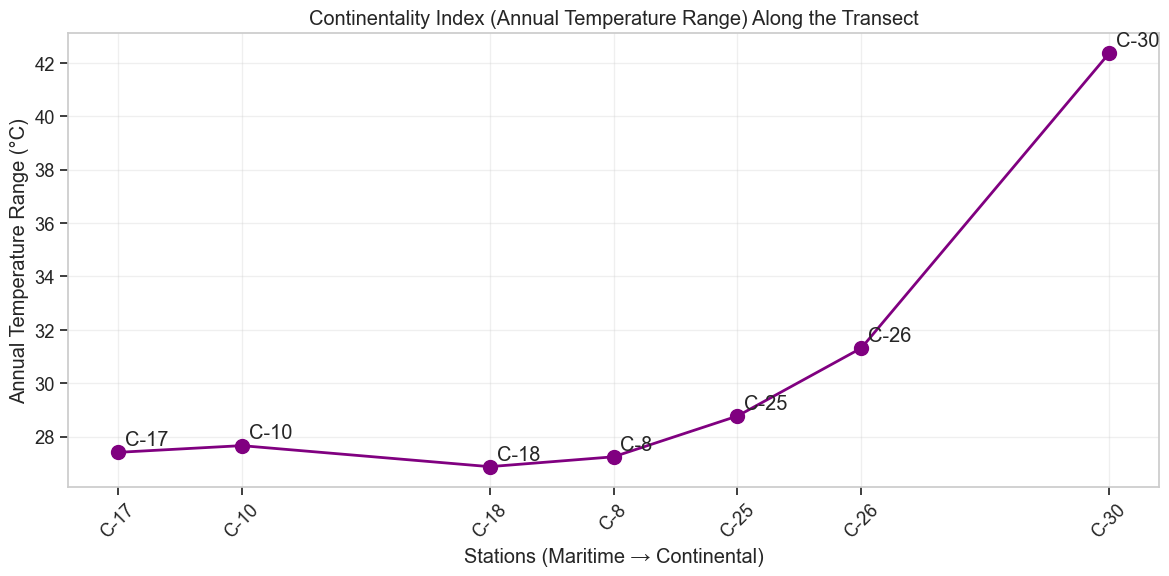

In [60]:
# --------------------------
# 6. Continentality Index Analysis
# --------------------------
# Calculate average temperature by month and station
monthly_avg_temp = df_mcgee.groupby(['camp_id', 'month'])[temp_col].mean().reset_index()

# Calculate annual temperature range for each station (max monthly temp - min monthly temp)
continentality = monthly_avg_temp.groupby('camp_id').agg(
    annual_range=pd.NamedAgg(column=temp_col, aggfunc=lambda x: x.max() - x.min())
).reset_index()

# Add transect position
continentality['transect_pos'] = continentality['camp_id'].map(transect_position)

# Filter for stations in our transect and sort
continentality = continentality[continentality['camp_id'].isin(transect_order)]
continentality_sorted = continentality.sort_values('transect_pos')

if not continentality_sorted.empty:
    # Create a figure
    plt.figure(figsize=(12, 6))
    plt.plot(continentality_sorted['transect_pos'], continentality_sorted['annual_range'], 
            'o-', linewidth=2, markersize=10, color='purple')
    
    for i, row in continentality_sorted.iterrows():
        plt.annotate(row['camp_id'], (row['transect_pos'], row['annual_range']),
                   xytext=(5, 5), textcoords='offset points')
    
    plt.xticks(continentality_sorted['transect_pos'], continentality_sorted['camp_id'], rotation=45)
    plt.xlabel('Stations (Maritime → Continental)')
    plt.ylabel('Annual Temperature Range (°C)')
    plt.title('Continentality Index (Annual Temperature Range) Along the Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



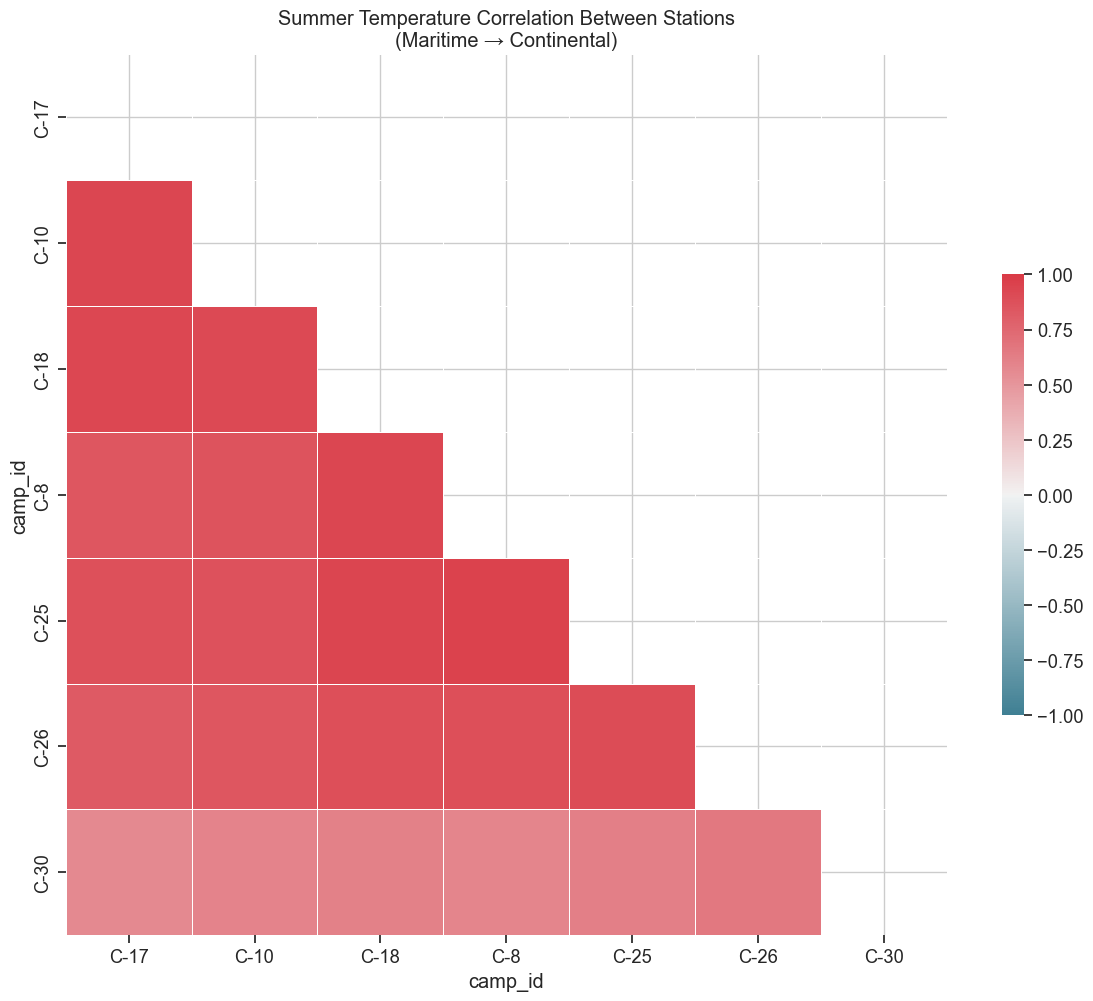

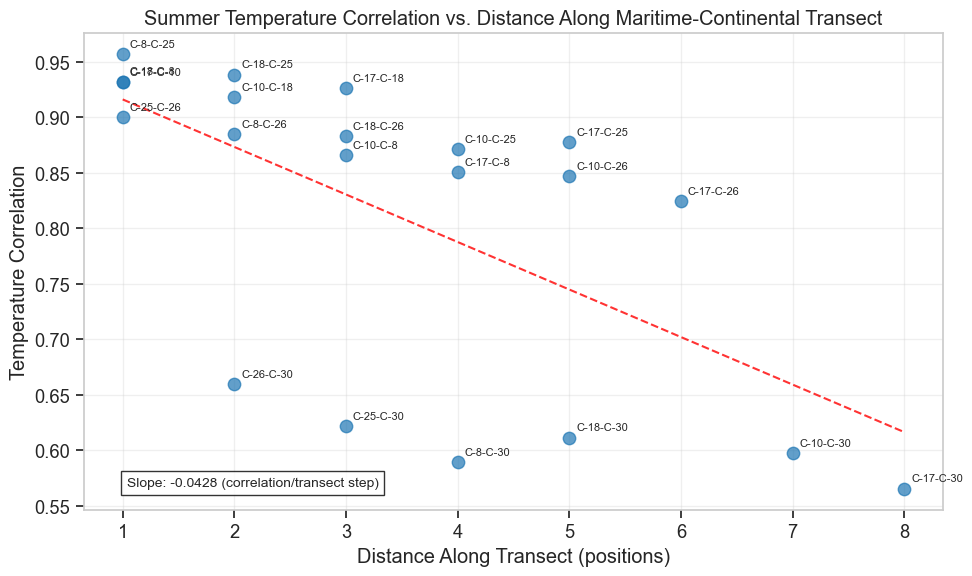

In [61]:
# --------------------------
# 7. Station Correlation Analysis
# --------------------------
# Create a pivot table with temperatures by station
pivot_temp = df_mcgee_summer.pivot_table(index='datetime', columns='camp_id', values=temp_col)

# Calculate correlation matrix
corr_matrix = pivot_temp.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Only include stations in our transect
transect_stations = [station for station in transect_order if station in corr_matrix.columns]
corr_matrix_transect = corr_matrix.loc[transect_stations, transect_stations]

# Sort by transect position
sorted_indices = sorted(range(len(transect_stations)), 
                       key=lambda k: transect_position.get(transect_stations[k], 999))
sorted_stations = [transect_stations[i] for i in sorted_indices]
corr_matrix_sorted = corr_matrix_transect.loc[sorted_stations, sorted_stations]

sns.heatmap(corr_matrix_sorted, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Summer Temperature Correlation Between Stations\n(Maritime → Continental)')
plt.tight_layout()
plt.show()

# Calculate correlation vs. distance along transect
pairwise_corr = []
pairwise_dist = []
pairwise_labels = []

# Calculate correlations and distances
for i, station1 in enumerate(sorted_stations):
    for j, station2 in enumerate(sorted_stations):
        if i < j:  # Only unique pairs
            # Calculate distance along transect
            dist = transect_position.get(station2, 999) - transect_position.get(station1, 999)
            
            # Get correlation if both stations have data
            if station1 in pivot_temp.columns and station2 in pivot_temp.columns:
                # Calculate correlation for non-NaN pairs
                valid_data = pivot_temp[[station1, station2]].dropna()
                if len(valid_data) >= 10:  # Need at least 10 points for meaningful correlation
                    corr = valid_data[station1].corr(valid_data[station2])
                    
                    pairwise_corr.append(corr)
                    pairwise_dist.append(dist)
                    pairwise_labels.append(f"{station1}-{station2}")

# Plot correlation vs. distance
if pairwise_corr:
    plt.figure(figsize=(10, 6))
    plt.scatter(pairwise_dist, pairwise_corr, s=80, alpha=0.7)
    
    # Add labels for each point
    for i, label in enumerate(pairwise_labels):
        plt.annotate(label, (pairwise_dist[i], pairwise_corr[i]),
                   xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add trend line
    if len(pairwise_dist) > 1:
        z = np.polyfit(pairwise_dist, pairwise_corr, 1)
        p = np.poly1d(z)
        x_range = np.linspace(min(pairwise_dist), max(pairwise_dist), 100)
        plt.plot(x_range, p(x_range), "r--", alpha=0.8)
        
        # Add text with slope
        slope_text = f"Slope: {z[0]:.4f} (correlation/transect step)"
        plt.text(0.05, 0.05, slope_text, transform=plt.gca().transAxes, 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.xlabel('Distance Along Transect (positions)')
    plt.ylabel('Temperature Correlation')
    plt.title('Summer Temperature Correlation vs. Distance Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



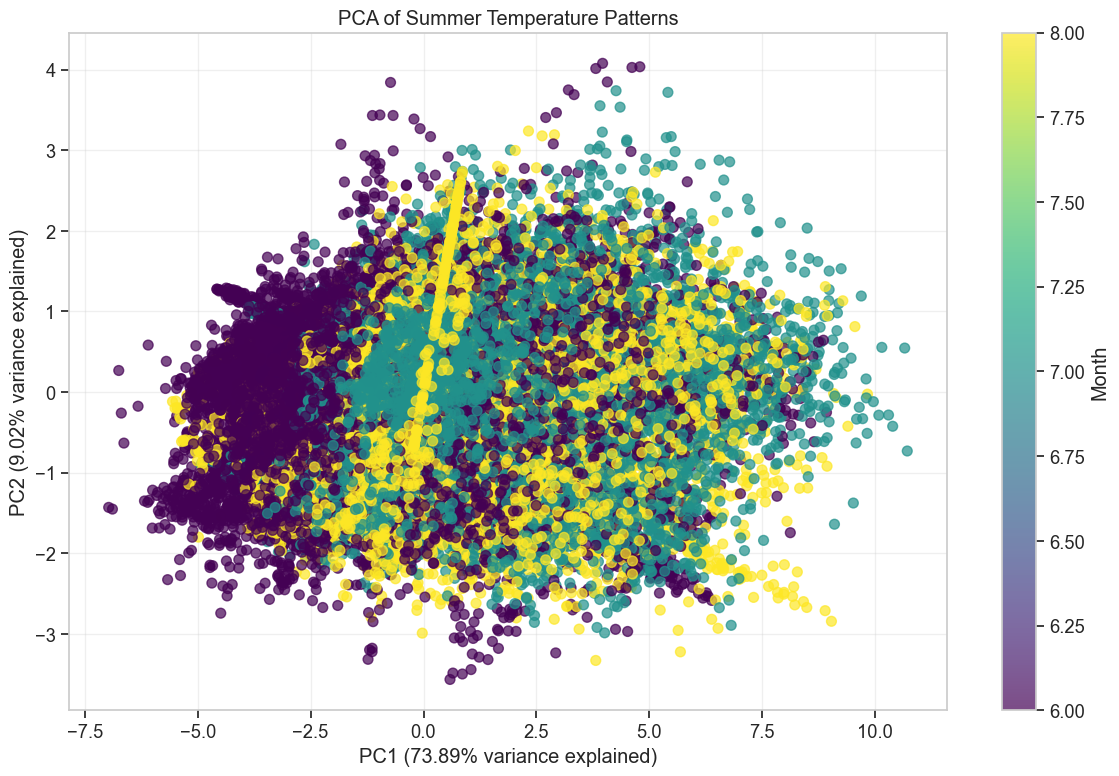

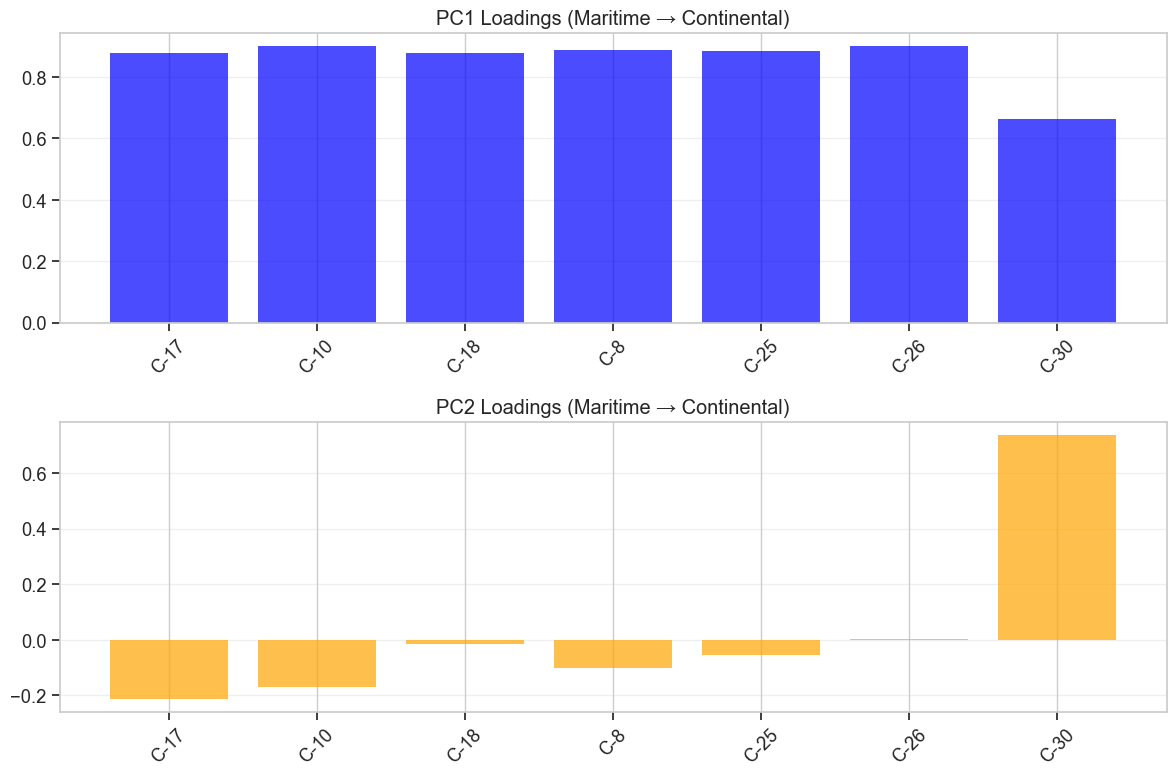

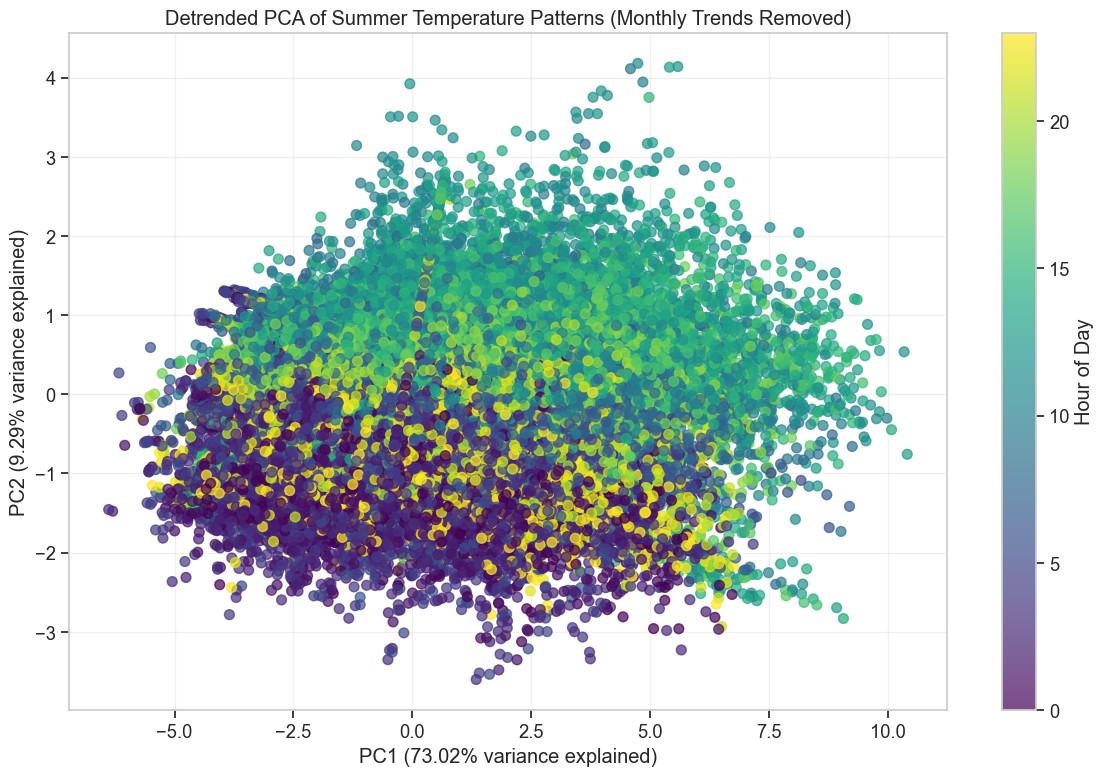

In [63]:
# --------------------------
# 8. PCA Analysis for Summer
# --------------------------
# First, let's create a complete dataset for PCA
pivot_filled = pivot_temp.copy()

# Only keep stations with at least 50% data completeness
completeness = pivot_filled.count() / len(pivot_filled)
complete_stations = completeness[completeness >= 0.5].index

# Fill missing values with the mean for each station
for col in complete_stations:
    pivot_filled[col] = pivot_filled[col].fillna(pivot_filled[col].mean())

# Create a subset with only complete stations
pivot_complete = pivot_filled[complete_stations]

# Check if we have enough data for PCA
if len(pivot_complete.columns) >= 2 and len(pivot_complete) >= 5:
    # Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pivot_complete)
    
    # Apply PCA
    pca = PCA()
    pca_result = pca.fit_transform(scaled_data)
    
    # Create a DataFrame with PCA results
    pca_df = pd.DataFrame(
        data=pca_result[:, :2],
        columns=['PC1', 'PC2']
    )
    
    # Add datetime information
    pca_df['datetime'] = pivot_complete.index
    pca_df['month'] = pca_df['datetime'].dt.month
    pca_df['hour'] = pca_df['datetime'].dt.hour
    
    # Plot PCA results
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['month'], 
                        cmap='viridis', alpha=0.7, s=50)
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Month')
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)')
    plt.title('PCA of Summer Temperature Patterns')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot the loadings (how much each station contributes to each PC)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    loading_df = pd.DataFrame(
        loadings[:, :2],
        columns=['PC1', 'PC2'],
        index=pivot_complete.columns
    )
    
    # Add transect position
    loading_df['transect_pos'] = loading_df.index.map(transect_position)
    loading_df = loading_df.sort_values('transect_pos')
    
    # Plot loadings
    plt.figure(figsize=(12, 8))
    
    # PC1 loadings
    plt.subplot(2, 1, 1)
    plt.bar(loading_df.index, loading_df['PC1'], color='blue', alpha=0.7)
    plt.title('PC1 Loadings (Maritime → Continental)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.3)
    
    # PC2 loadings
    plt.subplot(2, 1, 2)
    plt.bar(loading_df.index, loading_df['PC2'], color='orange', alpha=0.7)
    plt.title('PC2 Loadings (Maritime → Continental)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Detrended PCA - Remove monthly trends
    pivot_detrended = pivot_complete.copy()
    
    # Detrend by subtracting monthly average
    for col in pivot_detrended.columns:
        # Extract the month for each timestamp
        months = pd.DatetimeIndex(pivot_detrended.index).month
        
        # Calculate monthly averages
        monthly_avgs = {}
        for month in np.unique(months):
            monthly_avgs[month] = pivot_detrended.loc[months == month, col].mean()
        
        # Subtract monthly average from each value
        for month in np.unique(months):
            pivot_detrended.loc[months == month, col] -= monthly_avgs[month]
    
    # Apply PCA to detrended data
    detrended_scaled = scaler.fit_transform(pivot_detrended)
    detrended_pca = PCA()
    detrended_result = detrended_pca.fit_transform(detrended_scaled)
    
    # Create a DataFrame with detrended PCA results
    detrended_df = pd.DataFrame(
        data=detrended_result[:, :2],
        columns=['PC1', 'PC2']
    )
    
    # Add datetime information
    detrended_df['datetime'] = pivot_detrended.index
    detrended_df['hour'] = detrended_df['datetime'].dt.hour
    
    # Plot detrended PCA results
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(detrended_df['PC1'], detrended_df['PC2'], c=detrended_df['hour'], 
                        cmap='viridis', alpha=0.7, s=50)
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Hour of Day')
    
    plt.xlabel(f'PC1 ({detrended_pca.explained_variance_ratio_[0]:.2%} variance explained)')
    plt.ylabel(f'PC2 ({detrended_pca.explained_variance_ratio_[1]:.2%} variance explained)')
    plt.title('Detrended PCA of Summer Temperature Patterns (Monthly Trends Removed)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



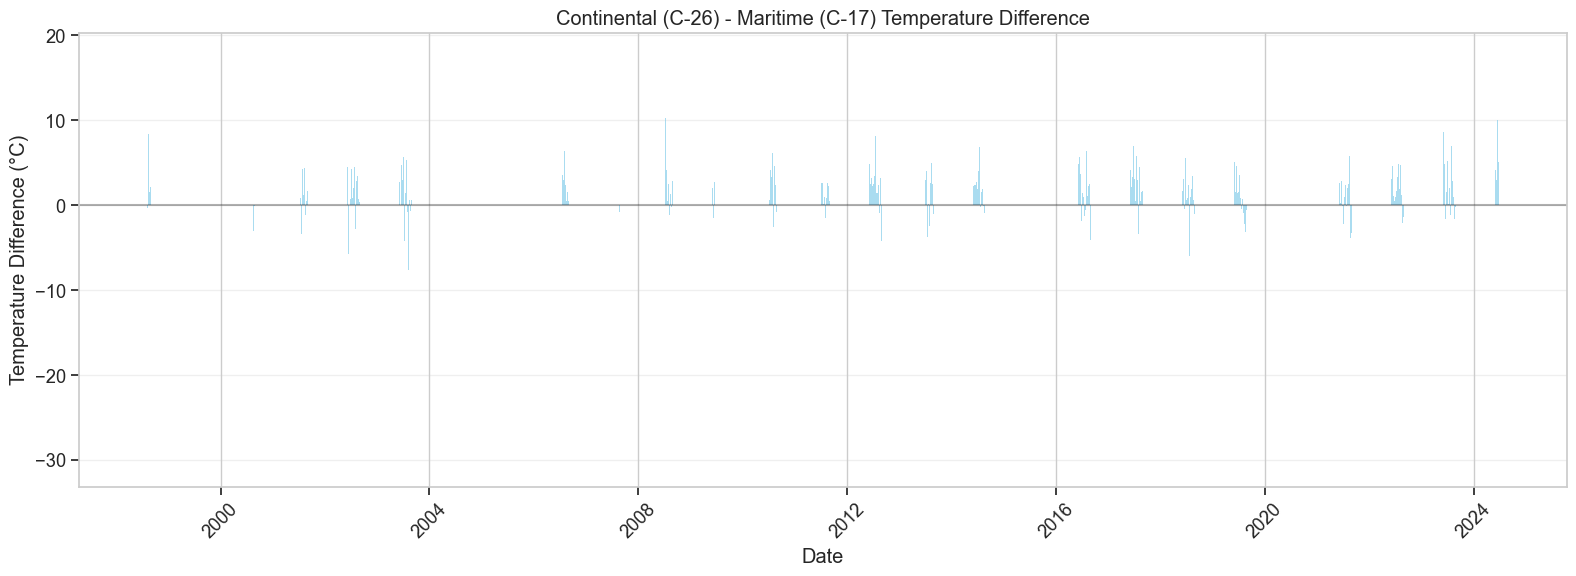


Maritime vs. Continental Temperature Difference Statistics:
mean_diff: 1.4418116393953313
std_diff: 3.233134968021627
max_diff: 17.901125
min_diff: -30.73208333333333
days_continental_warmer: 1445
days_maritime_warmer: 486
total_days: 2329


In [65]:
# --------------------------
# 9. Maritime vs. Continental Conditions Comparison
# --------------------------
# Let's focus on temperature differences between maritime and continental stations
# First, calculate daily average temperatures for the most maritime (C-17) and most continental (C-26) stations
maritime_temps = df_mcgee_summer[df_mcgee_summer['camp_id'] == 'C-17'].groupby('date')[temp_col].mean()
continental_temps = df_mcgee_summer[df_mcgee_summer['camp_id'] == 'C-26'].groupby('date')[temp_col].mean()

# Merge the data
if not maritime_temps.empty and not continental_temps.empty:
    comparison = pd.DataFrame({
        'maritime': maritime_temps,
        'continental': continental_temps
    })
    
    # Calculate the temperature difference (continental - maritime)
    comparison['temp_diff'] = comparison['continental'] - comparison['maritime']
    
    # Plot temperature difference over time
    plt.figure(figsize=(16, 6))
    plt.bar(comparison.index, comparison['temp_diff'], color='skyblue', alpha=0.7)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    plt.xlabel('Date')
    plt.ylabel('Temperature Difference (°C)')
    plt.title('Continental (C-26) - Maritime (C-17) Temperature Difference')
    
    # Format x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Calculate statistics on temperature differences
    diff_stats = {
        'mean_diff': comparison['temp_diff'].mean(),
        'std_diff': comparison['temp_diff'].std(),
        'max_diff': comparison['temp_diff'].max(),
        'min_diff': comparison['temp_diff'].min(),
        'days_continental_warmer': (comparison['temp_diff'] > 0).sum(),
        'days_maritime_warmer': (comparison['temp_diff'] < 0).sum(),
        'total_days': len(comparison)
    }
    
    print("\nMaritime vs. Continental Temperature Difference Statistics:")
    for key, value in diff_stats.items():
        print(f"{key}: {value}")



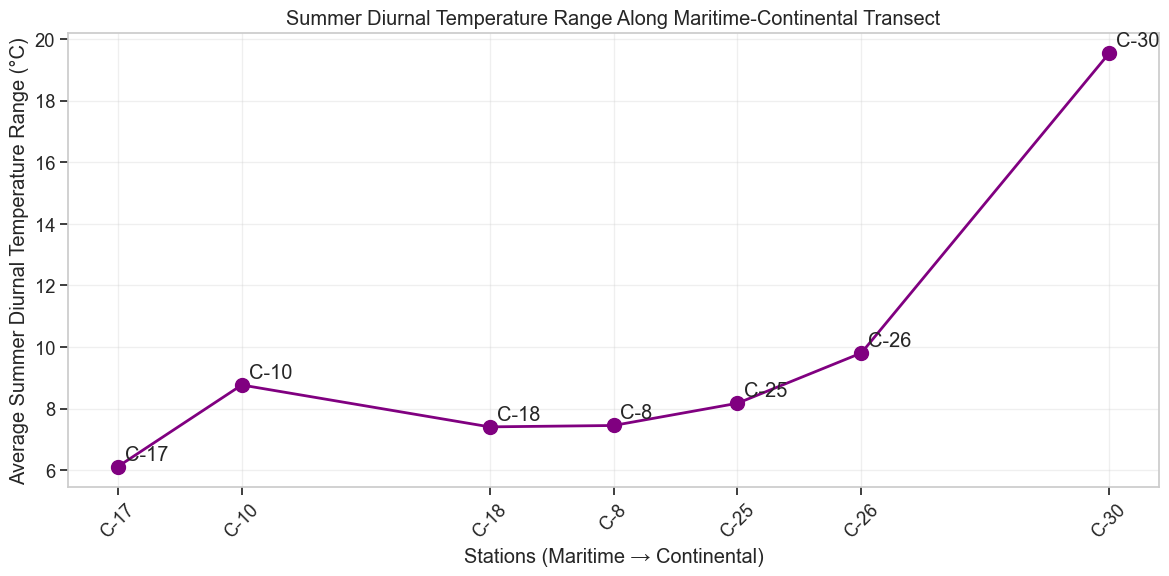

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_95180/771255499.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='camp_id', y='temp_range', data=plot_data, palette='viridis')


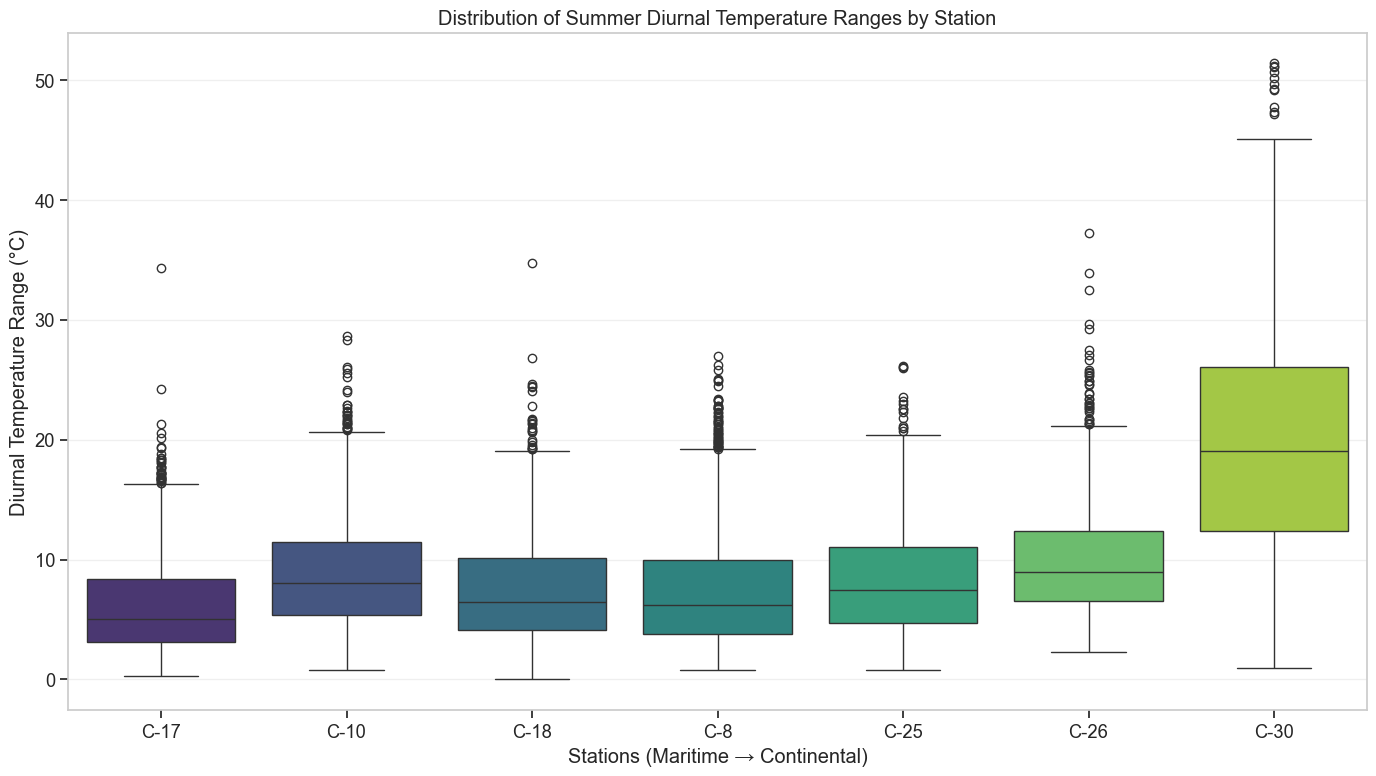

In [66]:
# --------------------------
# 10. Diurnal Amplitude Analysis for Summer
# --------------------------
# Calculate diurnal temperature range for each day and station
diurnal_ranges = df_mcgee_summer.groupby(['camp_id', 'date'])[temp_col].agg(['min', 'max']).reset_index()
diurnal_ranges['temp_range'] = diurnal_ranges['max'] - diurnal_ranges['min']

# Calculate average diurnal range by station
avg_diurnal_range = diurnal_ranges.groupby('camp_id')['temp_range'].mean().reset_index()
avg_diurnal_range['transect_pos'] = avg_diurnal_range['camp_id'].map(transect_position)

# Filter and sort
avg_diurnal_range = avg_diurnal_range[avg_diurnal_range['camp_id'].isin(transect_order)]
avg_diurnal_range_sorted = avg_diurnal_range.sort_values('transect_pos')

# Create figure
if not avg_diurnal_range_sorted.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(avg_diurnal_range_sorted['transect_pos'], avg_diurnal_range_sorted['temp_range'], 
            'o-', linewidth=2, markersize=10, color='purple')
    
    # Add labels
    for i, row in avg_diurnal_range_sorted.iterrows():
        plt.annotate(row['camp_id'], (row['transect_pos'], row['temp_range']),
                   xytext=(5, 5), textcoords='offset points')
    
    plt.xticks(avg_diurnal_range_sorted['transect_pos'], avg_diurnal_range_sorted['camp_id'], rotation=45)
    plt.xlabel('Stations (Maritime → Continental)')
    plt.ylabel('Average Summer Diurnal Temperature Range (°C)')
    plt.title('Summer Diurnal Temperature Range Along Maritime-Continental Transect')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Also visualize diurnal range distribution by station using boxplots
    plt.figure(figsize=(14, 8))
    
    # Filter for stations in our transect and create order
    plot_data = diurnal_ranges[diurnal_ranges['camp_id'].isin(transect_order)]
    plot_data['camp_id'] = pd.Categorical(plot_data['camp_id'], 
                                         categories=sorted(plot_data['camp_id'].unique(), 
                                                          key=lambda x: transect_position.get(x, 999)),
                                         ordered=True)
    
    # Create box plot
    sns.boxplot(x='camp_id', y='temp_range', data=plot_data, palette='viridis')
    
    plt.xlabel('Stations (Maritime → Continental)')
    plt.ylabel('Diurnal Temperature Range (°C)')
    plt.title('Distribution of Summer Diurnal Temperature Ranges by Station')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()